In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


In [10]:
SYMBOL = "BTC-USD"
INTERVAL = "5m"
PERIOD = "60d"   # у Yahoo 5m ограничение по истории, чаще всего 30-60 дней

df = yf.download(SYMBOL, interval=INTERVAL, period=PERIOD, auto_adjust=False, progress=False)

# стандартизируем колонки
df = df.rename(columns=str.lower)
df = df.rename(columns={"adj close": "adj_close"})
df = df.dropna()
df.index = pd.to_datetime(df.index)

df.head(), df.tail(), df.shape


(Price                         adj_close         close          high  \
 Ticker                          btc-usd       btc-usd       btc-usd   
 Datetime                                                              
 2025-12-30 00:00:00+00:00  87173.781250  87173.781250  87173.781250   
 2025-12-30 00:05:00+00:00  87191.875000  87191.875000  87191.875000   
 2025-12-30 00:10:00+00:00  87192.007812  87192.007812  87221.914062   
 2025-12-30 00:15:00+00:00  87227.062500  87227.062500  87233.523438   
 2025-12-30 00:20:00+00:00  87199.109375  87199.109375  87218.515625   
 
 Price                               low          open   volume  
 Ticker                          btc-usd       btc-usd  btc-usd  
 Datetime                                                        
 2025-12-30 00:00:00+00:00  87142.078125  87142.078125        0  
 2025-12-30 00:05:00+00:00  87109.578125  87130.132812        0  
 2025-12-30 00:10:00+00:00  87184.734375  87184.734375        0  
 2025-12-30 00:15:00+00:00

In [11]:
# ===================== YF: INCREMENTAL RELOAD (KEEP OLD) =====================
import pandas as pd
import yfinance as yf

SYMBOL   = "BTC-USD"
INTERVAL = "5m"
PERIOD   = "60d"   # fallback, если df ещё нет
OVERLAP_BARS = 20  # сколько баров перезапрашивать "с запасом" (чтобы не потерять хвост/перерисовки)

def _standardize_yf(_df: pd.DataFrame) -> pd.DataFrame:
    if _df is None or len(_df) == 0:
        return pd.DataFrame()

    # если вдруг MultiIndex колонки (редко, но бывает)
    if isinstance(_df.columns, pd.MultiIndex):
        _df.columns = ["_".join([str(x) for x in col if str(x) != ""]) for col in _df.columns]

    _df = _df.rename(columns=str.lower).rename(columns={"adj close": "adj_close"})
    _df.index = pd.to_datetime(_df.index)
    _df = _df.sort_index()
    _df = _df.dropna()
    return _df

# 1) берем старый df, если уже есть
df_old = None
if "df" in globals() and isinstance(df, pd.DataFrame) and len(df) > 0:
    df_old = _standardize_yf(df.copy())

# 2) докачка
if df_old is not None and len(df_old) > 0:
    last_ts = pd.Timestamp(df_old.index.max())
    step_min = int(INTERVAL.replace("m", "")) if INTERVAL.endswith("m") else 5
    start_ts = last_ts - pd.Timedelta(minutes=step_min * OVERLAP_BARS)

    df_new = yf.download(
        SYMBOL,
        interval=INTERVAL,
        start=start_ts.to_pydatetime(),
        auto_adjust=False,
        progress=False
    )
else:
    df_new = yf.download(
        SYMBOL,
        interval=INTERVAL,
        period=PERIOD,
        auto_adjust=False,
        progress=False
    )

df_new = _standardize_yf(df_new)

# 3) сливаем (старое + новое), убираем дубли по индексу
if df_old is not None and len(df_old) > 0:
    if len(df_new) == 0:
        print("[WARN] Новых данных не пришло — оставляю старый df без изменений.")
        df = df_old
    else:
        df = pd.concat([df_old, df_new], axis=0)
        df = df[~df.index.duplicated(keep="last")].sort_index().dropna()

    print(f"[OK] old: {df_old.index.min()} → {df_old.index.max()} | rows={len(df_old)}")
    if len(df_new) > 0:
        print(f"[OK] new: {df_new.index.min()} → {df_new.index.max()} | rows={len(df_new)}")
    print(f"[OK] out: {df.index.min()} → {df.index.max()} | rows={len(df)}")
else:
    df = df_new
    print(f"[OK] out: {df.index.min()} → {df.index.max()} | rows={len(df)}")

df.head(), df.tail(), df.shape

[OK] old: 2025-12-30 00:00:00+00:00 → 2026-02-27 15:20:00+00:00 | rows=17176
[OK] new: 2026-02-27 13:40:00+00:00 → 2026-02-27 15:20:00+00:00 | rows=21
[OK] out: NaT → NaT | rows=0


(Empty DataFrame
 Columns: [adj_close_btc-usd, close_btc-usd, high_btc-usd, low_btc-usd, open_btc-usd, volume_btc-usd, adj close_btc-usd]
 Index: [],
 Empty DataFrame
 Columns: [adj_close_btc-usd, close_btc-usd, high_btc-usd, low_btc-usd, open_btc-usd, volume_btc-usd, adj close_btc-usd]
 Index: [],
 (0, 7))

In [12]:
import numpy as np
import pandas as pd

# ---------- True Range / ATR ----------
def true_range(high, low, close):
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev_close).abs(),
        (low  - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr

def atr(high, low, close, length=14):
    tr = true_range(high, low, close)
    return tr.ewm(alpha=1/length, adjust=False).mean()

# ---------- TRAMA (Pine-like) ----------
def trama(src_close, high, low, length=20):
    if src_close is None or len(src_close) == 0:
        return pd.Series(dtype=float)

    hh = np.sign(high.rolling(length).max().diff()).clip(lower=0)
    ll = (np.sign(low.rolling(length).min().diff()) * -1).clip(lower=0)
    cond = ((hh != 0) | (ll != 0)).astype(float)
    tc = (cond.rolling(length, min_periods=1).mean() ** 2).fillna(0.0)

    ama = pd.Series(index=src_close.index, dtype=float)
    ama.iloc[0] = float(src_close.iloc[0])

    for i in range(1, len(src_close)):
        prev = ama.iloc[i-1]
        a = float(tc.iloc[i])
        ama.iloc[i] = prev + a * (float(src_close.iloc[i]) - prev)

    return ama

# ---------- Resample OHLC (minutes rule like "60min") ----------
def resample_ohlc(df_base, tf="60min"):
    o = df_base["open"].resample(tf).first()
    h = df_base["high"].resample(tf).max()
    l = df_base["low"].resample(tf).min()
    c = df_base["close"].resample(tf).last()

    out = pd.concat([o, h, l, c], axis=1)
    out.columns = ["open", "high", "low", "close"]

    if "volume" in df_base.columns:
        v = df_base["volume"].resample(tf).sum()
        out["volume"] = v

    return out.dropna(subset=["open","high","low","close"])

# ---------- Session VWAP (daily anchor) ----------
def session_vwap(df):
    """
    VWAP с дневным якорем. Работает для tz-aware и tz-naive индекса.
    Требует volume.
    """
    if "volume" not in df.columns:
        raise ValueError("session_vwap: нужен столбец volume")

    idx = df.index
    idx_naive = idx.tz_convert(None) if getattr(idx, "tz", None) is not None else idx

    day = pd.Series(idx_naive.normalize(), index=idx)

    hlc3 = (df["high"] + df["low"] + df["close"]) / 3.0
    pv = hlc3 * df["volume"]
    cumPV = pv.groupby(day).cumsum()
    cumV  = df["volume"].groupby(day).cumsum()

    vwap = np.where(cumV.values > 0, cumPV.values / cumV.values, np.nan)
    return pd.Series(vwap, index=idx, name="vwap")

# ---------- Pivot High/Low ----------
def pivothigh(high, left=10, right=10):
    h = high.values
    out = np.full(len(high), np.nan, dtype=float)
    for i in range(left + right, len(high)):
        c = i - right
        window = h[c-left:c+right+1]
        if np.isfinite(window).all() and h[c] == np.nanmax(window):
            out[c] = h[c]
    return pd.Series(out, index=high.index, name="pivothigh")

def pivotlow(low, left=10, right=10):
    l = low.values
    out = np.full(len(low), np.nan, dtype=float)
    for i in range(left + right, len(low)):
        c = i - right
        window = l[c-left:c+right+1]
        if np.isfinite(window).all() and l[c] == np.nanmin(window):
            out[c] = l[c]
    return pd.Series(out, index=low.index, name="pivotlow")

# ---------- Build extended zones from pivots ----------
def build_pivot_zones(df, ph, pl, zDepthATR=0.6, zExtend=120):
    n = len(df)

    supTop = np.full(n, np.nan)
    supBot = np.full(n, np.nan)
    demTop = np.full(n, np.nan)
    demBot = np.full(n, np.nan)

    atrv = df["atr"].values
    phv = ph.values
    plv = pl.values

    last_sup_top = np.nan
    last_sup_bot = np.nan
    last_sup_end = -1

    last_dem_top = np.nan
    last_dem_bot = np.nan
    last_dem_end = -1

    for i in range(n):
        if np.isfinite(phv[i]):
            last_sup_top = phv[i]
            last_sup_bot = phv[i] - zDepthATR * atrv[i]
            last_sup_end = i + zExtend

        if np.isfinite(plv[i]):
            last_dem_bot = plv[i]
            last_dem_top = plv[i] + zDepthATR * atrv[i]
            last_dem_end = i + zExtend

        if i <= last_sup_end and np.isfinite(last_sup_top):
            supTop[i] = last_sup_top
            supBot[i] = last_sup_bot

        if i <= last_dem_end and np.isfinite(last_dem_top):
            demTop[i] = last_dem_top
            demBot[i] = last_dem_bot

    out = df.copy()
    out["supTop"] = supTop
    out["supBot"] = supBot
    out["demTop"] = demTop
    out["demBot"] = demBot

    out["supActive"] = np.isfinite(out["supTop"])
    out["demActive"] = np.isfinite(out["demTop"])

    out["inSupplyZone"] = out["supActive"] & (out["high"] >= out["supBot"]) & (out["low"] <= out["supTop"])
    out["inDemandZone"] = out["demActive"] & (out["high"] >= out["demBot"]) & (out["low"] <= out["demTop"])
    return out

# ---------- Density zones (simplified) ----------
def build_density_zones(df, denMetric, qLen=200, qPct=92.0, denDepthATR=0.45, denExtend=150):
    n = len(df)

    thr = denMetric.rolling(qLen, min_periods=max(20, qLen//4)).quantile(qPct/100.0)

    dTop = np.full(n, np.nan)
    dBot = np.full(n, np.nan)
    dDir = np.full(n, 0, dtype=int)

    atrv   = df["atr"].values
    closev = df["close"].values
    thrv   = thr.values

    # delta нужен только для densDir
    delta = df["delta"].values if "delta" in df.columns else np.full(n, np.nan)

    last_top = np.nan
    last_bot = np.nan
    last_dir = 0
    last_end = -1

    mvals = denMetric.values

    for i in range(n):
        if np.isfinite(thrv[i]) and np.isfinite(mvals[i]) and (mvals[i] >= thrv[i]):
            half = atrv[i] * denDepthATR
            last_top = closev[i] + half
            last_bot = closev[i] - half
            last_dir = 1 if (np.isfinite(delta[i]) and delta[i] >= 0) else -1
            last_end = i + denExtend

        if i <= last_end and np.isfinite(last_top):
            dTop[i] = last_top
            dBot[i] = last_bot
            dDir[i] = last_dir

    out = df.copy()
    out["densTop"] = dTop
    out["densBot"] = dBot
    out["densDir"] = dDir
    out["densActive"] = np.isfinite(out["densTop"])
    out["inDensity"] = out["densActive"] & (out["high"] >= out["densBot"]) & (out["low"] <= out["densTop"])
    return out

In [13]:
# ===================== SAFETY: ENSURE df IS OHLCV (not summary) =====================
import pandas as pd

def _looks_like_ohlc(d: pd.DataFrame) -> bool:
    cols = {str(c).lower() for c in d.columns}
    return {"open","high","low","close"}.issubset(cols)

def _looks_like_summary(d: pd.DataFrame) -> bool:
    cols = {str(c).lower() for c in d.columns}
    # типичные колонки твоих таблиц подбора
    return ("run_id" in cols) and (("sharpe" in cols) or ("total_return" in cols)) and (not _looks_like_ohlc(d))

if "df" not in globals() or df is None or not isinstance(df, pd.DataFrame):
    raise ValueError("Нет df (DataFrame) в памяти. Должен быть df со свечами OHLCV.")

if _looks_like_summary(df):
    # пробуем взять свечи из DF_SRC (у тебя он есть в Stage1)
    if "DF_SRC" in globals() and isinstance(DF_SRC, pd.DataFrame) and len(DF_SRC) > 0 and _looks_like_ohlc(DF_SRC):
        print("[fix] df был summary (подбор). Переключаю df на DF_SRC (свечи).")
        df = DF_SRC.copy()
    else:
        raise ValueError(
            "df сейчас summary (run_id/sharpe/...), а DF_SRC со свечами не найден.\n"
            "Поставь df = normalize_ohlcv_columns(df_ohlcv) перед CT core."
        )
else:
    print("[ok] df уже похож на OHLCV (есть open/high/low/close).")

[ok] df уже похож на OHLCV (есть open/high/low/close).


In [14]:
# ===================== ONE CELL (CT CORE): NORMALIZE + ATR + TRAMA + VWAP + MOMENTUM + ZONES (PIVOTS ON SLOW TF) =====================
import numpy as np
import pandas as pd

# ---------- normalize TF ----------
def _tf_norm(tf):
    if isinstance(tf, (int, float)):
        return f"{int(tf)}min"
    s = str(tf).strip().lower().replace(" ", "")
    s = s.replace("minutes", "min").replace("minute", "min").replace("mins", "min")
    if s.isdigit():
        return f"{int(s)}min"
    if s.endswith("m") and not s.endswith("min"):
        s = s[:-1] + "min"
    return s

def _tf_to_rule(tf_norm: str) -> str:
    s = tf_norm.lower()
    if s.endswith("min"):
        n = int(s[:-3])
        return f"{n}T"
    return s

def _tf_minutes(tf_norm: str) -> int:
    s = str(tf_norm).lower().strip()
    if s.endswith("min"):
        return int(s[:-3])
    if s.endswith("t"):
        return int(s[:-1])
    raise ValueError(f"Не понимаю TF: {tf_norm}")

# ---------- normalize yfinance columns to open/high/low/close/(volume) ----------
def normalize_ohlcv_columns(df_in: pd.DataFrame) -> pd.DataFrame:
    x = df_in.copy()

    # MultiIndex -> flatten
    if isinstance(x.columns, pd.MultiIndex):
        x.columns = [str(c[0]).lower() for c in x.columns]
    else:
        x.columns = [str(c).lower() for c in x.columns]

    x = x.rename(columns={"adj close": "adj_close"})

    want = ["open", "high", "low", "close", "volume"]
    mapping = {}
    for base in want:
        if base in x.columns:
            continue
        candidates = [c for c in x.columns if c.startswith(base + "_")]
        if candidates:
            mapping[candidates[0]] = base

    x = x.rename(columns=mapping)

    need = ["open","high","low","close"]
    missing = [c for c in need if c not in x.columns]
    if missing:
        raise ValueError(f"Не нашёл колонки {missing}. Сейчас колонки: {list(x.columns)[:30]} ...")

    x.index = pd.to_datetime(x.index)
    x = x.sort_index()
    return x

# ---------- robust resample_ohlc (NO 'first'/'last' strings) ----------
def resample_ohlc(df_in, tf="60min"):
    tf = _tf_norm(tf)
    rule = _tf_to_rule(tf)

    x = normalize_ohlcv_columns(df_in)

    o = x["open"].resample(rule).first()
    h = x["high"].resample(rule).max()
    l = x["low"].resample(rule).min()
    c = x["close"].resample(rule).last()

    out = pd.concat([o, h, l, c], axis=1)
    out.columns = ["open","high","low","close"]

    if "volume" in x.columns:
        v = x["volume"].resample(rule).sum()
        out["volume"] = v

    return out.dropna()
# ===================== CT SETTINGS =====================
TF_TRAMA_FAST = _tf_norm("5m")
TF_TRAMA_SLOW = _tf_norm("360m")

lenFast = 55
lenSlow = 110

atrLen = 50
minDistATR = 10.0  # используется в SIGNAL PREP

# зоны
zDepthATR = 0.6
zExtend   = 110
pivotL1 = 15
pivotR1 = 15

AUTO_SCALE_ZEXTEND = True  # чтобы zExtend имел похожий горизонт по времени после перехода на SLOW TF

denMetricSrc = "AbsDelta"   # "Volume" или "AbsDelta"
qLen = 300
qPct = 99.0
denDepthATR = 0.5
denExtend   = 350

# ===================== BUILD (CT CORE) =====================
df_raw = df.copy()
print("[diag] raw cols:", list(df_raw.columns)[:20])
print("[diag] raw rows:", len(df_raw), "| index:", df_raw.index.min(), "->", df_raw.index.max())

# base TF
df = normalize_ohlcv_columns(df_raw).copy()

# ATR base
df["atr"] = atr(df["high"], df["low"], df["close"], atrLen)

# TRAMA fast
df_fast = resample_ohlc(df_raw, TF_TRAMA_FAST)
print(f"[diag] df_fast tf={TF_TRAMA_FAST} rows:", len(df_fast))
df_fast["trama_fast_tf"] = trama(df_fast["close"], df_fast["high"], df_fast["low"], lenFast)
df["trama_fast"] = df_fast["trama_fast_tf"].reindex(df.index, method="ffill")

# TRAMA slow
df_slow = resample_ohlc(df_raw, TF_TRAMA_SLOW)
print(f"[diag] df_slow tf={TF_TRAMA_SLOW} rows:", len(df_slow))
df_slow["trama_slow_tf"] = trama(df_slow["close"], df_slow["high"], df_slow["low"], lenSlow)
df["trama_slow"] = df_slow["trama_slow_tf"].reindex(df.index, method="ffill")

# VWAP (из твоих функций)
df["vwap"] = session_vwap(df)

# delta + momentum
if "volume" not in df.columns:
    raise ValueError("Для delta/momentum нужен volume. Сейчас volume нет в df после normalize.")
rng = (df["high"] - df["low"]).clip(lower=1e-9)
df["delta"] = df["volume"] * (df["close"] - df["open"]) / rng
df["momLong"]  = df["delta"] > 0
df["momShort"] = df["delta"] < 0

# ===================== Pivot zones on SLOW TF =====================
df_slow["atr_slow"] = atr(df_slow["high"], df_slow["low"], df_slow["close"], atrLen)

ph_slow = pivothigh(df_slow["high"], left=pivotL1, right=pivotR1)
pl_slow = pivotlow(df_slow["low"],  left=pivotL1, right=pivotR1)

zExtend_slow = int(zExtend)
if AUTO_SCALE_ZEXTEND:
    base_min = _tf_minutes(_tf_norm("5m"))
    slow_min = _tf_minutes(TF_TRAMA_SLOW)
    zExtend_slow = max(3, int(round(zExtend * (base_min / slow_min))))
    print(f"[diag] zExtend base={zExtend} bars@{base_min}m -> slow={zExtend_slow} bars@{slow_min}m")

tmp_slow = df_slow.copy()
tmp_slow["atr"] = tmp_slow["atr_slow"]
tmp_slow = build_pivot_zones(tmp_slow, ph_slow, pl_slow, zDepthATR=zDepthATR, zExtend=zExtend_slow)

for c in ["supTop","supBot","demTop","demBot"]:
    df[c] = tmp_slow[c].reindex(df.index, method="ffill")

df["supActive"] = np.isfinite(df["supTop"])
df["demActive"] = np.isfinite(df["demTop"])
df["inSupplyZone"] = df["supActive"] & (df["high"] >= df["supBot"]) & (df["low"] <= df["supTop"])
df["inDemandZone"] = df["demActive"] & (df["high"] >= df["demBot"]) & (df["low"] <= df["demTop"])

# ===================== Density zones on BASE TF =====================
denMetric = df["volume"] if denMetricSrc == "Volume" else df["delta"].abs()
df = build_density_zones(df, denMetric=denMetric, qLen=qLen, qPct=qPct, denDepthATR=denDepthATR, denExtend=denExtend)

print(f"[OK] rows={len(df)} | FAST={TF_TRAMA_FAST} | SLOW={TF_TRAMA_SLOW}")
print("[OK] has:", {c: (c in df.columns) for c in ["atr","trama_fast","trama_slow","vwap","delta","momLong","momShort","inSupplyZone","inDemandZone","inDensity"]})

df[["close","trama_fast","trama_slow","atr","vwap","delta","momLong","momShort","inSupplyZone","inDemandZone","inDensity"]].dropna().head()

[diag] raw cols: ['adj_close_btc-usd', 'close_btc-usd', 'high_btc-usd', 'low_btc-usd', 'open_btc-usd', 'volume_btc-usd', 'adj close_btc-usd']
[diag] raw rows: 0 | index: NaT -> NaT
[diag] df_fast tf=5min rows: 0
[diag] df_slow tf=360min rows: 0
[diag] zExtend base=110 bars@5m -> slow=3 bars@360m
[OK] rows=0 | FAST=5min | SLOW=360min
[OK] has: {'atr': True, 'trama_fast': True, 'trama_slow': True, 'vwap': True, 'delta': True, 'momLong': True, 'momShort': True, 'inSupplyZone': True, 'inDemandZone': True, 'inDensity': True}


/var/folders/3g/jmvmn_yx4vqdtkbl4gtw8b0w0000gn/T/ipykernel_25632/4008010628.py:71: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  o = x["open"].resample(rule).first()
/var/folders/3g/jmvmn_yx4vqdtkbl4gtw8b0w0000gn/T/ipykernel_25632/4008010628.py:72: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  h = x["high"].resample(rule).max()
/var/folders/3g/jmvmn_yx4vqdtkbl4gtw8b0w0000gn/T/ipykernel_25632/4008010628.py:73: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  l = x["low"].resample(rule).min()
/var/folders/3g/jmvmn_yx4vqdtkbl4gtw8b0w0000gn/T/ipykernel_25632/4008010628.py:74: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  c = x["close"].resample(rule).last()
/var/folders/3g/jmvmn_yx4vqdtkbl4gtw8b0w0000gn/T/ipykernel_25632/4008010628.py:80: FutureWarning: 'T' is deprecated a

,close,trama_fast,trama_slow,atr,vwap,delta,momLong,momShort,inSupplyZone,inDemandZone,inDensity
Datetime,,,,,,,,,,,


In [15]:
# ===================== SIGNAL PREP (CT): OLD CONDITIONS + TRAMA DIRECTION (NO ZONE RETEST) =====================
import numpy as np
import pandas as pd

x = df.copy()

# ------------------ SETTINGS ------------------
# Momentum settings (ТУТ МЕНЯЕШЬ)
MOM_MODE = "strong"          # "sign" или "strong"
MOM_Q = 0.70                 # квантиль abs(delta) для strong (0.60..0.85 обычно)
MOM_ROLL = 300               # окно для квантиля по abs(delta)

# ------------------ SAFETY ------------------
need = [
    "close","high","low","open","atr","volume",
    "trama_fast","trama_slow","vwap",
    "inDemandZone","inSupplyZone","inDensity",
    "delta"
]
miss = [c for c in need if c not in x.columns]
if miss:
    raise ValueError(f"Не хватает колонок для сигналов: {miss}")

# =========================================================
# A) MOMENTUM
# =========================================================
if MOM_MODE == "sign":
    x["momLong"]  = x["delta"] > 0
    x["momShort"] = x["delta"] < 0
elif MOM_MODE == "strong":
    thr = x["delta"].abs().rolling(MOM_ROLL, min_periods=max(50, MOM_ROLL//3)).quantile(MOM_Q)
    x["momLong"]  = (x["delta"] > 0) & (x["delta"].abs() >= thr)
    x["momShort"] = (x["delta"] < 0) & (x["delta"].abs() >= thr)
else:
    raise ValueError("MOM_MODE должен быть 'sign' или 'strong'")

# =========================================================
# B) OLD CONDITIONS (как было у тебя)
# =========================================================
prev_close = x["close"].shift(1)
prev_fast  = x["trama_fast"].shift(1)

x["crossUp"]   = (prev_close <= prev_fast) & (x["close"] > x["trama_fast"])
x["crossDown"] = (prev_close >= prev_fast) & (x["close"] < x["trama_fast"])

x["distLong"]  = x["trama_slow"] - x["close"]
x["distShort"] = x["close"] - x["trama_slow"]

x["validDistLong"]  = x["distLong"]  > x["atr"] * float(minDistATR)
x["validDistShort"] = x["distShort"] > x["atr"] * float(minDistATR)

x["ctLong_OK"]  = (x["close"] < x["vwap"])
x["ctShort_OK"] = (x["close"] > x["vwap"])

old_long  = x["ctLong_OK"]  & x["crossUp"]   & x["validDistLong"]  & x["momLong"].fillna(False)
old_short = x["ctShort_OK"] & x["crossDown"] & x["validDistShort"] & x["momShort"].fillna(False)

# =========================================================
# C) EXTRA FILTER: TRAMA DIRECTION (то, что ты просил)
# =========================================================
trama_dir_long  = x["trama_slow"] > x["trama_fast"]
trama_dir_short = x["trama_slow"] < x["trama_fast"]

# =========================================================
# D) OPTIONAL: AVOID ENTERING INSIDE "BAD" ZONES (НЕ ретест)
#    long: не входить в supply/density; short: не входить в demand/density
# =========================================================
avoid_long  = (~x["inSupplyZone"].fillna(False)) & (~x["inDensity"].fillna(False))
avoid_short = (~x["inDemandZone"].fillna(False)) & (~x["inDensity"].fillna(False))

# =========================================================
# E) FINAL ENTRIES
# =========================================================
x["ctLongEntry"]  = old_long  & trama_dir_long  & avoid_long
x["ctShortEntry"] = old_short & trama_dir_short & avoid_short

# --- boolean NaN protection ---
for col in [
    "crossUp","crossDown",
    "validDistLong","validDistShort",
    "ctLong_OK","ctShort_OK",
    "momLong","momShort",
    "ctLongEntry","ctShortEntry",
]:
    x[col] = x[col].fillna(False)

df = x

print("[OK] signals:",
      "long:", int(df["ctLongEntry"].sum()),
      "| short:", int(df["ctShortEntry"].sum()),
      "| MOM_MODE:", MOM_MODE, "MOM_Q:", MOM_Q)

[OK] signals: long: 0 | short: 0 | MOM_MODE: strong MOM_Q: 0.7


In [16]:
# ===================== BACKTEST CELL (CT ONLY) =====================
# - входы: ctLongEntry / ctShortEntry (из SIGNAL PREP)
# - выходы: TP touch slow TRAMA + exits by zones + trailing ATR*mult with MIN_STOP_PTS
# - фильтр: min potential >= MIN_POT_MULT * FEE_RT (по цели = slow TRAMA)
#
# Требует в df:
# open,high,low,close,volume, atr,trama_fast,trama_slow,vwap,
# ctLongEntry,ctShortEntry, inSupplyZone,inDemandZone,inDensity,
# supTop,supBot,demTop,demBot,densTop,densBot,densDir

import numpy as np
import pandas as pd
from dataclasses import dataclass

# ---------- SETTINGS ----------
FEE_RT = 0.0007                # round-trip fee for filter (0.02% maker + 0.05% taker)
MIN_POT_MULT = 3.0             # требуемый потенциал >= MIN_POT_MULT * FEE_RT
USE_SLOW_TRAMA_AS_TARGET = True

MIN_STOP_PTS = 900.0           # минимум трейлинг-дистанции (для BTC ~ $300)
ZONE_TIGHTEN_MULT = 0.85       # ужесточение стопа в зоне (как раньше)

@dataclass
class Trade:
    entry_ts: pd.Timestamp
    side: str                 # "long" / "short"
    entry_px: float
    mode: str                 # "CT"
    size_entry: float         # 0..1
    size_final: float
    exit_ts: pd.Timestamp | None = None
    exit_px: float | None = None
    reason: str | None = None
    pot_at_entry: float | None = None

def run_backtest(df: pd.DataFrame):
    need_cols = [
        "open","high","low","close","volume",
        "atr","trama_fast","trama_slow","vwap",
        "ctLongEntry","ctShortEntry",
        "inSupplyZone","inDemandZone","inDensity",
        "supTop","supBot","demTop","demBot",
        "densTop","densBot","densDir"
    ]
    miss = [c for c in need_cols if c not in df.columns]
    if miss:
        raise ValueError(f"В df нет нужных колонок: {miss}")

    df = df.copy()

    # --- диагностика / для графиков ---
    df["trail_stop"] = np.nan
    df["trail_stop_side"] = ""     # 'L'/'S'
    df["pos_dir"] = 0              # 1/-1/0
    df["pos_mode"] = ""            # CT
    df["pos_size"] = 0.0           # 0..1

    df["skip_long"] = False
    df["skip_short"] = False
    df["pot_long"] = np.nan
    df["pot_short"] = np.nan

    pos = 0
    mode = ""
    size = 0.0
    trailL = np.nan
    trailS = np.nan

    trades = []
    cur_trade = None

    def _write_pos(i: int):
        ts = df.index[i]
        df.loc[ts, "pos_dir"] = int(pos)
        df.loc[ts, "pos_mode"] = mode
        df.loc[ts, "pos_size"] = float(size)

    def _write_trail(i: int):
        ts = df.index[i]
        if pos > 0 and np.isfinite(trailL):
            df.loc[ts, "trail_stop"] = float(trailL)
            df.loc[ts, "trail_stop_side"] = "L"
        elif pos < 0 and np.isfinite(trailS):
            df.loc[ts, "trail_stop"] = float(trailS)
            df.loc[ts, "trail_stop_side"] = "S"
        else:
            df.loc[ts, "trail_stop_side"] = ""

    def _min_potential_ok(side: str, entry_px: float, target_px: float):
        # потенциал в долях
        if not np.isfinite(entry_px) or entry_px <= 0 or not np.isfinite(target_px):
            return False, np.nan
        pot = (target_px - entry_px) / entry_px if side == "long" else (entry_px - target_px) / entry_px
        ok = pot >= (MIN_POT_MULT * FEE_RT)
        return ok, float(pot)

    def open_pos(i: int, side: str, pot: float):
        nonlocal pos, mode, size, trailL, trailS, cur_trade

        pos = 1 if side == "long" else -1
        mode = "CT"
        size = 1.0

        trailL = np.nan
        trailS = np.nan

        cur_trade = Trade(
            entry_ts=df.index[i],
            side=side,
            entry_px=float(df["close"].iloc[i]),
            mode="CT",
            size_entry=float(size),
            size_final=float(size),
            pot_at_entry=float(pot) if pot is not None and np.isfinite(pot) else None
        )
        trades.append(cur_trade)

        _write_pos(i)
        _write_trail(i)

    def close_pos(i: int, px: float, reason: str):
        nonlocal pos, mode, size, trailL, trailS, cur_trade
        if pos == 0 or cur_trade is None:
            return

        cur_trade.exit_ts = df.index[i]
        cur_trade.exit_px = float(px)
        cur_trade.reason = reason
        cur_trade.size_final = float(size)

        pos = 0
        mode = ""
        size = 0.0
        trailL = np.nan
        trailS = np.nan
        cur_trade = None

        _write_pos(i)
        _write_trail(i)

    # ---------- MAIN LOOP ----------
    for i in range(2, len(df)):
        row = df.iloc[i]

        # пропуски
        if np.isnan(row["trama_slow"]) or np.isnan(row["trama_fast"]) or np.isnan(row["atr"]) or np.isnan(row["vwap"]):
            continue

        close = float(row["close"])
        high  = float(row["high"])
        low   = float(row["low"])
        slow  = float(row["trama_slow"])
        atrv  = float(row["atr"])

        inSup = bool(row["inSupplyZone"])
        inDem = bool(row["inDemandZone"])
        inDen = bool(row["inDensity"])

        # ======================
        # 1) ENTRY (CT only) + min potential filter
        # ======================
        if pos == 0:
            target = slow if USE_SLOW_TRAMA_AS_TARGET else slow

            if bool(row["ctLongEntry"]):
                ok, pot = _min_potential_ok("long", close, target)
                df.loc[df.index[i], "pot_long"] = pot
                if not ok:
                    df.loc[df.index[i], "skip_long"] = True
                else:
                    open_pos(i, "long", pot)

            elif bool(row["ctShortEntry"]):
                ok, pot = _min_potential_ok("short", close, target)
                df.loc[df.index[i], "pot_short"] = pot
                if not ok:
                    df.loc[df.index[i], "skip_short"] = True
                else:
                    open_pos(i, "short", pot)

            continue

        # ======================
        # 2) EXITS (CT: fast -> slow)
        # ======================

        # (2.1) TP: touch slow TRAMA
        if pos > 0 and high >= slow:
            close_pos(i, slow, "CT TP: touch slow TRAMA")
            continue
        if pos < 0 and low <= slow:
            close_pos(i, slow, "CT TP: touch slow TRAMA")
            continue

        # (2.2) exits by zones
        if pos > 0 and (inSup or inDen):
            close_pos(i, close, "CT exit: hit Supply/Density zone")
            continue
        if pos < 0 and (inDem or inDen):
            close_pos(i, close, "CT exit: hit Demand/Density zone")
            continue

        # (2.3) trailing stop: ATR*mult but not less than MIN_STOP_PTS
        base_mult = float(trailATR_CT)

        if (inSup or inDem or inDen):
            base_mult *= float(ZONE_TIGHTEN_MULT)

        stop_dist = max(atrv * base_mult, float(MIN_STOP_PTS))

        if pos > 0:
            new_trail = close - stop_dist
            trailL = new_trail if np.isnan(trailL) else max(trailL, new_trail)
        else:
            new_trail = close + stop_dist
            trailS = new_trail if np.isnan(trailS) else min(trailS, new_trail)

        _write_trail(i)
        _write_pos(i)

        # intrabar stop
        if pos > 0 and np.isfinite(trailL) and (low <= trailL):
            close_pos(i, trailL, "Trailing stop hit (long)")
            continue
        if pos < 0 and np.isfinite(trailS) and (high >= trailS):
            close_pos(i, trailS, "Trailing stop hit (short)")
            continue

    # close at end
    if pos != 0:
        close_pos(len(df)-1, float(df["close"].iloc[-1]), "End of data")

    # ---------- TRADES DF ----------
    out = []
    for t in trades:
        if t.exit_ts is None:
            continue
        pnl = (t.exit_px - t.entry_px) if t.side == "long" else (t.entry_px - t.exit_px)
        out.append({
            "entry_ts": t.entry_ts,
            "exit_ts": t.exit_ts,
            "side": t.side,
            "mode": t.mode,
            "entry_px": t.entry_px,
            "exit_px": t.exit_px,
            "size_entry": t.size_entry,
            "size_final": t.size_final,
            "pnl_$": pnl * t.size_final,
            "pot_at_entry": t.pot_at_entry,
            "reason": t.reason
        })
    trades_df = pd.DataFrame(out)

    return trades_df, df

# запуск
trades_df, df_bt = run_backtest(df.copy())
display(trades_df.head())
display(trades_df.tail())

print("trades_df shape:", trades_df.shape)
print("skipped long:", int(df_bt["skip_long"].sum()), "| skipped short:", int(df_bt["skip_short"].sum()))
print("MIN_POT threshold:", MIN_POT_MULT * FEE_RT, "| MIN_STOP_PTS:", MIN_STOP_PTS)

""


""


trades_df shape: (0, 0)
skipped long: 0 | skipped short: 0
MIN_POT threshold: 0.0021 | MIN_STOP_PTS: 900.0


In [17]:
if trades_df.empty:
    print("Сделок нет — проверь период/параметры.")
else:
    print("Trades:", len(trades_df))
    print("Total PnL ($):", trades_df["pnl_$"].sum())
    print("Avg PnL ($):", trades_df["pnl_$"].mean())
    print("Win rate:", (trades_df["pnl_$"] > 0).mean())

trades_df.tail(10)


Сделок нет — проверь период/параметры.


""


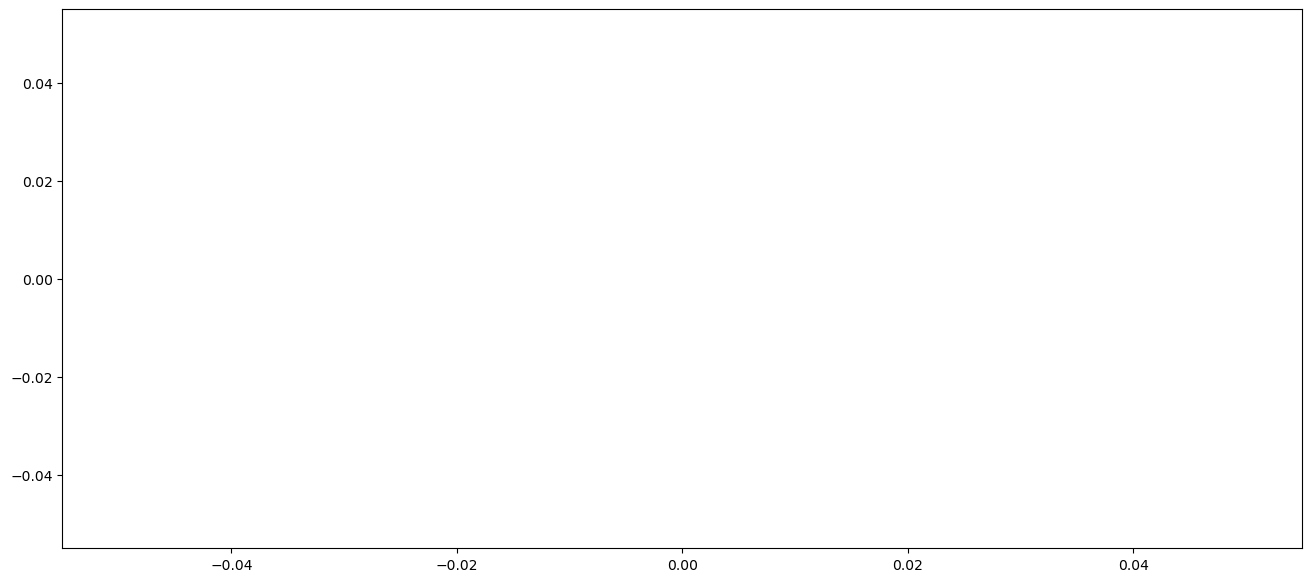

In [18]:
import matplotlib.pyplot as plt

plot_n = 2000
d = df_bt.iloc[-plot_n:].copy()

plt.figure(figsize=(16,7))

# Цена / TRAMA / VWAP
plt.plot(d.index, d["close"], label="Close", linewidth=1.2)
plt.plot(d.index, d["trama_fast"], label="TRAMA fast (5m)", alpha=0.8)
plt.plot(d.index, d["trama_slow"], label="TRAMA slow (60m ffill)", alpha=0.8)
plt.plot(d.index, d["vwap"], label="Session VWAP", linewidth=1.2, alpha=0.9)

# Pivot Zones (Supply/Demand) как "коридоры"
# Рисуем верх/низ, чтобы выглядело аккуратно
if "supTop" in d.columns and "supBot" in d.columns:
    plt.plot(d.index, d["supTop"], label="Supply Top", alpha=0.45, linewidth=1.0)
    plt.plot(d.index, d["supBot"], label="Supply Bot", alpha=0.45, linewidth=1.0)

if "demTop" in d.columns and "demBot" in d.columns:
    plt.plot(d.index, d["demTop"], label="Demand Top", alpha=0.45, linewidth=1.0)
    plt.plot(d.index, d["demBot"], label="Demand Bot", alpha=0.45, linewidth=1.0)

# Density zones (коридор)
if "densTop" in d.columns and "densBot" in d.columns:
    plt.plot(d.index, d["densTop"], label="Density Top", alpha=0.35, linewidth=1.0, linestyle=":")
    plt.plot(d.index, d["densBot"], label="Density Bot", alpha=0.35, linewidth=1.0, linestyle=":")

# Trailing stop
if "trail_stop" in d.columns:
    plt.plot(d.index, d["trail_stop"], label="Trailing Stop", linestyle="--", linewidth=1.4)

# Сделки
# Сделки (входы/выходы с цветами)
if not trades_df.empty:
    tsub = trades_df[
        trades_df["entry_ts"].between(d.index.min(), d.index.max())
    ]

    # LONG
    longs = tsub[tsub["side"] == "long"]
    if not longs.empty:
        plt.scatter(
            longs["entry_ts"],
            longs["entry_px"],
            marker="^",               # вверх
            color="green",
            s=90,
            edgecolor="black",
            linewidth=0.7,
            label="Long Entry",
            zorder=7
        )
        plt.scatter(
            longs["exit_ts"],
            longs["exit_px"],
            marker="x",
            color="green",
            s=70,
            linewidth=1.5,
            label="Long Exit",
            zorder=7
        )

    # SHORT
    shorts = tsub[tsub["side"] == "short"]
    if not shorts.empty:
        plt.scatter(
            shorts["entry_ts"],
            shorts["entry_px"],
            marker="v",               # вниз
            color="red",
            s=90,
            edgecolor="black",
            linewidth=0.7,
            label="Short Entry",
            zorder=7
        )
        plt.scatter(
            shorts["exit_ts"],
            shorts["exit_px"],
            marker="x",
            color="red",
            s=70,
            linewidth=1.5,
            label="Short Exit",
            zorder=7
        )

,Сделок,Win rate,Profit factor,Avg win ($),Avg loss ($),Expectancy ($/trade),Total return,CAGR (approx),Sharpe (5m),Sortino (5m),Max DD,Buy&Hold return,Buy&Hold CAGR,Buy&Hold Sharpe,Buy&Hold Max DD
0,124,0.443548,0.932803,409.350076,-349.79881,-13.079546,-0.075385,-0.379968,-2.269781,-1.186208,-0.141031,-0.236097,-0.806488,-2.812888,-0.380743


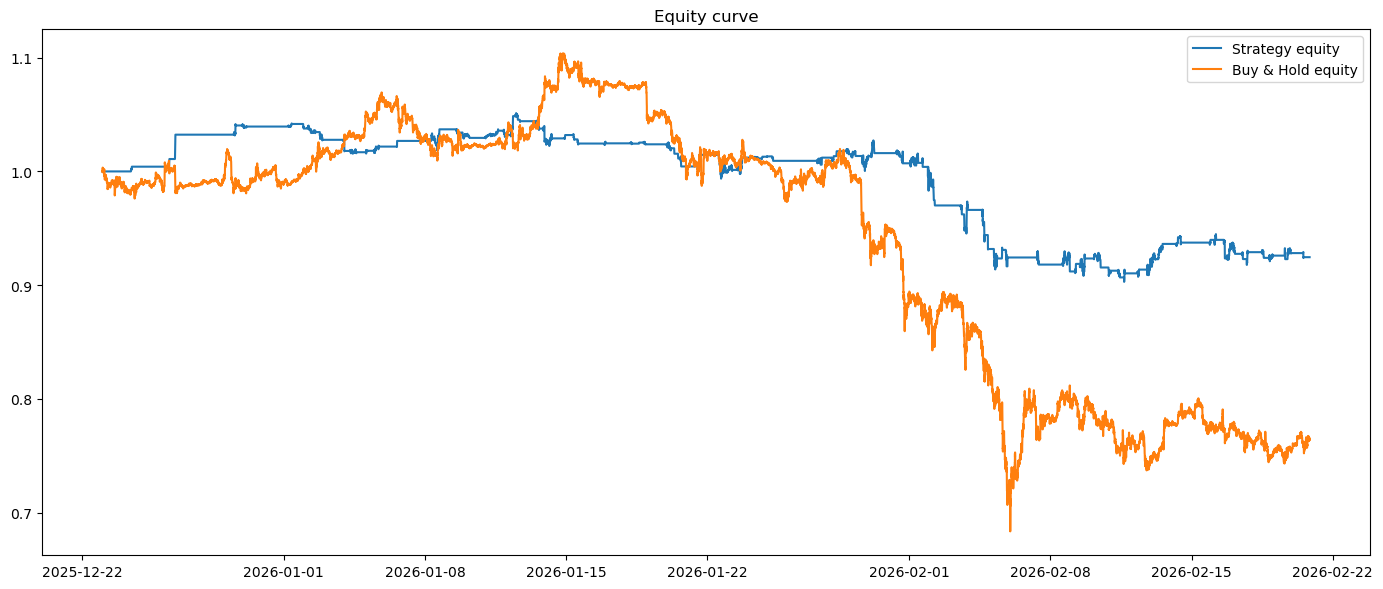

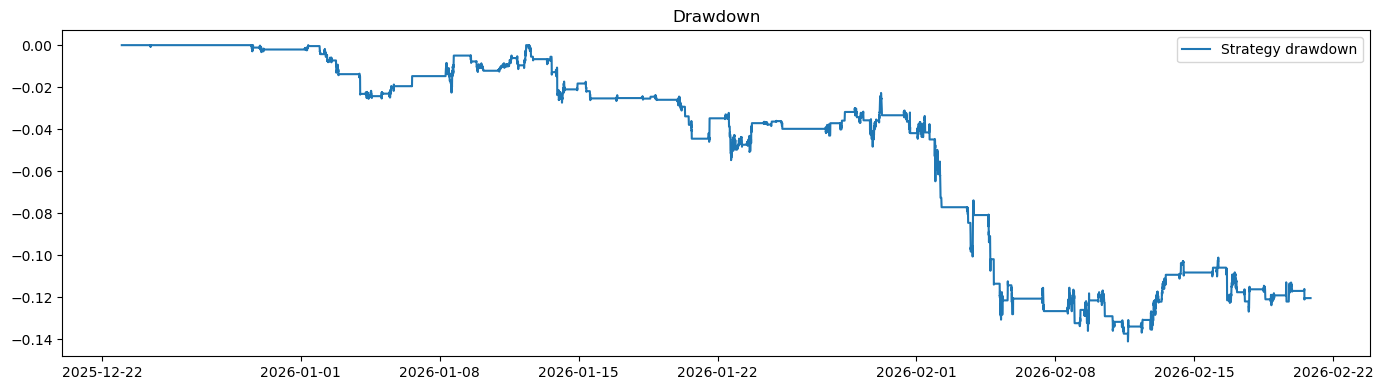

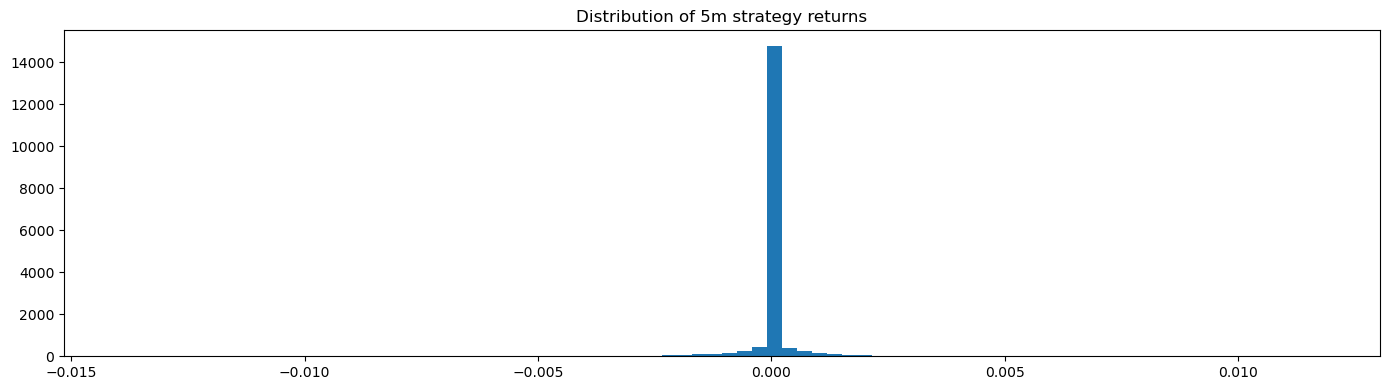

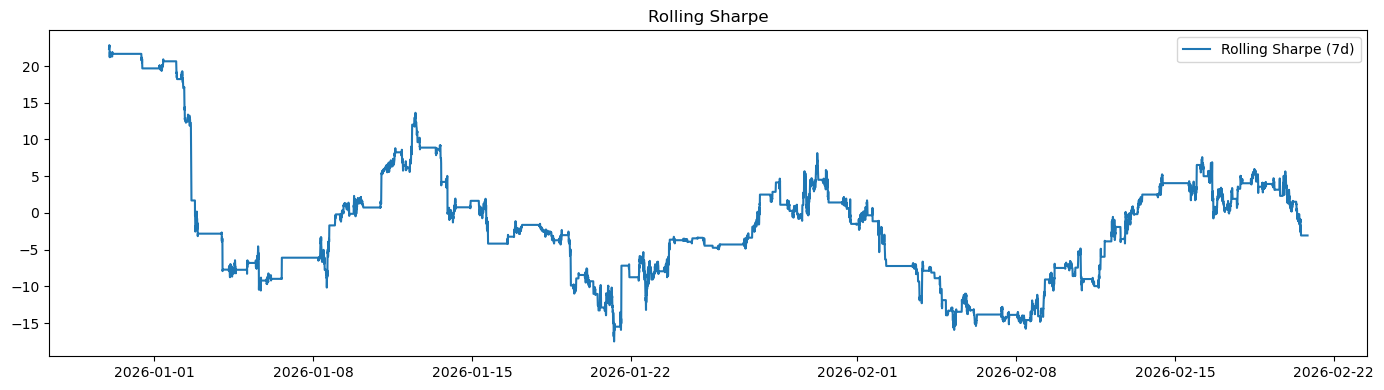

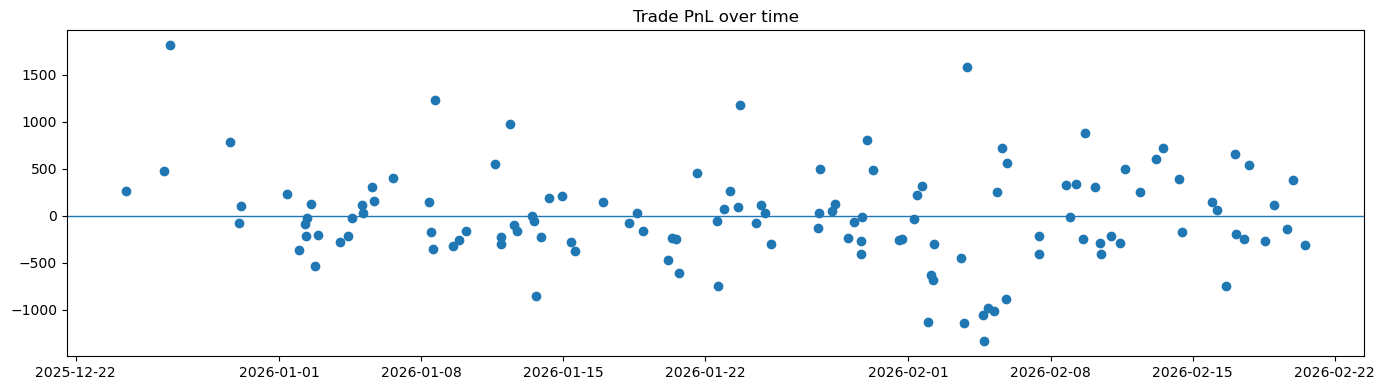

In [180]:
# ===================== CELL 9: PERFORMANCE / EQUITY / SHARPE / DRAWDOWN / PLOTS =====================
# Требует: trades_df, df_bt (как из run_backtest), и колонку df_bt["close"] с DatetimeIndex (5m)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- настройки ----------
START_EQUITY = 1.0              # стартовый капитал в "единицах"
BARS_PER_DAY = 24*60//5         # 288 для 5m
DAYS_PER_YEAR = 365
BARS_PER_YEAR = BARS_PER_DAY * DAYS_PER_YEAR
EPS = 1e-12

# ---------- safety ----------
if trades_df is None or len(trades_df) == 0:
    raise ValueError("trades_df пустой — нет сделок. Сначала запусти backtest.")

# ---------- 1) построим equity по сделкам (mark-to-market по close, без комиссий) ----------
# Позиции считаем бинарно: long=+1, short=-1. Внутри сделки держим позицию до exit_ts.
df_eq = df_bt[["close"]].copy()
df_eq["ret"] = df_eq["close"].pct_change().fillna(0.0)

# построим позицию во времени по сделкам
pos = pd.Series(0.0, index=df_eq.index)

for _, tr in trades_df.iterrows():
    if pd.isna(tr["entry_ts"]) or pd.isna(tr["exit_ts"]):
        continue
    side = 1.0 if tr["side"] == "long" else -1.0
    # позиция активна от entry_ts (включая) до exit_ts (включая) — максимально близко к логике баров
    mask = (pos.index >= tr["entry_ts"]) & (pos.index <= tr["exit_ts"])
    pos.loc[mask] = side

df_eq["pos"] = pos
df_eq["strat_ret"] = df_eq["pos"].shift(1).fillna(0.0) * df_eq["ret"]  # вход на следующем баре
df_eq["equity"] = START_EQUITY * (1.0 + df_eq["strat_ret"]).cumprod()

# buy&hold
df_eq["bh_equity"] = START_EQUITY * (1.0 + df_eq["ret"]).cumprod()

# ---------- 2) метрики ----------
def _sharpe(returns, periods_per_year):
    r = returns.dropna()
    if r.std(ddof=1) < EPS:
        return 0.0
    return (r.mean() / (r.std(ddof=1) + EPS)) * np.sqrt(periods_per_year)

def _sortino(returns, periods_per_year):
    r = returns.dropna()
    downside = r[r < 0]
    dd = downside.std(ddof=1)
    if dd < EPS:
        return 0.0
    return (r.mean() / (dd + EPS)) * np.sqrt(periods_per_year)

def _max_dd(equity):
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return dd.min(), dd

# итоговая доходность
total_return = df_eq["equity"].iloc[-1] / df_eq["equity"].iloc[0] - 1.0
bh_return    = df_eq["bh_equity"].iloc[-1] / df_eq["bh_equity"].iloc[0] - 1.0

# CAGR (примерно, по календарю из индекса)
t_years = (df_eq.index.max() - df_eq.index.min()).total_seconds() / (365*24*3600)
cagr = (df_eq["equity"].iloc[-1] / df_eq["equity"].iloc[0]) ** (1.0 / max(t_years, EPS)) - 1.0
bh_cagr = (df_eq["bh_equity"].iloc[-1] / df_eq["bh_equity"].iloc[0]) ** (1.0 / max(t_years, EPS)) - 1.0

# Sharpe/Sortino (5m)
sharpe = _sharpe(df_eq["strat_ret"], BARS_PER_YEAR)
sortino = _sortino(df_eq["strat_ret"], BARS_PER_YEAR)

bh_sharpe = _sharpe(df_eq["ret"], BARS_PER_YEAR)

# max drawdown
mdd, dd_series = _max_dd(df_eq["equity"])
bh_mdd, bh_dd  = _max_dd(df_eq["bh_equity"])

# trade stats
tr = trades_df.copy()
tr["is_win"] = tr["pnl_$"] > 0
win_rate = tr["is_win"].mean()
avg_win  = tr.loc[tr["is_win"], "pnl_$"].mean() if tr["is_win"].any() else 0.0
avg_loss = tr.loc[~tr["is_win"], "pnl_$"].mean() if (~tr["is_win"]).any() else 0.0
profit_factor = (tr.loc[tr["pnl_$"] > 0, "pnl_$"].sum() / (abs(tr.loc[tr["pnl_$"] < 0, "pnl_$"].sum()) + EPS))

# expectancy per trade
expectancy = tr["pnl_$"].mean()

# ---------- 3) вывести сводку ----------
summary = pd.DataFrame([{
    "Сделок": len(tr),
    "Win rate": win_rate,
    "Profit factor": profit_factor,
    "Avg win ($)": avg_win,
    "Avg loss ($)": avg_loss,
    "Expectancy ($/trade)": expectancy,
    "Total return": total_return,
    "CAGR (approx)": cagr,
    "Sharpe (5m)": sharpe,
    "Sortino (5m)": sortino,
    "Max DD": mdd,
    "Buy&Hold return": bh_return,
    "Buy&Hold CAGR": bh_cagr,
    "Buy&Hold Sharpe": bh_sharpe,
    "Buy&Hold Max DD": bh_mdd,
}])

display(summary)

# ---------- 4) график equity (strategy vs buy&hold) ----------
plt.figure(figsize=(14,6))
plt.plot(df_eq.index, df_eq["equity"], label="Strategy equity")
plt.plot(df_eq.index, df_eq["bh_equity"], label="Buy & Hold equity")
plt.title("Equity curve")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 5) график drawdown ----------
plt.figure(figsize=(14,4))
plt.plot(df_eq.index, dd_series, label="Strategy drawdown")
plt.title("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 6) распределение доходностей (гистограмма 5m) ----------
plt.figure(figsize=(14,4))
plt.hist(df_eq["strat_ret"].values, bins=80)
plt.title("Distribution of 5m strategy returns")
plt.tight_layout()
plt.show()

# ---------- 7) rolling Sharpe (например 7 дней) ----------
window_days = 7
window = window_days * BARS_PER_DAY

roll_mean = df_eq["strat_ret"].rolling(window).mean()
roll_std  = df_eq["strat_ret"].rolling(window).std(ddof=1)
roll_sharpe = (roll_mean / (roll_std + EPS)) * np.sqrt(BARS_PER_YEAR)

plt.figure(figsize=(14,4))
plt.plot(df_eq.index, roll_sharpe, label=f"Rolling Sharpe ({window_days}d)")
plt.title("Rolling Sharpe")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 8) scatter: trade PnL по времени ----------
plt.figure(figsize=(14,4))
plt.scatter(tr["exit_ts"], tr["pnl_$"].values)
plt.axhline(0, linewidth=1)
plt.title("Trade PnL over time")
plt.tight_layout()
plt.show()


,Total return (with fee),Sharpe (with fee),Max DD (with fee)
0,-0.152312,-4.848816,-0.193086


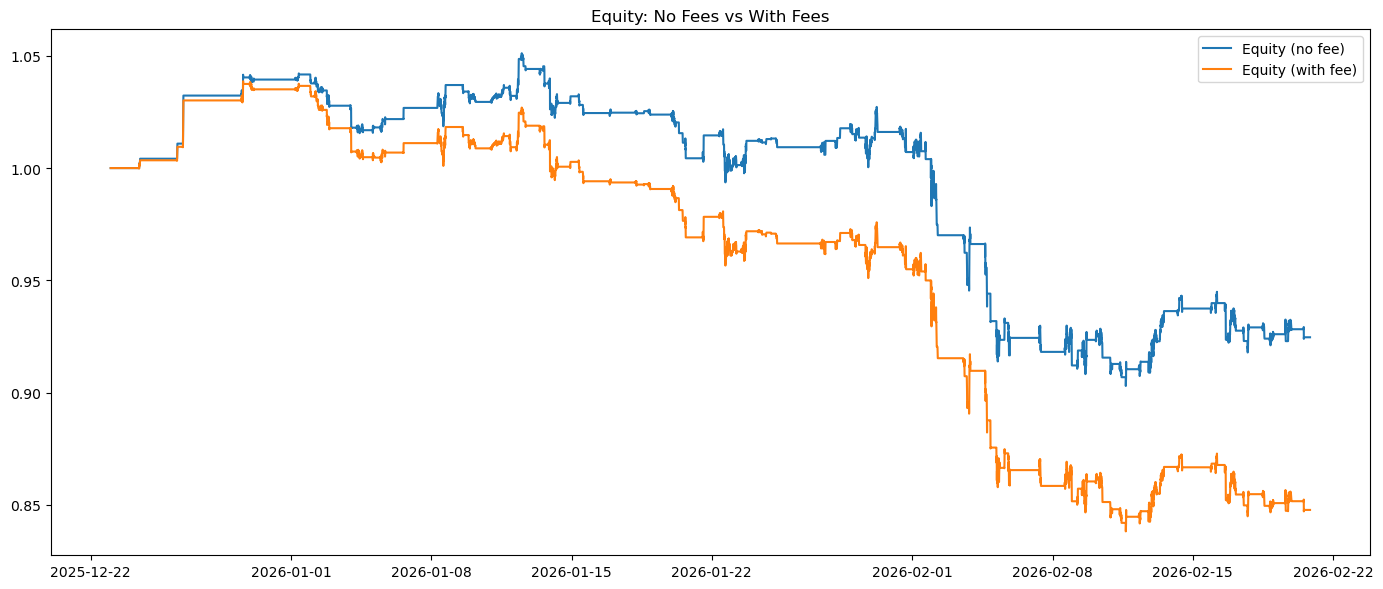

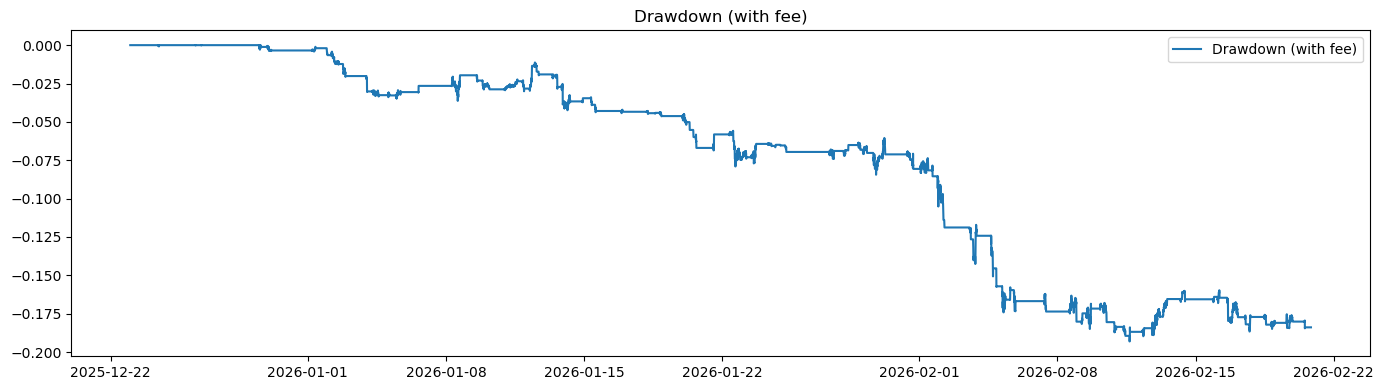

In [182]:
# ===================== CELL 10: PERFORMANCE WITH FEES =====================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAKER_FEE = 0.0002   # 0.02%
TAKER_FEE = 0.0005   # 0.05%
TOTAL_FEE = MAKER_FEE + TAKER_FEE

EPS = 1e-12

df_fee = df_eq.copy()

# --- комиссия начисляется при входе ---
entry_fee = pd.Series(0.0, index=df_fee.index)

for _, tr_row in trades_df.iterrows():
    if pd.isna(tr_row["entry_ts"]):
        continue
    if tr_row["entry_ts"] in entry_fee.index:
        entry_fee.loc[tr_row["entry_ts"]] -= MAKER_FEE

# --- комиссия начисляется при выходе ---
exit_fee = pd.Series(0.0, index=df_fee.index)

for _, tr_row in trades_df.iterrows():
    if pd.isna(tr_row["exit_ts"]):
        continue
    if tr_row["exit_ts"] in exit_fee.index:
        exit_fee.loc[tr_row["exit_ts"]] -= TAKER_FEE

# --- стратегия с учетом комиссии ---
df_fee["fee"] = entry_fee + exit_fee

df_fee["strat_ret_fee"] = (
    df_fee["pos"].shift(1).fillna(0.0) * df_fee["ret"]
    + df_fee["fee"]
)

df_fee["equity_fee"] = START_EQUITY * (1.0 + df_fee["strat_ret_fee"]).cumprod()

# ---------- Метрики с комиссией ----------

def _sharpe(r, periods):
    r = r.dropna()
    if r.std(ddof=1) < EPS:
        return 0.0
    return (r.mean() / (r.std(ddof=1) + EPS)) * np.sqrt(periods)

def _max_dd(eq):
    peak = eq.cummax()
    dd = eq / peak - 1.0
    return dd.min(), dd

total_return_fee = df_fee["equity_fee"].iloc[-1] / df_fee["equity_fee"].iloc[0] - 1.0
sharpe_fee = _sharpe(df_fee["strat_ret_fee"], BARS_PER_YEAR)
mdd_fee, dd_fee = _max_dd(df_fee["equity_fee"])

summary_fee = pd.DataFrame([{
    "Total return (with fee)": total_return_fee,
    "Sharpe (with fee)": sharpe_fee,
    "Max DD (with fee)": mdd_fee
}])

display(summary_fee)

# ---------- График equity без комиссии vs с комиссией ----------

plt.figure(figsize=(14,6))
plt.plot(df_eq.index, df_eq["equity"], label="Equity (no fee)")
plt.plot(df_fee.index, df_fee["equity_fee"], label="Equity (with fee)")
plt.title("Equity: No Fees vs With Fees")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Drawdown с комиссией ----------

plt.figure(figsize=(14,4))
plt.plot(df_fee.index, dd_fee, label="Drawdown (with fee)")
plt.title("Drawdown (with fee)")
plt.legend()
plt.tight_layout()
plt.show()

fee round-trip: 0.0007
avg gross ret/trade: 0.0006344772783220668
median gross ret/trade: 0.0003561757775505381
share trades gross > fee: 0.44061302681992337
share trades net > 0: 0.44061302681992337


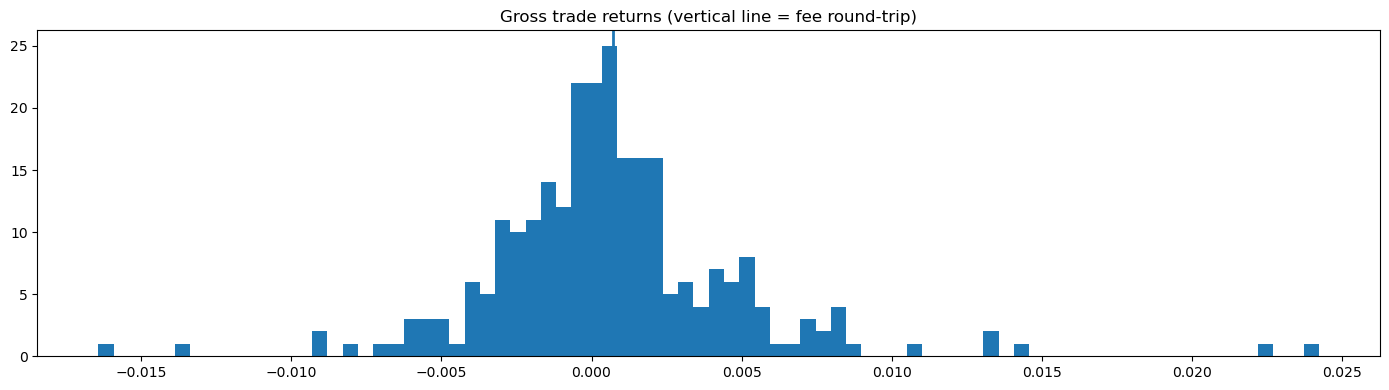

In [121]:
# ===================== DIAG: per-trade gross vs fee =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAKER_FEE = 0.0002
TAKER_FEE = 0.0005
FEE_RT = MAKER_FEE + TAKER_FEE

t = trades_df.dropna(subset=["entry_px","exit_px","side"]).copy()
side = np.where(t["side"].str.lower().values == "long", 1.0, -1.0)

t["ret_gross"] = side * (t["exit_px"].values / t["entry_px"].values - 1.0)
t["ret_net"]   = t["ret_gross"] - FEE_RT

print("fee round-trip:", FEE_RT)
print("avg gross ret/trade:", float(t["ret_gross"].mean()))
print("median gross ret/trade:", float(t["ret_gross"].median()))
print("share trades gross > fee:", float((t["ret_gross"] > FEE_RT).mean()))
print("share trades net > 0:", float((t["ret_net"] > 0).mean()))

plt.figure(figsize=(14,4))
plt.hist(t["ret_gross"].values, bins=80)
plt.axvline(FEE_RT, linewidth=2)
plt.title("Gross trade returns (vertical line = fee round-trip)")
plt.tight_layout()
plt.show()

In [183]:
# ===================== MONTE CARLO SPACE (CT ONLY + FEES-AWARE FILTERS) =====================
import numpy as np
import pandas as pd

PARAM_SPACE = {
    # ===== TRAMA TIMEFRAMES (CAT ONLY) =====
    "tfFast": {"type": "cat", "values": ["5m"], "priority": 8},
    "tfSlow": {"type": "cat", "values": ["120m", "180m", "360m"], "priority": 2},

    # ===== TRAMA / ATR / CT =====
    "lenFast":    {"type": "int",   "min": 10, "max": 60, "step": 5,    "priority": 1},
    "lenSlow":    {"type": "int",   "min": 20, "max": 120,"step": 10,   "priority": 2},

    # ⚠️ было step=30 => [20,50]. Если хочешь богаче сетку — ставь 10
    "atrLen":     {"type": "int",   "min": 20, "max": 50, "step": 30,   "priority": 10},

    "minDistATR": {"type": "float", "min": 8.5, "max": 14.0, "step": 0.5, "priority": 4},

    # ===== TRAILING (CT ONLY) =====
    "trailATR_CT": {"type": "float", "min": 3.0, "max": 7.0, "step": 0.5, "priority": 3},

    # ===== MIN STOP (points) =====
    "minStopPts": {"type": "int", "min": 200, "max": 900, "step": 100, "priority": 6},

    # ===== MIN POTENTIAL filter (>= mult * fee_rt) =====
    "minPotMult": {"type": "float", "min": 2.0, "max": 5.0, "step": 0.5, "priority": 5},
}

def _grid_values(spec):
    t = spec["type"]
    if t == "cat":
        return list(spec["values"])
    if t == "int":
        return list(range(int(spec["min"]), int(spec["max"]) + 1, int(spec["step"])))
    if t == "float":
        n = int(round((spec["max"] - spec["min"]) / spec["step"])) + 1
        vals = [spec["min"] + i * spec["step"] for i in range(n)]
        return [float(f"{v:.10g}") for v in vals]
    raise ValueError(spec)

def _sample_one(rng: np.random.Generator, space: dict, pr_bias: float = 1.35):
    p = {}
    for k, spec in space.items():
        vals = _grid_values(spec)
        pr = int(spec.get("priority", 1))
        p_rand = min(0.95, 0.15 * (pr_bias ** (pr-1)))
        p[k] = rng.choice(vals) if rng.random() < p_rand else vals[len(vals)//2]

    # ---- constraint: tfSlow > tfFast ----
    tf_fast = int(str(p["tfFast"]).replace("m",""))
    tf_slow = int(str(p["tfSlow"]).replace("m",""))
    if tf_slow <= tf_fast:
        slow_vals = sorted([int(str(v).replace("m","")) for v in _grid_values(space["tfSlow"])])
        pick = next((v for v in slow_vals if v > tf_fast), slow_vals[-1])
        p["tfSlow"] = f"{pick}m"

    return p

def sample_params(n=300, seed=42):
    rng = np.random.default_rng(seed)
    return [_sample_one(rng, PARAM_SPACE) for _ in range(n)]

pd.DataFrame(sample_params(n=5, seed=1))

,tfFast,tfSlow,lenFast,lenSlow,atrLen,minDistATR,trailATR_CT,minStopPts,minPotMult
0,5m,180m,55,70,50,11.5,5.0,200,3.5
1,5m,180m,35,70,20,10.5,4.5,200,4.5
2,5m,180m,35,70,50,10.0,5.0,400,3.5
3,5m,180m,35,30,50,11.0,5.0,600,3.5
4,5m,180m,35,70,20,11.5,5.0,600,2.5


In [144]:
# ===================== IGNORE WARNINGS =====================
import warnings

# отключить ВСЕ предупреждения
warnings.filterwarnings("ignore")

# если используешь numpy / pandas часто ругаются на RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

# если pandas FutureWarning мешают
warnings.filterwarnings("ignore", category=FutureWarning)

print("Warnings disabled.")

Warnings disabled.


In [184]:
# ===================== ONE CELL: eval_one() for MC (CT ONLY + FEES, NO ZONE RETEST) =====================
import numpy as np
import pandas as pd

# ---------- FEES (консервативно: вход=maker, выход=taker) ----------
MAKER_FEE = 0.0002
TAKER_FEE = 0.0005
FEE_RT = MAKER_FEE + TAKER_FEE
EPS = 1e-12

# ---------- MOMENTUM DEFAULTS ----------
MOM_MODE_DEFAULT = "strong"   # "sign" or "strong"
MOM_Q_DEFAULT    = 0.70
MOM_ROLL_DEFAULT = 300

# ---------- helper: safe resample aggregation ----------
def _resample_ohlc_safe(df_in: pd.DataFrame, tf: str) -> pd.DataFrame:
    x = normalize_ohlcv_columns(df_in).copy()
    rule = tf
    if isinstance(tf, str) and tf.lower().endswith("m") and not tf.lower().endswith("min"):
        rule = tf[:-1] + "min"

    o = x["open"].resample(rule).first()
    h = x["high"].resample(rule).max()
    l = x["low"].resample(rule).min()
    c = x["close"].resample(rule).last()
    out = pd.concat([o, h, l, c], axis=1)
    out.columns = ["open","high","low","close"]
    if "volume" in x.columns:
        out["volume"] = x["volume"].resample(rule).sum()
    return out.dropna()

def _trade_net_returns(trades_df: pd.DataFrame) -> pd.Series:
    if trades_df is None or len(trades_df) == 0:
        return pd.Series(dtype=float)

    t = trades_df.dropna(subset=["entry_px","exit_px","side"]).copy()
    if len(t) == 0:
        return pd.Series(dtype=float)

    side = np.where(t["side"].str.lower().values == "long", 1.0, -1.0)
    gross = side * (t["exit_px"].values / t["entry_px"].values - 1.0)
    net = gross - FEE_RT

    idx = pd.to_datetime(t["exit_ts"], errors="coerce")
    if idx.notna().any():
        return pd.Series(net, index=idx).sort_index()
    return pd.Series(net)

def _max_dd(eq: pd.Series) -> float:
    if eq is None or len(eq) == 0:
        return 0.0
    peak = eq.cummax()
    dd = eq / peak - 1.0
    return float(dd.min())

def _sharpe(r: pd.Series, trades_per_year: float = 365.0) -> float:
    r = r.dropna()
    if len(r) < 2:
        return 0.0
    sd = float(r.std(ddof=1))
    if sd < EPS:
        return 0.0
    return float((r.mean() / (sd + EPS)) * np.sqrt(trades_per_year))

# ---------- CT core builder (NO ZONES) ----------
def _build_ct_core(df_src: pd.DataFrame, p: dict) -> pd.DataFrame:
    tf_fast = str(p["tfFast"])
    tf_slow = str(p["tfSlow"])

    lenFast = int(p["lenFast"])
    lenSlow = int(p["lenSlow"])
    atrLen  = int(p["atrLen"])

    base = normalize_ohlcv_columns(df_src).copy()

    # ATR
    base["atr"] = atr(base["high"], base["low"], base["close"], atrLen)

    # delta
    if "volume" not in base.columns:
        raise ValueError("Нужен volume для delta/momentum.")
    rng = (base["high"] - base["low"]).clip(lower=1e-9)
    base["delta"] = base["volume"] * (base["close"] - base["open"]) / rng

    # TRAMA fast/slow
    fast = _resample_ohlc_safe(df_src, tf_fast)
    fast["trama_fast_tf"] = trama(fast["close"], fast["high"], fast["low"], lenFast)
    base["trama_fast"] = fast["trama_fast_tf"].reindex(base.index, method="ffill")

    slow = _resample_ohlc_safe(df_src, tf_slow)
    slow["trama_slow_tf"] = trama(slow["close"], slow["high"], slow["low"], lenSlow)
    base["trama_slow"] = slow["trama_slow_tf"].reindex(base.index, method="ffill")

    # VWAP
    base["vwap"] = session_vwap(base)

    return base

# ---------- signals (NO ZONE RETEST) ----------
def _build_signals(df: pd.DataFrame, p: dict) -> pd.DataFrame:
    x = df.copy()

    minDistATR = float(p["minDistATR"])

    MOM_MODE = MOM_MODE_DEFAULT
    MOM_Q    = MOM_Q_DEFAULT
    MOM_ROLL = MOM_ROLL_DEFAULT

    # A) MOMENTUM
    if MOM_MODE == "sign":
        x["momLong"]  = x["delta"] > 0
        x["momShort"] = x["delta"] < 0
    elif MOM_MODE == "strong":
        thr = x["delta"].abs().rolling(MOM_ROLL, min_periods=max(50, MOM_ROLL//3)).quantile(MOM_Q)
        x["momLong"]  = (x["delta"] > 0) & (x["delta"].abs() >= thr)
        x["momShort"] = (x["delta"] < 0) & (x["delta"].abs() >= thr)
    else:
        raise ValueError("MOM_MODE должен быть 'sign' или 'strong'")

    # B) OLD CONDITIONS
    prev_close = x["close"].shift(1)
    prev_fast  = x["trama_fast"].shift(1)
    x["crossUp"]   = (prev_close <= prev_fast) & (x["close"] > x["trama_fast"])
    x["crossDown"] = (prev_close >= prev_fast) & (x["close"] < x["trama_fast"])

    x["distLong"]  = x["trama_slow"] - x["close"]
    x["distShort"] = x["close"] - x["trama_slow"]
    x["validDistLong"]  = x["distLong"]  > x["atr"] * minDistATR
    x["validDistShort"] = x["distShort"] > x["atr"] * minDistATR

    x["ctLong_OK"]  = (x["close"] < x["vwap"])
    x["ctShort_OK"] = (x["close"] > x["vwap"])

    old_long  = x["ctLong_OK"]  & x["crossUp"]   & x["validDistLong"]  & x["momLong"].fillna(False)
    old_short = x["ctShort_OK"] & x["crossDown"] & x["validDistShort"] & x["momShort"].fillna(False)

    # C) TRAMA DIRECTION
    trama_dir_long  = x["trama_slow"] > x["trama_fast"]
    trama_dir_short = x["trama_slow"] < x["trama_fast"]

    # D) FINAL ENTRIES
    x["ctLongEntry"]  = old_long  & trama_dir_long
    x["ctShortEntry"] = old_short & trama_dir_short

    for col in ["crossUp","crossDown","validDistLong","validDistShort","ctLong_OK","ctShort_OK",
                "momLong","momShort","ctLongEntry","ctShortEntry"]:
        x[col] = x[col].fillna(False)

    return x

# ---------- backtest (CT ONLY) with min stop pts + TP on slow TRAMA ----------
def _run_backtest_ct(df: pd.DataFrame, p: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    trailATR_CT = float(p["trailATR_CT"])
    minStopPts  = float(p.get("minStopPts", 300))
    minPotMult  = float(p.get("minPotMult", 2.0))

    df = df.copy()
    df["trail_stop"] = np.nan
    df["trail_stop_side"] = ""
    df["pos_dir"] = 0
    df["skip_long"] = False
    df["skip_short"] = False
    df["pot_long"] = np.nan
    df["pot_short"] = np.nan

    pos = 0
    trailL = np.nan
    trailS = np.nan

    trades = []
    cur = None

    def _min_potential_ok(side: str, entry_px: float, target_px: float):
        if not np.isfinite(entry_px) or entry_px <= 0 or not np.isfinite(target_px):
            return False, np.nan
        pot = (target_px - entry_px) / entry_px if side == "long" else (entry_px - target_px) / entry_px
        ok = pot >= (minPotMult * FEE_RT)
        return ok, float(pot)

    for i in range(2, len(df)):
        row = df.iloc[i]

        if np.isnan(row["trama_slow"]) or np.isnan(row["trama_fast"]) or np.isnan(row["atr"]) or np.isnan(row["vwap"]):
            continue

        close = float(row["close"])
        high  = float(row["high"])
        low   = float(row["low"])
        slow  = float(row["trama_slow"])
        atrv  = float(row["atr"])

        # ENTRY + min potential filter (target = slow)
        if pos == 0:
            if bool(row.get("ctLongEntry", False)):
                ok, pot = _min_potential_ok("long", close, slow)
                df.iloc[i, df.columns.get_loc("pot_long")] = pot
                if not ok:
                    df.iloc[i, df.columns.get_loc("skip_long")] = True
                else:
                    pos = 1
                    cur = {"entry_ts": df.index[i], "side": "long", "entry_px": close, "pot_at_entry": pot}
                    trades.append(cur)
                    trailL = np.nan
                    trailS = np.nan

            elif bool(row.get("ctShortEntry", False)):
                ok, pot = _min_potential_ok("short", close, slow)
                df.iloc[i, df.columns.get_loc("pot_short")] = pot
                if not ok:
                    df.iloc[i, df.columns.get_loc("skip_short")] = True
                else:
                    pos = -1
                    cur = {"entry_ts": df.index[i], "side": "short", "entry_px": close, "pot_at_entry": pot}
                    trades.append(cur)
                    trailL = np.nan
                    trailS = np.nan

            df.iloc[i, df.columns.get_loc("pos_dir")] = pos
            continue

        # EXIT: TP touch slow
        if pos > 0 and high >= slow:
            cur["exit_ts"] = df.index[i]
            cur["exit_px"] = float(slow)
            cur["reason"] = "CT TP: touch slow TRAMA"
            pos = 0
            df.iloc[i, df.columns.get_loc("pos_dir")] = 0
            continue

        if pos < 0 and low <= slow:
            cur["exit_ts"] = df.index[i]
            cur["exit_px"] = float(slow)
            cur["reason"] = "CT TP: touch slow TRAMA"
            pos = 0
            df.iloc[i, df.columns.get_loc("pos_dir")] = 0
            continue

        # TRAILING: ATR*mult but not less than minStopPts
        stop_dist = max(atrv * trailATR_CT, minStopPts)

        if pos > 0:
            new_trail = close - stop_dist
            trailL = new_trail if np.isnan(trailL) else max(trailL, new_trail)
            df.iloc[i, df.columns.get_loc("trail_stop")] = float(trailL)
            df.iloc[i, df.columns.get_loc("trail_stop_side")] = "L"
            if low <= trailL:
                cur["exit_ts"] = df.index[i]
                cur["exit_px"] = float(trailL)
                cur["reason"] = "Trailing stop hit (long)"
                pos = 0
        else:
            new_trail = close + stop_dist
            trailS = new_trail if np.isnan(trailS) else min(trailS, new_trail)
            df.iloc[i, df.columns.get_loc("trail_stop")] = float(trailS)
            df.iloc[i, df.columns.get_loc("trail_stop_side")] = "S"
            if high >= trailS:
                cur["exit_ts"] = df.index[i]
                cur["exit_px"] = float(trailS)
                cur["reason"] = "Trailing stop hit (short)"
                pos = 0

        df.iloc[i, df.columns.get_loc("pos_dir")] = pos

    # close at end
    if pos != 0 and cur is not None and ("exit_ts" not in cur):
        cur["exit_ts"] = df.index[-1]
        cur["exit_px"] = float(df["close"].iloc[-1])
        cur["reason"] = "End of data"

    out = []
    for t in trades:
        if "exit_ts" not in t:
            continue
        entry = float(t["entry_px"])
        exitp = float(t["exit_px"])
        side  = t["side"]
        pnl   = (exitp - entry) if side == "long" else (entry - exitp)
        out.append({
            "entry_ts": t["entry_ts"], "exit_ts": t["exit_ts"],
            "side": side,
            "entry_px": entry, "exit_px": exitp,
            "pnl_$": pnl,
            "pot_at_entry": t.get("pot_at_entry", np.nan),
            "reason": t.get("reason", "")
        })
    trades_df = pd.DataFrame(out)
    return trades_df, df

# ---------- main eval_one ----------
def eval_one(p: dict, run_id: int = 0):
    df_core = _build_ct_core(DF_SRC, p)
    df_sig  = _build_signals(df_core, p)
    trades_df, df_bt = _run_backtest_ct(df_sig, p)

    r = _trade_net_returns(trades_df)
    n_trades = int(len(r))
    if n_trades == 0:
        total_return = -1.0
        sharpe = 0.0
        max_dd = 0.0
        win_rate = 0.0
        eq = pd.Series(dtype=float)
    else:
        eq = (1.0 + r).cumprod()
        total_return = float(eq.iloc[-1] - 1.0)
        max_dd = _max_dd(eq)
        sharpe = _sharpe(r, trades_per_year=365.0)
        win_rate = float((r > 0).mean())

    return {
        "run_id": int(run_id),
        "params": dict(p),
        "trades": trades_df,
        "bt": df_bt,
        "series": eq,
        "total_return": total_return,
        "sharpe": sharpe,
        "max_dd": max_dd,
        "n_trades": n_trades,
        "win_rate": win_rate,
    }

print("[OK] eval_one defined (NO zone retest, NO zones builder).")

[OK] eval_one defined (NO zone retest, NO zones builder).


In [186]:
# ===================== SEARCH CELL 1 (PRUNING, NET METRICS): STAGE 1 RANDOM + CUT BAD REGIONS =====================
import numpy as np
import pandas as pd
import math

# ---------- SETTINGS ----------
N_RUNS_STAGE1 = 500
SEED_STAGE1 = 42
RANK_BY = "total_return"     # "sharpe" или "total_return"
PRINT_EVERY = 100

# pruning controls
TOP_KEEP_PCT = 0.35
MIN_SUPPORT = 8
MIN_KEEP_PER_PARAM = 2

EPS = 1e-12

# ---------- DATA SOURCE ----------
if "df_raw" in globals() and isinstance(df_raw, pd.DataFrame) and len(df_raw) > 0:
    DF_SRC = normalize_ohlcv_columns(df_raw.copy())
else:
    DF_SRC = normalize_ohlcv_columns(df.copy())

# ---------- HELPERS ----------
def _grid_values(spec):
    t = spec["type"]
    if t == "cat":
        return list(spec["values"])
    if t == "int":
        return list(range(int(spec["min"]), int(spec["max"]) + 1, int(spec["step"])))
    if t == "float":
        n = int(round((spec["max"] - spec["min"]) / spec["step"])) + 1
        vals = [spec["min"] + i * spec["step"] for i in range(n)]
        return [float(f"{v:.10g}") for v in vals]
    raise ValueError(spec)

def sample_one_params(rng: np.random.Generator, space: dict, pr_bias: float = 1.35):
    p = {}
    for k, spec in space.items():
        vals = _grid_values(spec)
        pr = int(spec.get("priority", 1))
        p_rand = min(0.95, 0.15 * (pr_bias ** (pr-1)))
        p[k] = rng.choice(vals) if rng.random() < p_rand else vals[len(vals)//2]

    # ---- constraint: tfSlow > tfFast ----
    tf_fast = int(str(p["tfFast"]).replace("m",""))
    tf_slow = int(str(p["tfSlow"]).replace("m",""))
    if tf_slow <= tf_fast:
        slow_vals = sorted([int(str(v).replace("m","")) for v in _grid_values(space["tfSlow"])])
        pick = next((v for v in slow_vals if v > tf_fast), slow_vals[-1])
        p["tfSlow"] = f"{pick}m"

    return p

def _summarize_run(out: dict) -> dict:
    """
    Берём метрики прямо из eval_one().
    ВАЖНО: так мы не вычитаем комиссии второй раз.
    """
    return {
        "total_return": float(out.get("total_return", -1.0)),
        "sharpe": float(out.get("sharpe", 0.0)),
        "max_dd": float(out.get("max_dd", 0.0)),
        "n_trades": int(out.get("n_trades", 0)),
        "win_rate": float(out.get("win_rate", 0.0)),
    }

# ---------- RUN STAGE 1 ----------
rng = np.random.default_rng(SEED_STAGE1)

STAGE1 = {"summary": [], "params": {}, "trades": {}, "bt": {}, "series": {}}

for i in range(N_RUNS_STAGE1):
    p = sample_one_params(rng, PARAM_SPACE)

    try:
        out = eval_one(p, run_id=i)

        # сохраняем артефакты
        STAGE1["params"][i]  = out.get("params", p)
        STAGE1["trades"][i]  = out.get("trades", None)
        STAGE1["bt"][i]      = out.get("bt", None)
        STAGE1["series"][i]  = out.get("series", None)

        m = _summarize_run(out)

        row = {"run_id": i, "error": np.nan} | m | STAGE1["params"][i]
        STAGE1["summary"].append(row)

    except Exception as e:
        STAGE1["summary"].append({"run_id": i, "error": str(e)} | p)

    if (i + 1) % PRINT_EVERY == 0:
        df_s = pd.DataFrame(STAGE1["summary"])
        ok = df_s[df_s["error"].isna()].copy() if "error" in df_s.columns else df_s
        best = ok[RANK_BY].max() if len(ok) else None
        print(f"[Stage1] {i+1}/{N_RUNS_STAGE1} | ok={len(ok)} | best_{RANK_BY}={best}")

STAGE1_SUMMARY = pd.DataFrame(STAGE1["summary"])
OK1 = STAGE1_SUMMARY[STAGE1_SUMMARY.get("error").isna()] if "error" in STAGE1_SUMMARY.columns else STAGE1_SUMMARY.copy()
print("[Stage1] finished | ok:", len(OK1))

# ---------- TOP 5 ----------
TOP5_STAGE1 = OK1.sort_values(RANK_BY, ascending=False).head(5).reset_index(drop=True)

display_cols = [
    "run_id","total_return","sharpe","max_dd","n_trades","win_rate",
    "tfFast","tfSlow","lenFast","lenSlow","atrLen","minDistATR","trailATR_CT",
    "minStopPts","minPotMult"
]
display_cols = [c for c in display_cols if c in TOP5_STAGE1.columns]
display(TOP5_STAGE1[display_cols])

# ---------- PRUNING ----------
def prune_space_from_stage1(ok_df: pd.DataFrame, space: dict, rank_by: str,
                            top_keep_pct: float, min_support: int, min_keep: int):
    pruned = {}
    stats_rows = []

    for k, spec in space.items():
        if k not in ok_df.columns:
            pruned[k] = spec.copy()
            continue

        g = ok_df[[k, rank_by]].dropna().groupby(k)[rank_by].agg(["count","median","mean"]).reset_index()
        g = g.sort_values("median", ascending=False)

        g_sup = g[g["count"] >= min_support].copy()

        if len(g_sup) < min_keep:
            keep_vals = list(g.sort_values("count", ascending=False)[k].head(min_keep).values)
        else:
            n_keep = max(min_keep, int(math.ceil(len(g_sup) * top_keep_pct)))
            keep_vals = list(g_sup.head(n_keep)[k].values)

        pruned[k] = {"type": "cat", "values": keep_vals, "priority": spec.get("priority", 1)}

        g["param"] = k
        stats_rows.append(g.rename(columns={k: "value"}))

    stats = pd.concat(stats_rows, ignore_index=True) if len(stats_rows) else pd.DataFrame()
    return pruned, stats

PRUNED_SPACE, PRUNE_STATS = prune_space_from_stage1(
    OK1, PARAM_SPACE, RANK_BY,
    top_keep_pct=TOP_KEEP_PCT,
    min_support=MIN_SUPPORT,
    min_keep=MIN_KEEP_PER_PARAM
)

print("\n[Pruning] space sizes:")
for k in PRUNED_SPACE.keys():
    if PRUNED_SPACE[k]["type"] == "cat":
        print(f"  {k:12s}: {len(PRUNED_SPACE[k]['values'])}")

display(PRUNE_STATS.sort_values(["param","median"], ascending=[True, False]).head(30))

[Stage1] 100/500 | ok=100 | best_total_return=0.09733184357648894
[Stage1] 200/500 | ok=200 | best_total_return=0.09733184357648894
[Stage1] 300/500 | ok=300 | best_total_return=0.09733184357648894
[Stage1] 400/500 | ok=400 | best_total_return=0.09733184357648894
[Stage1] 500/500 | ok=500 | best_total_return=0.09733184357648894
[Stage1] finished | ok: 500


,run_id,total_return,sharpe,max_dd,n_trades,win_rate,tfFast,tfSlow,lenFast,lenSlow,atrLen,minDistATR,trailATR_CT,minStopPts,minPotMult
0,27,0.097332,4.115848,-0.053818,31,0.548387,5m,180m,55,70,50,11.5,5.0,800,3.5
1,206,0.063314,3.297794,-0.054789,33,0.545455,5m,180m,55,70,20,10.0,5.0,400,3.5
2,400,0.061700,2.578396,-0.084436,28,0.571429,5m,180m,60,70,20,11.5,7.0,900,3.5
3,301,0.056232,3.702248,-0.054012,25,0.600000,5m,360m,35,100,20,11.5,5.0,400,2.0
4,164,0.048080,3.794594,-0.040686,33,0.545455,5m,180m,55,70,50,14.0,4.0,300,3.0



[Pruning] space sizes:
  tfFast      : 1
  tfSlow      : 2
  lenFast     : 2
  lenSlow     : 3
  atrLen      : 2
  minDistATR  : 5
  trailATR_CT : 4
  minStopPts  : 3
  minPotMult  : 3


,value,count,median,mean,param
26,50,245,-0.045501,-0.041292,atrLen
27,20,255,-0.052610,-0.046217,atrLen
4,50,3,0.029758,0.012847,lenFast
5,55,10,0.027962,0.032085,lenFast
6,60,8,-0.003720,0.002392,lenFast
7,20,3,-0.009296,-0.005950,lenFast
8,40,5,-0.041707,-0.027400,lenFast
9,15,7,-0.046265,-0.037605,lenFast
10,35,433,-0.046966,-0.044241,lenFast
11,25,7,-0.051721,-0.056200,lenFast


In [187]:
# ===================== SEARCH CELL 2 (PRUNED LOCAL, NET METRICS): STAGE 2 AROUND TOP-5 =====================
import numpy as np
import pandas as pd

if "TOP5_STAGE1" not in globals() or len(TOP5_STAGE1) == 0:
    raise ValueError("Сначала запусти Stage1 pruning ячейку.")
if "PRUNED_SPACE" not in globals():
    raise ValueError("Нет PRUNED_SPACE — Stage1 pruning не отработал.")
if "_grid_values" not in globals():
    raise ValueError("Нет _grid_values — он создаётся в Stage1 ячейке.")

# ---------- SETTINGS ----------
LOCAL_SAMPLES_PER_BASE = 100
SEED_STAGE2 = 123
PRINT_EVERY = 50
RANK_BY_STAGE2 = RANK_BY

rng = np.random.default_rng(SEED_STAGE2)

def _vals_from_space(space: dict, k: str):
    spec = space[k]
    if spec["type"] != "cat":
        return _grid_values(spec)
    return list(spec["values"])

def _neighbors_restricted(k: str, base_val, full_space: dict, pruned_space: dict):
    spec_full = full_space[k]
    allowed = set(_vals_from_space(pruned_space, k))
    full_vals = _grid_values(spec_full) if spec_full["type"] != "cat" else list(spec_full["values"])

    if spec_full["type"] == "cat":
        if base_val not in full_vals:
            base_val = full_vals[len(full_vals)//2]
        i = full_vals.index(base_val)
        cand = [base_val]
        if i-1 >= 0: cand.append(full_vals[i-1])
        if i+1 < len(full_vals): cand.append(full_vals[i+1])
        cand = [v for v in cand if v in allowed]
        return list(dict.fromkeys(cand)) if len(cand) else sorted(list(allowed))

    if spec_full["type"] == "int":
        step = int(spec_full["step"])
        cand = [int(base_val), int(base_val-step), int(base_val+step)]
        cand = [v for v in cand if v in allowed]
        return sorted(list(dict.fromkeys(cand))) if len(cand) else sorted(list(allowed))

    if spec_full["type"] == "float":
        step = float(spec_full["step"])
        cand0 = [float(base_val), float(base_val-step), float(base_val+step)]
        allowed_list = sorted(list(allowed))
        cand = []
        for v in cand0:
            nearest = min(allowed_list, key=lambda z: abs(z - v))
            cand.append(float(nearest))
        cand = [v for v in cand if v in allowed]
        return sorted(list(dict.fromkeys(cand))) if len(cand) else allowed_list

    return sorted(list(allowed))

def _is_valid_params(p: dict):
    tf_fast = int(str(p["tfFast"]).replace("m",""))
    tf_slow = int(str(p["tfSlow"]).replace("m",""))
    return (tf_slow > tf_fast)

def sample_local_pruned(base_params: dict, full_space: dict, pruned_space: dict, n: int, rng: np.random.Generator):
    keys = list(full_space.keys())
    neigh = {k: _neighbors_restricted(k, base_params[k], full_space, pruned_space) for k in keys}

    out = []
    seen = set()
    max_tries = n * 80

    tries = 0
    while len(out) < n and tries < max_tries:
        tries += 1
        p = {k: rng.choice(neigh[k]) for k in keys}
        if not _is_valid_params(p):
            continue
        key = tuple((k, p[k]) for k in keys)
        if key in seen:
            continue
        seen.add(key)
        out.append(p)

    return out

def _summarize_run(out: dict) -> dict:
    return {
        "total_return": float(out.get("total_return", -1.0)),
        "sharpe": float(out.get("sharpe", 0.0)),
        "max_dd": float(out.get("max_dd", 0.0)),
        "n_trades": int(out.get("n_trades", 0)),
        "win_rate": float(out.get("win_rate", 0.0)),
    }

# ---------- build run list around TOP-5 ----------
stage2_run_list = []
for r in TOP5_STAGE1.to_dict("records"):
    rid = int(r["run_id"])
    base_p = STAGE1["params"][rid]
    stage2_run_list.extend(sample_local_pruned(base_p, PARAM_SPACE, PRUNED_SPACE, LOCAL_SAMPLES_PER_BASE, rng))

# global dedup
keys = list(PARAM_SPACE.keys())
seen = set()
RUN_LIST_STAGE2 = []
for p in stage2_run_list:
    key = tuple((k, p[k]) for k in keys)
    if key not in seen:
        seen.add(key)
        RUN_LIST_STAGE2.append(p)

print("[Stage2] runs to execute:", len(RUN_LIST_STAGE2))

# ---------- run stage2 ----------
STAGE2 = {"summary": [], "params": {}, "trades": {}, "bt": {}, "series": {}}

for run_id, p in enumerate(RUN_LIST_STAGE2):
    try:
        out = eval_one(p, run_id=run_id)

        STAGE2["params"][run_id] = out.get("params", p)
        STAGE2["trades"][run_id] = out.get("trades", None)
        STAGE2["bt"][run_id]     = out.get("bt", None)
        STAGE2["series"][run_id] = out.get("series", None)

        m = _summarize_run(out)
        STAGE2["summary"].append({"run_id": run_id, "error": np.nan} | m | STAGE2["params"][run_id])

    except Exception as e:
        STAGE2["summary"].append({"run_id": run_id, "error": str(e)} | p)

    if (run_id + 1) % PRINT_EVERY == 0:
        df_s = pd.DataFrame(STAGE2["summary"])
        ok = df_s[df_s.get("error").isna()] if "error" in df_s.columns else df_s
        best_val = ok[RANK_BY_STAGE2].max() if len(ok) else None
        print(f"[Stage2] {run_id+1}/{len(RUN_LIST_STAGE2)} | ok={len(ok)} | best_{RANK_BY_STAGE2}={best_val}")

STAGE2_SUMMARY = pd.DataFrame(STAGE2["summary"])
OK2 = STAGE2_SUMMARY[STAGE2_SUMMARY.get("error").isna()] if "error" in STAGE2_SUMMARY.columns else STAGE2_SUMMARY.copy()
print("[Stage2] finished | ok:", len(OK2))

TOP10_STAGE2 = OK2.sort_values(RANK_BY_STAGE2, ascending=False).head(10).reset_index(drop=True)

display_cols = [
    "run_id","total_return","sharpe","max_dd","n_trades","win_rate",
    "tfFast","tfSlow","lenFast","lenSlow","atrLen","minDistATR","trailATR_CT",
    "minStopPts","minPotMult"
]
display_cols = [c for c in display_cols if c in TOP10_STAGE2.columns]
display(TOP10_STAGE2[display_cols])

BEST2_ID = int(TOP10_STAGE2.loc[0, "run_id"])
print("\n[BEST Stage2] run_id:", BEST2_ID)
print("[BEST Stage2] params:", STAGE2["params"][BEST2_ID])

[Stage2] runs to execute: 468
[Stage2] 50/468 | ok=50 | best_total_return=0.19758857940296792
[Stage2] 100/468 | ok=100 | best_total_return=0.1979673489611271
[Stage2] 150/468 | ok=150 | best_total_return=0.2097222358588593
[Stage2] 200/468 | ok=200 | best_total_return=0.2198523635345444
[Stage2] 250/468 | ok=250 | best_total_return=0.2198523635345444
[Stage2] 300/468 | ok=300 | best_total_return=0.2198523635345444
[Stage2] 350/468 | ok=350 | best_total_return=0.2198523635345444
[Stage2] 400/468 | ok=400 | best_total_return=0.2198523635345444
[Stage2] 450/468 | ok=450 | best_total_return=0.2198523635345444
[Stage2] finished | ok: 468


,run_id,total_return,sharpe,max_dd,n_trades,win_rate,tfFast,tfSlow,lenFast,lenSlow,atrLen,minDistATR,trailATR_CT,minStopPts,minPotMult
0,166,0.219852,16.969876,-0.005329,16,0.875000,5m,360m,55,110,50,10.0,5.0,900,3.0
1,133,0.209722,16.789604,-0.005329,15,0.866667,5m,360m,55,110,20,10.0,5.0,900,3.0
2,112,0.208124,20.153890,-0.005329,15,0.866667,5m,360m,60,110,50,10.0,5.0,900,3.0
3,254,0.199836,21.503236,-0.003898,11,0.909091,5m,360m,55,110,50,11.5,6.5,800,3.0
4,115,0.198092,19.955517,-0.005329,14,0.857143,5m,360m,60,110,20,10.0,5.0,900,3.0
5,60,0.197967,19.254188,-0.006987,12,0.833333,5m,360m,55,110,50,12.0,5.0,800,3.0
6,365,0.197967,19.254188,-0.006987,12,0.833333,5m,360m,55,110,50,12.0,5.0,800,2.5
7,86,0.197967,19.254188,-0.006987,12,0.833333,5m,360m,55,110,50,11.5,5.0,800,3.0
8,339,0.197967,19.254188,-0.006987,12,0.833333,5m,360m,55,110,50,11.5,5.0,800,2.5
9,145,0.197824,15.241020,-0.008861,15,0.800000,5m,360m,55,110,20,10.0,5.0,800,3.0



[BEST Stage2] run_id: 166
[BEST Stage2] params: {'tfFast': np.str_('5m'), 'tfSlow': np.str_('360m'), 'lenFast': np.int64(55), 'lenSlow': np.int64(110), 'atrLen': np.int64(50), 'minDistATR': np.float64(10.0), 'trailATR_CT': np.float64(5.0), 'minStopPts': np.int64(900), 'minPotMult': np.float64(3.0)}


[plots] best run_id: 166


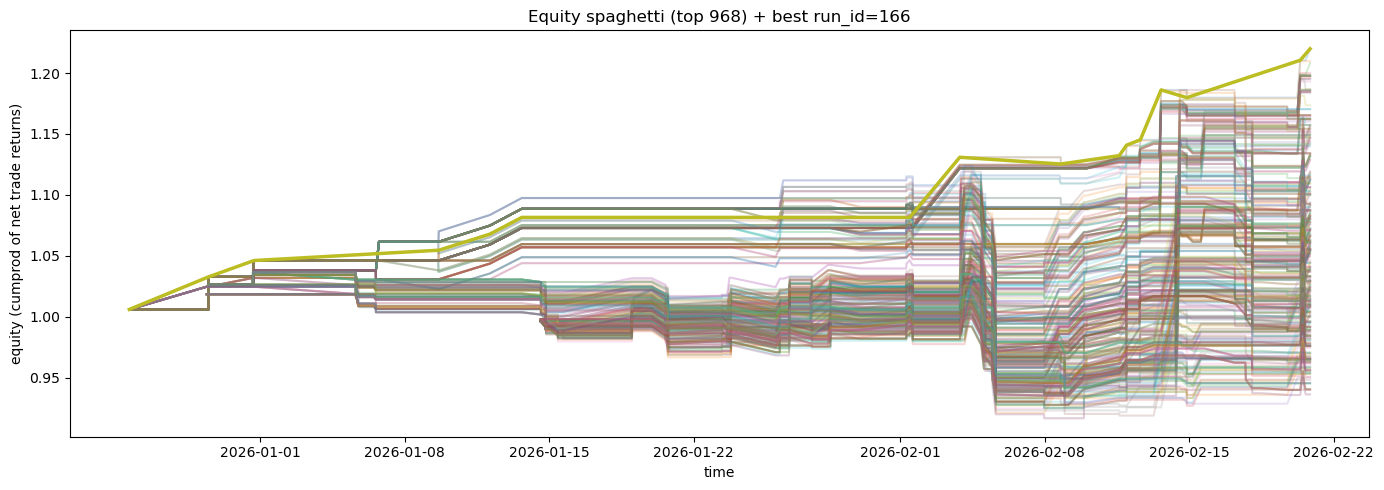

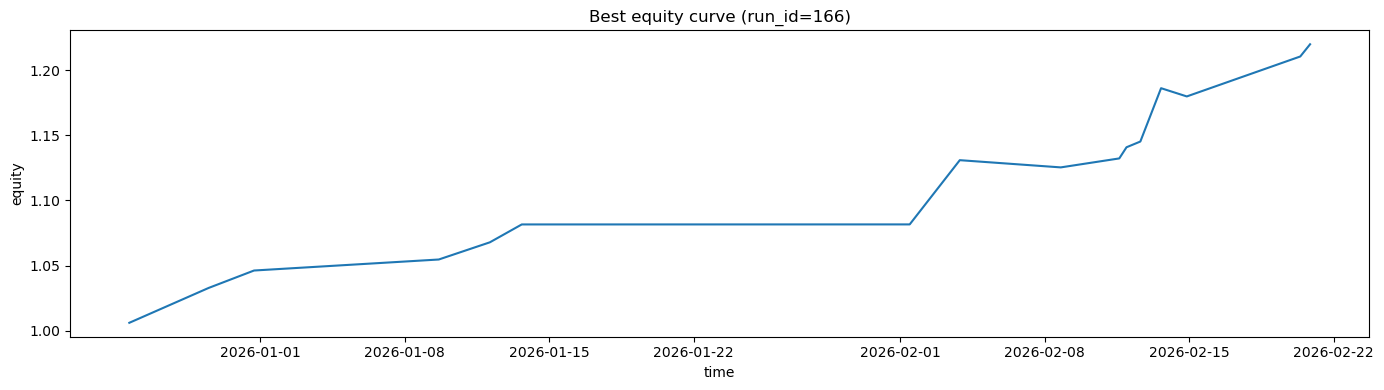

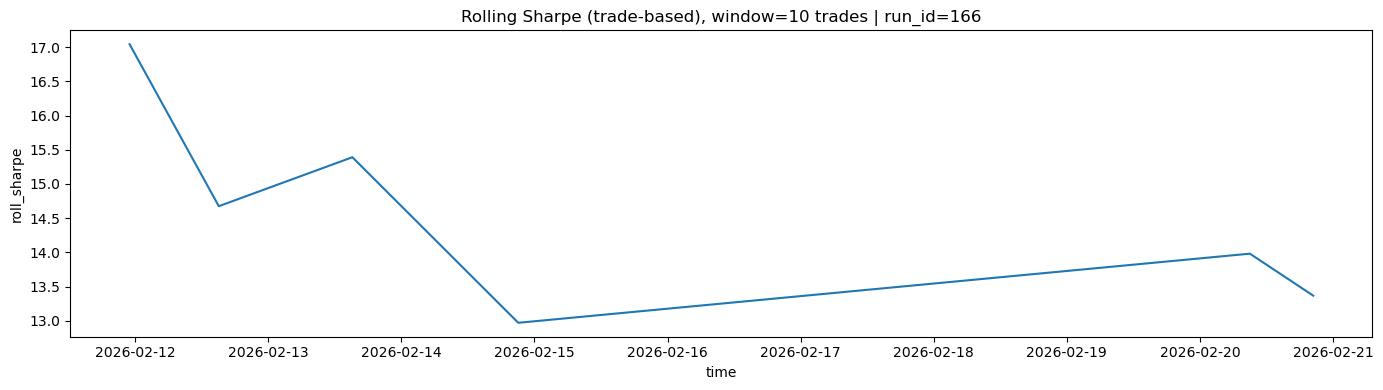

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 0) выбери run_id лучшего ---
best_id = int(TOP10_STAGE2.loc[0, "run_id"]) if "TOP10_STAGE2" in globals() else int(OK2.sort_values("total_return", ascending=False).iloc[0]["run_id"])
print("[plots] best run_id:", best_id)

# --- 1) достаём equity series ПРАВИЛЬНО ---
best_equity = STAGE2["series"].get(best_id, None)

if not isinstance(best_equity, pd.Series) or len(best_equity) == 0:
    raise ValueError("У best_id нет equity series в STAGE2['series'] (пусто или None).")

# индекс в datetime
best_equity = best_equity.copy()
best_equity.index = pd.to_datetime(best_equity.index, errors="coerce")
best_equity = best_equity[best_equity.index.notna()].sort_index()

# --- 2) строим 'спагетти' по equity для топ-N прогонов ---
TOP_N = 968
ok_df = OK2.sort_values("total_return", ascending=False).head(TOP_N).copy()
run_ids = ok_df["run_id"].astype(int).tolist()

eq_list = []
for rid in run_ids:
    s = STAGE2["series"].get(rid, None)
    if isinstance(s, pd.Series) and len(s) > 0:
        s = s.copy()
        s.index = pd.to_datetime(s.index, errors="coerce")
        s = s[s.index.notna()].sort_index()
        if len(s) > 1:
            eq_list.append(s.rename(str(rid)))

if len(eq_list) == 0:
    raise ValueError("Нет ни одной непустой equity series для спагетти.")

equity_mat = pd.concat(eq_list, axis=1).sort_index()
equity_mat = equity_mat.ffill()  # чтобы линии тянулись

# --- 3) Plot: Spaghetti equity ---
plt.figure(figsize=(14, 5))
plt.plot(equity_mat.index, equity_mat.values, alpha=0.20)
plt.plot(best_equity.index, best_equity.values, linewidth=2.5)  # best жирнее
plt.title(f"Equity spaghetti (top {TOP_N}) + best run_id={best_id}")
plt.xlabel("time")
plt.ylabel("equity (cumprod of net trade returns)")
plt.tight_layout()
plt.show()

# --- 4) Plot: Best equity only ---
plt.figure(figsize=(14, 4))
plt.plot(best_equity.index, best_equity.values)
plt.title(f"Best equity curve (run_id={best_id})")
plt.xlabel("time")
plt.ylabel("equity")
plt.tight_layout()
plt.show()

# --- 5) Rolling Sharpe (по сделкам) для best ---
# (т.к. у тебя equity по сделкам, sharpe тоже по сделкам)
r = best_equity.pct_change().dropna()
if len(r) >= 10:
    W = min(30, max(10, len(r)//5))  # окно 10..30
    roll_sh = (r.rolling(W).mean() / (r.rolling(W).std(ddof=1) + 1e-12)) * np.sqrt(365.0)
    plt.figure(figsize=(14, 4))
    plt.plot(roll_sh.index, roll_sh.values)
    plt.title(f"Rolling Sharpe (trade-based), window={W} trades | run_id={best_id}")
    plt.xlabel("time")
    plt.ylabel("roll_sharpe")
    plt.tight_layout()
    plt.show()
else:
    print("[plots] слишком мало сделок для rolling sharpe:", len(r))

In [190]:
# ===================== STATS CELL: TOP TABLE + BEST PARAMS + PRUNED SPACE SUMMARY =====================
import numpy as np
import pandas as pd

RANK_BY_STATS = RANK_BY if "RANK_BY" in globals() else "total_return"
TOPK = 20

# --- Stage2 summary ok ---
df2 = STAGE2_SUMMARY.copy() if "STAGE2_SUMMARY" in globals() else pd.DataFrame(STAGE2["summary"])
if "error" in df2.columns:
    df2_ok = df2[df2["error"].isna()].copy()
else:
    df2_ok = df2.copy()

if len(df2_ok) == 0:
    raise ValueError("Нет ok прогонов в Stage2.")

df2_ok = df2_ok.sort_values(RANK_BY_STATS, ascending=False).reset_index(drop=True)

# --- Top-K table ---
cols_main = ["run_id","total_return","sharpe","max_dd","n_trades","win_rate"]
param_cols = [c for c in df2_ok.columns if c not in cols_main and c not in ["error"]]
# (упорядочим параметры красиво)
preferred_order = ["tfFast","tfSlow","lenFast","lenSlow","atrLen","minDistATR","trailATR_CT",
                   "zDepthATR","zExtend","pivotL1","pivotR1","denMetricSrc","qLen","qPct","denDepthATR","denExtend"]
param_cols = [c for c in preferred_order if c in param_cols] + [c for c in param_cols if c not in preferred_order]

print(f"[stats] Stage2 OK runs: {len(df2_ok)} | ranking by: {RANK_BY_STATS}")
display(df2_ok[cols_main + param_cols].head(TOPK))

# --- Best params (final) ---
best_id = int(df2_ok.loc[0, "run_id"])
best_row = df2_ok.iloc[0].to_dict()

print("\n[BEST FINAL] run_id:", best_id)
print("[BEST FINAL] metrics:",
      {k: best_row[k] for k in cols_main if k in best_row})

if "STAGE2" in globals() and "params" in STAGE2 and best_id in STAGE2["params"]:
    print("\n[BEST FINAL] params:")
    for k, v in STAGE2["params"][best_id].items():
        print(f"  {k}: {v}")
else:
    # fallback: из строки таблицы
    print("\n[BEST FINAL] params (from table row):")
    for k in param_cols:
        print(f"  {k}: {best_row.get(k)}")

# --- What got pruned (space sizes + values) ---
if "PRUNED_SPACE" in globals():
    print("\n[PRUNED SPACE] sizes:")
    for k, spec in PRUNED_SPACE.items():
        if spec.get("type") == "cat":
            print(f"  {k:12s}: {len(spec['values'])} values -> {spec['values']}")
        else:
            print(f"  {k:12s}: {spec}")

# --- Optional: show top values per parameter from PRUNE_STATS ---
if "PRUNE_STATS" in globals() and isinstance(PRUNE_STATS, pd.DataFrame) and len(PRUNE_STATS) > 0:
    print("\n[PRUNE_STATS] best values per param (top 3 by median):")
    tmp = PRUNE_STATS.copy()
    # standardize colnames from prune builder: param/value/median/count
    need = {"param","value","median","count"}
    if need.issubset(set(tmp.columns)):
        out = (tmp.sort_values(["param","median"], ascending=[True, False])
                 .groupby("param")
                 .head(3)
                 .reset_index(drop=True))
        display(out)

[stats] Stage2 OK runs: 468 | ranking by: total_return


,run_id,total_return,sharpe,max_dd,n_trades,win_rate,tfFast,tfSlow,lenFast,lenSlow,atrLen,minDistATR,trailATR_CT,minStopPts,minPotMult
0,166,0.219852,16.969876,-0.005329,16,0.875000,5m,360m,55,110,50,10.0,5.0,900,3.0
1,133,0.209722,16.789604,-0.005329,15,0.866667,5m,360m,55,110,20,10.0,5.0,900,3.0
2,112,0.208124,20.153890,-0.005329,15,0.866667,5m,360m,60,110,50,10.0,5.0,900,3.0
3,254,0.199836,21.503236,-0.003898,11,0.909091,5m,360m,55,110,50,11.5,6.5,800,3.0
4,115,0.198092,19.955517,-0.005329,14,0.857143,5m,360m,60,110,20,10.0,5.0,900,3.0
5,60,0.197967,19.254188,-0.006987,12,0.833333,5m,360m,55,110,50,12.0,5.0,800,3.0
6,365,0.197967,19.254188,-0.006987,12,0.833333,5m,360m,55,110,50,12.0,5.0,800,2.5
7,86,0.197967,19.254188,-0.006987,12,0.833333,5m,360m,55,110,50,11.5,5.0,800,3.0
8,339,0.197967,19.254188,-0.006987,12,0.833333,5m,360m,55,110,50,11.5,5.0,800,2.5
9,145,0.197824,15.241020,-0.008861,15,0.800000,5m,360m,55,110,20,10.0,5.0,800,3.0



[BEST FINAL] run_id: 166
[BEST FINAL] metrics: {'run_id': 166, 'total_return': 0.2198523635345444, 'sharpe': 16.969876040148925, 'max_dd': -0.005329323627556559, 'n_trades': 16, 'win_rate': 0.875}

[BEST FINAL] params:
  tfFast: 5m
  tfSlow: 360m
  lenFast: 55
  lenSlow: 110
  atrLen: 50
  minDistATR: 10.0
  trailATR_CT: 5.0
  minStopPts: 900
  minPotMult: 3.0

[PRUNED SPACE] sizes:
  tfFast      : 1 values -> [np.str_('5m')]
  tfSlow      : 2 values -> [np.str_('360m'), '180m']
  lenFast     : 2 values -> [np.int64(55), np.int64(60)]
  lenSlow     : 3 values -> [np.int64(20), np.int64(90), np.int64(110)]
  atrLen      : 2 values -> [np.int64(50), np.int64(20)]
  minDistATR  : 5 values -> [np.float64(12.0), np.float64(10.0), np.float64(13.5), np.float64(11.5), np.float64(14.0)]
  trailATR_CT : 4 values -> [np.float64(6.5), np.float64(6.0), np.float64(5.0), np.float64(7.0)]
  minStopPts  : 3 values -> [np.int64(900), np.int64(700), np.int64(800)]
  minPotMult  : 3 values -> [np.float64

,value,count,median,mean,param
0,50,245,-0.045501,-0.041292,atrLen
1,20,255,-0.052610,-0.046217,atrLen
2,50,3,0.029758,0.012847,lenFast
3,55,10,0.027962,0.032085,lenFast
4,60,8,-0.003720,0.002392,lenFast
5,80,7,-0.039471,-0.039326,lenSlow
6,20,10,-0.040123,-0.046873,lenSlow
7,90,9,-0.042001,-0.040465,lenSlow
8,12.0,10,-0.035415,-0.028958,minDistATR
9,10.0,21,-0.043003,-0.040830,minDistATR


In [191]:
# ===================== WEEKLY BEST PARAMS (ROBUST): equity from series/bt OR rebuilt from trades =====================
import numpy as np
import pandas as pd

# ---------- SETTINGS ----------
STAGE_OBJ_NAME = "STAGE1"      # <-- поставь "STAGE2", если хочешь stage2
WEEK_ANCHOR = "W-FRI"          # "W-WED" если у тебя неделя якорится на среду
EQUITY_COL_CANDIDATES = ["equity", "equity_curve", "equity_total", "equity_net", "Equity"]
TS_COL_CANDIDATES     = ["ts", "time", "datetime", "date", "timestamp"]
CLOSE_COL_CANDIDATES  = ["close", "Close", "price", "px"]

# Для реконструкции из сделок:
START_EQUITY = 1.0             # базовая шкала (можно 10000, неважно — нужны проценты)
ASSUME_QTY_1 = True            # если qty нет — считаем qty=1

# ---------- GET STAGE ----------
if STAGE_OBJ_NAME not in globals():
    raise ValueError(f"Нет {STAGE_OBJ_NAME} в памяти.")
STAGE = globals()[STAGE_OBJ_NAME]
if not isinstance(STAGE, dict) or "params" not in STAGE:
    raise ValueError(f"{STAGE_OBJ_NAME} не похож на dict с ключом 'params'.")

# ---------- small debug: show structure for one ok run ----------
def _first_existing_run_id():
    keys = list(STAGE.get("params", {}).keys())
    return int(keys[0]) if len(keys) else None

def _describe_obj(obj, name="obj", max_cols=25):
    print(f"\n--- {name} ---")
    if obj is None:
        print("None")
        return
    print("type:", type(obj))
    if isinstance(obj, dict):
        print("dict keys:", list(obj.keys())[:40], ("..." if len(obj)>40 else ""))
    if isinstance(obj, pd.DataFrame):
        print("DataFrame shape:", obj.shape)
        print("columns:", list(obj.columns)[:max_cols], ("..." if obj.shape[1]>max_cols else ""))
        print("index type:", type(obj.index), "| tz:", getattr(obj.index, "tz", None))
        print(obj.head(3))
    if isinstance(obj, pd.Series):
        print("Series len:", len(obj), "| index type:", type(obj.index), "| tz:", getattr(obj.index, "tz", None))
        print(obj.head(3))
    if isinstance(obj, (list, tuple)):
        print("list/tuple len:", len(obj))
        if len(obj):
            print("first element type:", type(obj[0]))
            print("first element:", obj[0])

rid0 = _first_existing_run_id()
if rid0 is not None:
    _describe_obj(STAGE.get("series", {}).get(rid0, None), f"{STAGE_OBJ_NAME}['series'][{rid0}]")
    _describe_obj(STAGE.get("bt", {}).get(rid0, None),     f"{STAGE_OBJ_NAME}['bt'][{rid0}]")
    _describe_obj(STAGE.get("trades", {}).get(rid0, None), f"{STAGE_OBJ_NAME}['trades'][{rid0}]")

# ---------- helpers ----------
def _ensure_dt_index_from_df(df: pd.DataFrame):
    """Если индекс не DatetimeIndex — попробуем найти колонку времени и сделать её индексом."""
    if isinstance(df.index, pd.DatetimeIndex):
        return df
    for c in TS_COL_CANDIDATES:
        if c in df.columns:
            tmp = df.copy()
            tmp[c] = pd.to_datetime(tmp[c], errors="coerce", utc=True)
            tmp = tmp.dropna(subset=[c]).set_index(c)
            return tmp
    return df  # как есть

def _pick_equity_from_series_or_bt(run_id: int):
    """
    Вернёт pd.Series equity с DatetimeIndex или None.
    Пытаемся:
      - STAGE['series'][run_id] (DataFrame/Series/dict)
      - STAGE['bt'][run_id] (DataFrame/dict)
    """
    # ---- series ----
    if "series" in STAGE and run_id in STAGE["series"]:
        s = STAGE["series"][run_id]
        # DataFrame
        if isinstance(s, pd.DataFrame):
            s = _ensure_dt_index_from_df(s)
            if isinstance(s.index, pd.DatetimeIndex):
                for c in EQUITY_COL_CANDIDATES:
                    if c in s.columns:
                        eq = s[c].dropna()
                        if len(eq) > 5:
                            return eq
                # fallback: close
                for c in CLOSE_COL_CANDIDATES:
                    if c in s.columns:
                        px = s[c].dropna()
                        if len(px) > 5:
                            return px
        # Series
        if isinstance(s, pd.Series) and isinstance(s.index, pd.DatetimeIndex) and len(s) > 5:
            return s.dropna()
        # dict container
        if isinstance(s, dict):
            # если внутри лежит DataFrame/Series
            for key in EQUITY_COL_CANDIDATES + ["df", "data", "series"]:
                if key in s:
                    obj = s[key]
                    if isinstance(obj, pd.Series) and isinstance(obj.index, pd.DatetimeIndex) and len(obj) > 5:
                        return obj.dropna()
                    if isinstance(obj, pd.DataFrame):
                        obj = _ensure_dt_index_from_df(obj)
                        if isinstance(obj.index, pd.DatetimeIndex):
                            for c in EQUITY_COL_CANDIDATES:
                                if c in obj.columns:
                                    eq = obj[c].dropna()
                                    if len(eq) > 5:
                                        return eq

    # ---- bt ----
    if "bt" in STAGE and run_id in STAGE["bt"]:
        bt = STAGE["bt"][run_id]
        if isinstance(bt, pd.DataFrame):
            bt = _ensure_dt_index_from_df(bt)
            if isinstance(bt.index, pd.DatetimeIndex):
                for c in EQUITY_COL_CANDIDATES:
                    if c in bt.columns:
                        eq = bt[c].dropna()
                        if len(eq) > 5:
                            return eq
        if isinstance(bt, dict):
            for k in EQUITY_COL_CANDIDATES:
                if k in bt:
                    obj = bt[k]
                    if isinstance(obj, pd.Series) and isinstance(obj.index, pd.DatetimeIndex) and len(obj) > 5:
                        return obj.dropna()
                    if isinstance(obj, pd.DataFrame):
                        obj = _ensure_dt_index_from_df(obj)
                        if isinstance(obj.index, pd.DatetimeIndex) and obj.shape[1] == 1:
                            return obj.iloc[:, 0].dropna()

    return None

def _trades_to_equity_series(trades_obj, start_equity=1.0):
    """
    Реконструируем equity из trades.
    Поддерживаем:
      - DataFrame со столбцами entry_ts/exit_ts/entry_px/exit_px/side/(qty)
      - list[dict] с теми же ключами
      - list объектов с атрибутами entry_ts/exit_ts/entry_px/exit_px/side/(qty)
    Возвращаем pd.Series equity с индексом по exit_ts (UTC).
    """
    if trades_obj is None:
        return None

    # привести к DataFrame
    if isinstance(trades_obj, pd.DataFrame):
        tdf = trades_obj.copy()
    elif isinstance(trades_obj, (list, tuple)):
        if len(trades_obj) == 0:
            return None
        first = trades_obj[0]
        if isinstance(first, dict):
            tdf = pd.DataFrame(list(trades_obj))
        else:
            # объект с атрибутами
            rows = []
            for tr in trades_obj:
                rows.append({
                    "entry_ts": getattr(tr, "entry_ts", None),
                    "exit_ts":  getattr(tr, "exit_ts", None),
                    "entry_px": getattr(tr, "entry_px", None),
                    "exit_px":  getattr(tr, "exit_px", None),
                    "side":     getattr(tr, "side", None),
                    "qty":      getattr(tr, "qty", None),
                })
            tdf = pd.DataFrame(rows)
    elif isinstance(trades_obj, dict):
        # вдруг trades хранится как {"trades": [...]}
        if "trades" in trades_obj:
            return _trades_to_equity_series(trades_obj["trades"], start_equity=start_equity)
        return None
    else:
        return None

    # нормализуем имена
    # (если у тебя другие имена — можно расширить сюда)
    for col in ["entry_ts", "exit_ts"]:
        if col not in tdf.columns:
            # попробуем популярные альтернативы
            alts = {
                "entry_ts": ["entry_time", "open_time", "entry_dt"],
                "exit_ts":  ["exit_time", "close_time", "exit_dt"]
            }
            for a in alts[col]:
                if a in tdf.columns:
                    tdf[col] = tdf[a]
                    break

    for col in ["entry_px", "exit_px"]:
        if col not in tdf.columns:
            alts = {
                "entry_px": ["entry_price", "open_px", "price_in"],
                "exit_px":  ["exit_price", "close_px", "price_out"]
            }
            for a in alts[col]:
                if a in tdf.columns:
                    tdf[col] = tdf[a]
                    break

    if "side" not in tdf.columns:
        # иногда side как +1/-1
        if "dir" in tdf.columns:
            tdf["side"] = tdf["dir"]
        elif "position" in tdf.columns:
            tdf["side"] = tdf["position"]

    # parse time
    tdf["exit_ts"] = pd.to_datetime(tdf["exit_ts"], errors="coerce", utc=True)
    tdf = tdf.dropna(subset=["exit_ts", "entry_px", "exit_px", "side"]).copy()
    if len(tdf) == 0:
        return None

    # qty
    if "qty" not in tdf.columns or tdf["qty"].isna().all():
        tdf["qty"] = 1.0 if ASSUME_QTY_1 else np.nan
    tdf["qty"] = pd.to_numeric(tdf["qty"], errors="coerce").fillna(1.0)

    # side normalize
    def _side_sign(x):
        if isinstance(x, str):
            xx = x.lower()
            if "long" in xx:
                return 1.0
            if "short" in xx:
                return -1.0
        try:
            v = float(x)
            return 1.0 if v > 0 else (-1.0 if v < 0 else 0.0)
        except Exception:
            return 0.0

    side_sign = tdf["side"].map(_side_sign).astype(float)
    tdf = tdf[side_sign != 0].copy()
    side_sign = side_sign.loc[tdf.index]

    # trade return (процент) на единицу капитала (условно)
    entry = pd.to_numeric(tdf["entry_px"], errors="coerce")
    exitp = pd.to_numeric(tdf["exit_px"], errors="coerce")
    tdf = tdf.dropna(subset=[entry.name, exitp.name]).copy()
    entry = entry.loc[tdf.index]
    exitp = exitp.loc[tdf.index]
    side_sign = side_sign.loc[tdf.index]

    # r = side * (exit/entry - 1)
    r = side_sign * (exitp / entry - 1.0)
    r = r.replace([np.inf, -np.inf], np.nan).dropna()

    if len(r) == 0:
        return None

    # агрегируем по exit_ts (если несколько сделок закрылись в один момент)
    tdf2 = pd.DataFrame({"exit_ts": tdf.loc[r.index, "exit_ts"].values, "r": r.values})
    tdf2 = tdf2.dropna(subset=["exit_ts"]).copy()
    tdf2 = tdf2.sort_values("exit_ts")
    r_by_ts = tdf2.groupby("exit_ts")["r"].sum()  # суммируем эффекты сделок в один ts

    equity = (1.0 + r_by_ts).cumprod() * float(start_equity)
    equity.name = "equity"
    return equity

def _to_weekly_returns(eq: pd.Series) -> pd.Series:
    eq = eq.sort_index()
    eq = eq[~eq.index.duplicated(keep="last")]
    w = eq.resample(WEEK_ANCHOR).last().dropna()
    r = w.pct_change().dropna()
    r.name = "weekly_return"
    return r

# ---------- build weekly returns per run ----------
run_ids = sorted(list(STAGE["params"].keys()))
weekly_by_run = {}
bad_runs = []
src_used = {"series/bt": 0, "trades": 0}

for rid in run_ids:
    eq = _pick_equity_from_series_or_bt(rid)

    if eq is not None and isinstance(eq.index, pd.DatetimeIndex) and len(eq) > 5:
        src_used["series/bt"] += 1
    else:
        # fallback: rebuild from trades
        trades_obj = STAGE.get("trades", {}).get(rid, None)
        eq = _trades_to_equity_series(trades_obj, start_equity=START_EQUITY)
        if eq is not None and isinstance(eq.index, pd.DatetimeIndex) and len(eq) > 2:
            src_used["trades"] += 1

    if eq is None or not isinstance(eq.index, pd.DatetimeIndex) or len(eq) < 5:
        bad_runs.append(rid)
        continue

    try:
        wr = _to_weekly_returns(eq)
        if len(wr) >= 3:
            weekly_by_run[rid] = wr
        else:
            bad_runs.append(rid)
    except Exception:
        bad_runs.append(rid)

if len(weekly_by_run) == 0:
    print("src_used:", src_used)
    raise ValueError(
        "Не получилось построить weekly returns ни для одного run_id.\n"
        "Значит equity не хранится, и trades тоже не содержат exit_ts/entry_px/exit_px/side.\n"
        "Смотри диагностический вывод выше — какие поля реально есть в trades."
    )

W = pd.concat(weekly_by_run, axis=1)  # index=week, columns=run_id
W.columns = [int(c) for c in W.columns]
print(f"[OK] weekly return matrix: {W.shape} | runs ok={W.shape[1]} | runs bad={len(bad_runs)} | src_used={src_used}")

# ---------- choose best run each week ----------
best_run_each_week = W.idxmax(axis=1).rename("best_run_id")
best_ret_each_week = W.max(axis=1).rename("best_weekly_return")
BEST_WEEK_TABLE = pd.concat([best_run_each_week, best_ret_each_week], axis=1)
display(BEST_WEEK_TABLE.tail(20))

# ---------- collect params of weekly winners ----------
param_keys = list(STAGE["params"][int(best_run_each_week.iloc[0])].keys())

rows = []
for week_ts, rid in best_run_each_week.items():
    p = STAGE["params"][int(rid)]
    row = {"week": week_ts, "best_run_id": int(rid)}
    for k in param_keys:
        row[k] = p.get(k, np.nan)
    rows.append(row)

WEEKLY_WINNER_PARAMS = pd.DataFrame(rows).set_index("week").sort_index()
display(WEEKLY_WINNER_PARAMS.head())

# ---------- requested table: param | week_1..week_N | mean_numeric ----------
weeks = list(WEEKLY_WINNER_PARAMS.index)
week_cols = [f"week_{i+1}" for i in range(len(weeks))]

# rows=params, cols=weeks
PARAM_WEEK_MATRIX = pd.DataFrame(
    {week_cols[i]: WEEKLY_WINNER_PARAMS.iloc[i][param_keys].to_dict() for i in range(len(weeks))}
).T
PARAM_WEEK_MATRIX.index = weeks
PARAM_WEEK_MATRIX = PARAM_WEEK_MATRIX.T

# mean numeric
means = []
for k in PARAM_WEEK_MATRIX.index:
    s = PARAM_WEEK_MATRIX.loc[k]
    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().sum() >= max(3, int(0.3*len(s_num))):
        means.append(float(s_num.mean()))
    else:
        means.append(np.nan)

PARAM_WEEK_MATRIX["mean_numeric"] = means
display(PARAM_WEEK_MATRIX)

# ---------- extra: stats per param (mode for categorical, mean/sd for numeric) ----------
freq_rows = []
for k in param_keys:
    s = WEEKLY_WINNER_PARAMS[k]
    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().sum() >= max(3, int(0.3*len(s_num))):
        freq_rows.append({
            "param": k, "type": "numeric",
            "mean": float(s_num.mean()),
            "median": float(s_num.median()),
            "sd": float(s_num.std(ddof=1)) if s_num.notna().sum() > 1 else 0.0,
            "min": float(s_num.min()),
            "max": float(s_num.max()),
            "mode": np.nan, "mode_count": np.nan,
            "n_weeks": int(s_num.notna().sum())
        })
    else:
        vc = s.astype(str).value_counts(dropna=True)
        mode = vc.index[0] if len(vc) else np.nan
        mode_count = int(vc.iloc[0]) if len(vc) else 0
        freq_rows.append({
            "param": k, "type": "categorical",
            "mean": np.nan, "median": np.nan, "sd": np.nan, "min": np.nan, "max": np.nan,
            "mode": mode, "mode_count": mode_count,
            "n_weeks": int(s.notna().sum())
        })

PARAM_STABILITY_STATS = pd.DataFrame(freq_rows).sort_values(["type","param"]).reset_index(drop=True)
display(PARAM_STABILITY_STATS)

# ---------- how often each run wins ----------
WIN_COUNTS = best_run_each_week.value_counts().rename_axis("run_id").to_frame("n_weeks_won").sort_values("n_weeks_won", ascending=False)
display(WIN_COUNTS.head(30))

print("\n[Saved] BEST_WEEK_TABLE, WEEKLY_WINNER_PARAMS, PARAM_WEEK_MATRIX, PARAM_STABILITY_STATS, WIN_COUNTS")


--- STAGE1['series'][0] ---
type: <class 'pandas.core.series.Series'>
Series len: 41 | index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> | tz: UTC
exit_ts
2026-01-09 15:30:00+00:00    1.012820
2026-01-14 14:15:00+00:00    1.007816
2026-01-14 19:20:00+00:00    1.004247
dtype: float64

--- STAGE1['bt'][0] ---
type: <class 'pandas.core.frame.DataFrame'>
DataFrame shape: (17237, 96)
columns: ['adj close_btc-usd', 'close', 'high', 'low', 'open', 'volume', 'hlc3', 'atr', 'trama_fast', 'trama_slow', 'vwap', 'emaf', 'emas', 'trendup', 'adx', 'trendconfirmlong', 'trendconfirmshort', 'delta', 'momlong', 'momshort', 'suptop', 'supbot', 'demtop', 'dembot', 'supactive'] ...
index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> | tz: UTC
                           adj close_btc-usd         close          high  \
Datetime                                                                   
2025-12-23 00:00:00+00:00       88525.179688  88525.179688  88530.726562   
2025-12-2

,best_run_id,best_weekly_return
exit_ts,,
2026-01-02 00:00:00+00:00,15,0.039482
2026-01-09 00:00:00+00:00,322,0.058588
2026-01-16 00:00:00+00:00,31,0.022732
2026-01-23 00:00:00+00:00,363,0.043454
2026-01-30 00:00:00+00:00,164,0.022067
2026-02-06 00:00:00+00:00,301,-0.015537
2026-02-13 00:00:00+00:00,27,0.106199
2026-02-20 00:00:00+00:00,341,0.083305


,best_run_id,tfFast,tfSlow,lenFast,lenSlow,atrLen,minDistATR,trailATR_CT,minStopPts,minPotMult
week,,,,,,,,,,
2026-01-02 00:00:00+00:00,15,5m,360m,35,70,20,13.0,5.0,600,3.5
2026-01-09 00:00:00+00:00,322,5m,360m,15,70,50,11.5,3.0,800,3.5
2026-01-16 00:00:00+00:00,31,5m,360m,35,80,50,11.5,7.0,600,3.5
2026-01-23 00:00:00+00:00,363,5m,180m,35,70,50,13.5,5.0,700,3.5
2026-01-30 00:00:00+00:00,164,5m,180m,55,70,50,14.0,4.0,300,3.0


,2026-01-02 00:00:00+00:00,2026-01-09 00:00:00+00:00,2026-01-16 00:00:00+00:00,2026-01-23 00:00:00+00:00,2026-01-30 00:00:00+00:00,2026-02-06 00:00:00+00:00,2026-02-13 00:00:00+00:00,2026-02-20 00:00:00+00:00,mean_numeric
tfFast,5m,5m,5m,5m,5m,5m,5m,5m,NaN
tfSlow,360m,360m,360m,180m,180m,360m,180m,180m,NaN
lenFast,35,15,35,35,55,35,55,35,37.5000
lenSlow,70,70,80,70,70,100,70,40,71.2500
atrLen,20,50,50,50,50,20,50,50,42.5000
minDistATR,13.0,11.5,11.5,13.5,14.0,11.5,11.5,11.5,12.2500
trailATR_CT,5.0,3.0,7.0,5.0,4.0,5.0,5.0,4.5,4.8125
minStopPts,600,800,600,700,300,400,800,900,637.5000
minPotMult,3.5,3.5,3.5,3.5,3.0,2.0,3.5,3.5,3.2500


,param,type,mean,median,sd,min,max,mode,mode_count,n_weeks
0,tfFast,categorical,NaN,NaN,NaN,NaN,NaN,5m,8.0,8
1,tfSlow,categorical,NaN,NaN,NaN,NaN,NaN,360m,4.0,8
2,atrLen,numeric,42.5000,50.0,13.887301,20.0,50.0,NaN,NaN,8
3,lenFast,numeric,37.5000,35.0,12.817399,15.0,55.0,NaN,NaN,8
4,lenSlow,numeric,71.2500,70.0,16.420806,40.0,100.0,NaN,NaN,8
5,minDistATR,numeric,12.2500,11.5,1.069045,11.5,14.0,NaN,NaN,8
6,minPotMult,numeric,3.2500,3.5,0.534522,2.0,3.5,NaN,NaN,8
7,minStopPts,numeric,637.5000,650.0,206.587927,300.0,900.0,NaN,NaN,8
8,trailATR_CT,numeric,4.8125,5.0,1.131923,3.0,7.0,NaN,NaN,8


,n_weeks_won
run_id,
15,1
322,1
31,1
363,1
164,1
301,1
27,1
341,1



[Saved] BEST_WEEK_TABLE, WEEKLY_WINNER_PARAMS, PARAM_WEEK_MATRIX, PARAM_STABILITY_STATS, WIN_COUNTS


Количество прогонов: 468


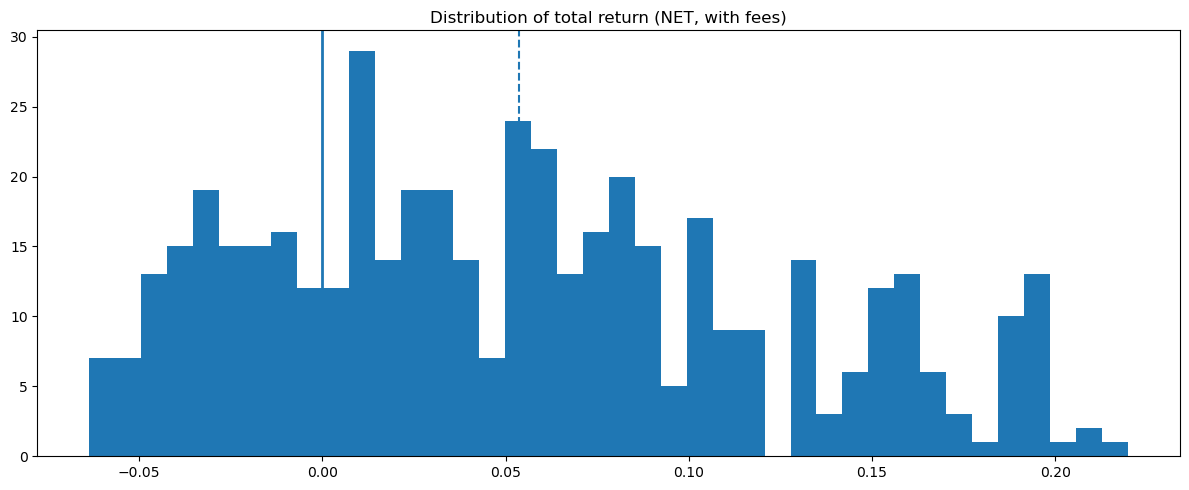

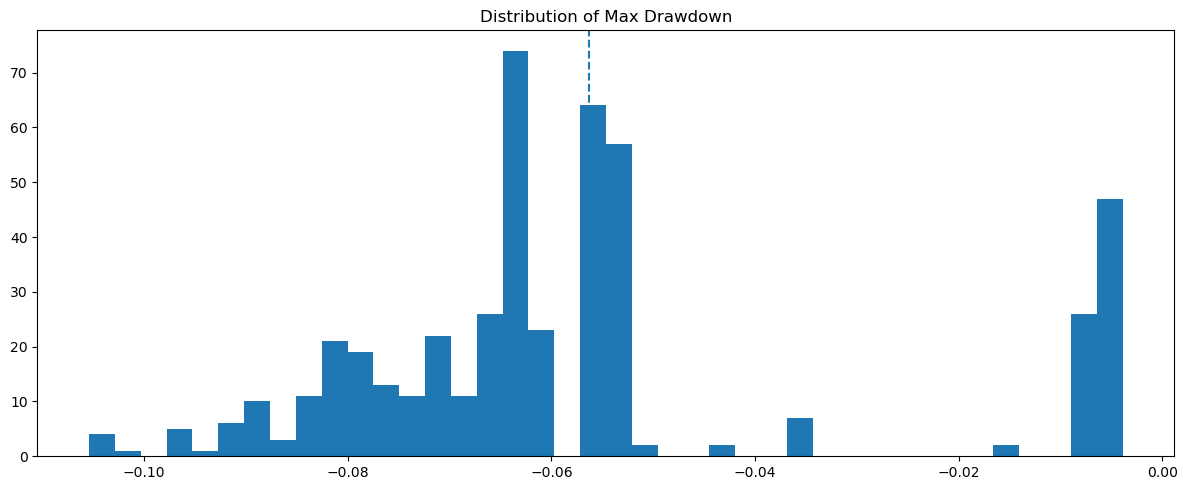


==== 95% Confidence Interval for Mean Return ====
Mean return: 0.05352386700256288
CI: (np.float64(0.047257501579810665), np.float64(0.0597902324253151))

==== Hypothesis Test (H0: mean <= 0) ====
t-stat: 16.784440367190463
p-value (one-sided): 0.0
Reject H0 at 95% level: mean return significantly > 0


In [192]:
# ===================== STAGE2 DISTRIBUTION + 95% CI TEST =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

if "OK2" not in globals() or len(OK2) == 0:
    raise ValueError("OK2 пустой — сначала запусти Stage2.")

df = OK2.copy()

if "total_return" not in df.columns:
    raise ValueError("В OK2 нет total_return (должен считаться с комиссией).")

# --- берём только валидные ---
rets = df["total_return"].dropna()
mdds = df["max_dd"].dropna()

print("Количество прогонов:", len(rets))

# ===================== ГРАФИК 1: распределение прибыли =====================
plt.figure(figsize=(12,5))
plt.hist(rets, bins=40)
plt.axvline(rets.mean(), linestyle="--")
plt.axvline(0, linewidth=2)
plt.title("Distribution of total return (NET, with fees)")
plt.tight_layout()
plt.show()

# ===================== ГРАФИК 2: распределение Max DD =====================
plt.figure(figsize=(12,5))
plt.hist(mdds, bins=40)
plt.axvline(mdds.mean(), linestyle="--")
plt.title("Distribution of Max Drawdown")
plt.tight_layout()
plt.show()

# ===================== 95% CONFIDENCE INTERVAL =====================
n = len(rets)
mean_ret = rets.mean()
std_ret = rets.std(ddof=1)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
ci_low = mean_ret - t_crit * std_ret / np.sqrt(n)
ci_high = mean_ret + t_crit * std_ret / np.sqrt(n)

print("\n==== 95% Confidence Interval for Mean Return ====")
print("Mean return:", mean_ret)
print("CI:", (ci_low, ci_high))

# ===================== HYPOTHESIS TEST =====================
# H0: mean <= 0
# H1: mean > 0

t_stat = mean_ret / (std_ret / np.sqrt(n))
p_value = 1 - stats.t.cdf(t_stat, df=n-1)

print("\n==== Hypothesis Test (H0: mean <= 0) ====")
print("t-stat:", t_stat)
print("p-value (one-sided):", p_value)

if p_value < 0.05:
    print("Reject H0 at 95% level: mean return significantly > 0")
else:
    print("Cannot reject H0 at 95% level")

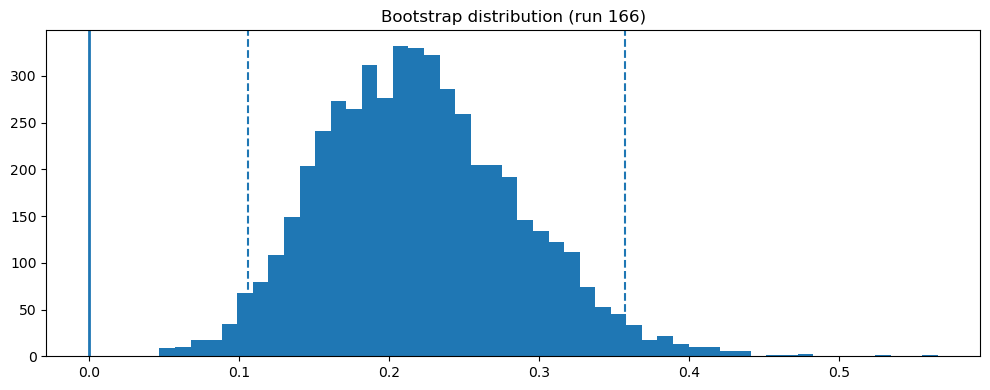

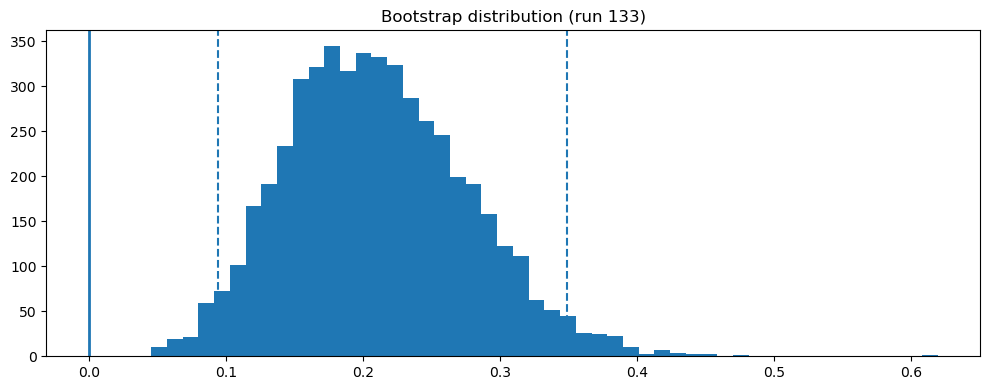

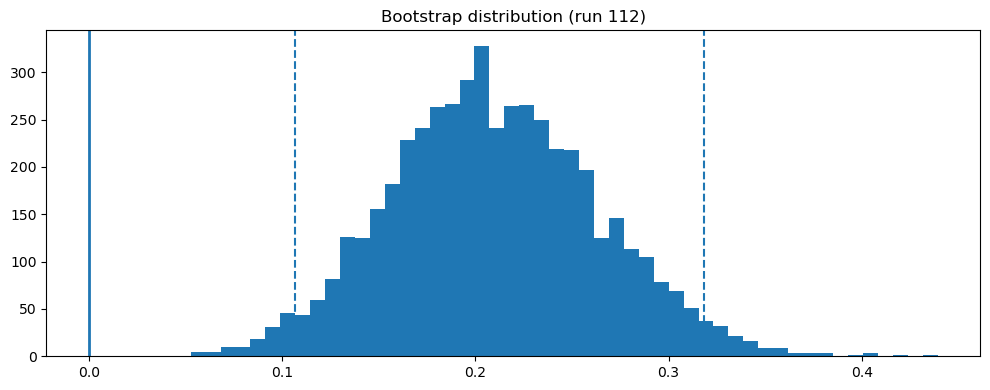

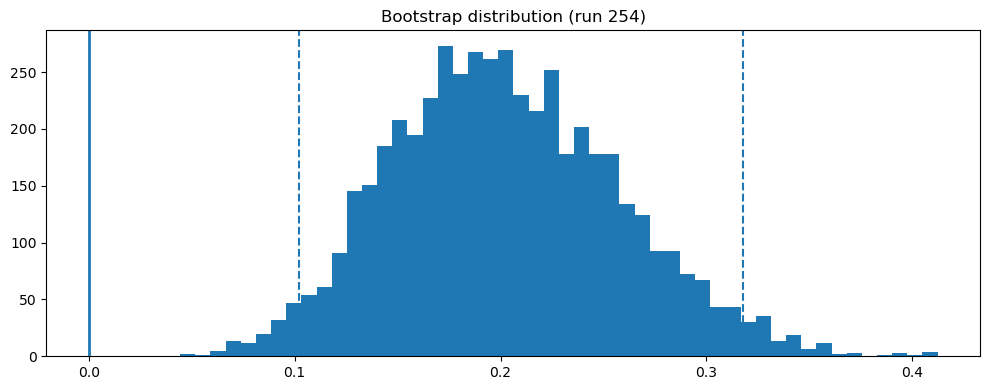

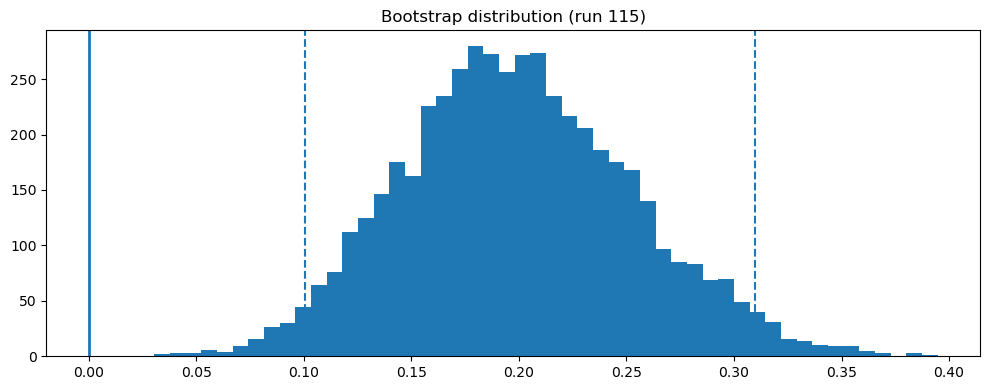

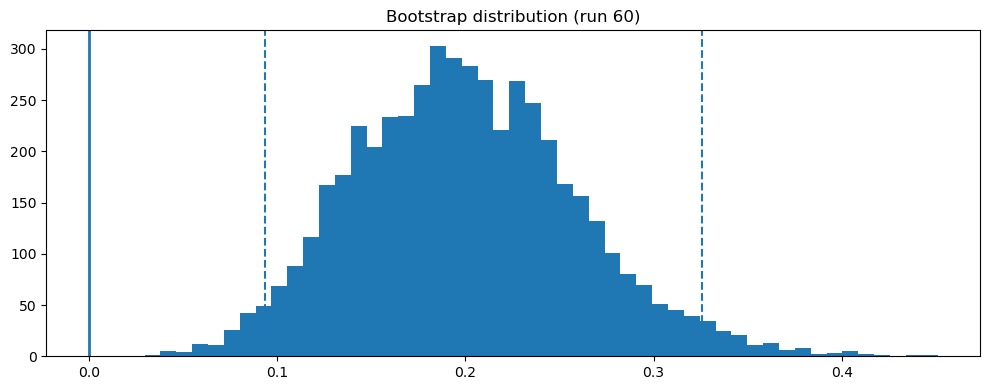

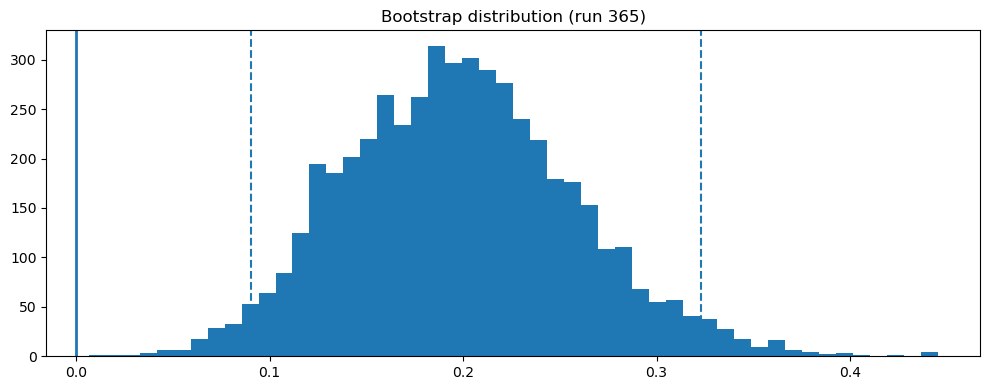

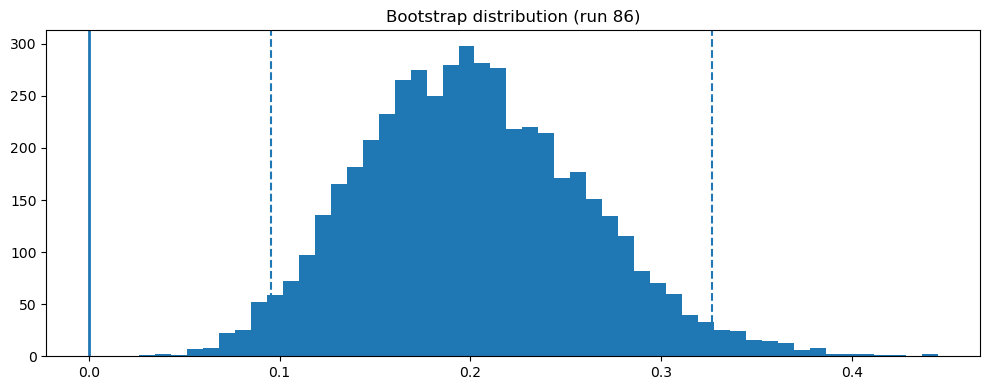

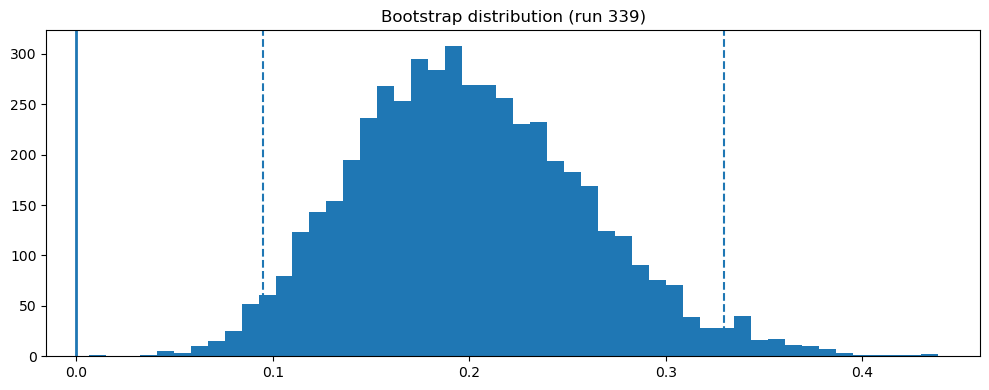

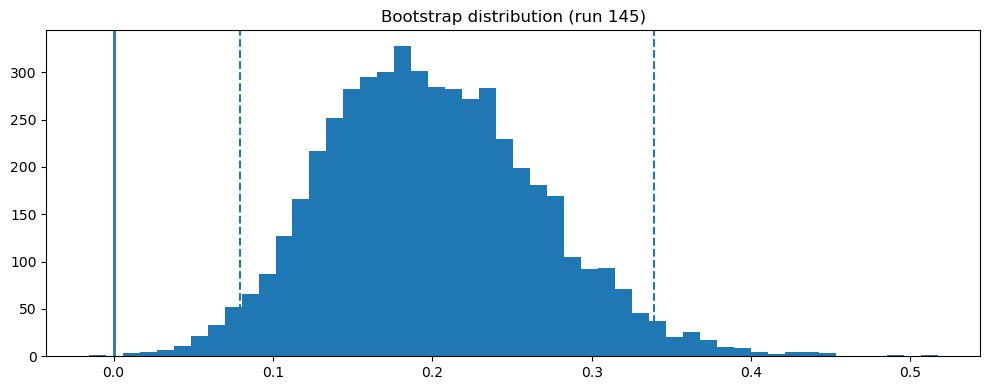

,run_id,orig_return,boot_mean,CI_low,CI_high,Prob_loss,n_trades
0,166,0.219852,0.220614,0.106224,0.357222,0.0000,16
1,133,0.209722,0.210485,0.094241,0.349000,0.0000,15
2,112,0.208124,0.209721,0.106842,0.318378,0.0000,15
3,254,0.199836,0.202310,0.102330,0.317603,0.0000,11
4,115,0.198092,0.199362,0.100664,0.309865,0.0000,14
5,60,0.197967,0.200016,0.093595,0.325553,0.0000,12
6,365,0.197967,0.198566,0.090271,0.322829,0.0000,12
7,86,0.197967,0.201369,0.095451,0.326751,0.0000,12
8,339,0.197967,0.200261,0.095180,0.329548,0.0000,12
9,145,0.197824,0.199986,0.079169,0.339250,0.0002,15


In [193]:
# ===================== BOOTSTRAP TEST FOR TOP PARAM SETS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "TOP10_STAGE2" not in globals():
    raise ValueError("Нет TOP10_STAGE2 — запусти Stage2.")

B = 5000
alpha = 0.05

results_boot = []

for i, row in TOP10_STAGE2.iterrows():
    run_id = int(row["run_id"])
    trades = STAGE2["trades"][run_id]

    if trades is None or len(trades) < 5:
        continue

    # net returns per trade (с комиссией)
    r = _trade_returns_with_fees(trades).dropna()
    if len(r) < 5:
        continue

    n = len(r)
    boot_total = []

    for _ in range(B):
        sample = np.random.choice(r.values, size=n, replace=True)
        eq = np.prod(1 + sample)
        boot_total.append(eq - 1)

    boot_total = np.array(boot_total)

    ci_low = np.percentile(boot_total, 100 * alpha/2)
    ci_high = np.percentile(boot_total, 100 * (1 - alpha/2))
    prob_loss = np.mean(boot_total <= 0)

    results_boot.append({
        "run_id": run_id,
        "orig_return": row["total_return"],
        "boot_mean": boot_total.mean(),
        "CI_low": ci_low,
        "CI_high": ci_high,
        "Prob_loss": prob_loss,
        "n_trades": n
    })

    # график для каждого
    plt.figure(figsize=(10,4))
    plt.hist(boot_total, bins=50)
    plt.axvline(0, linewidth=2)
    plt.axvline(ci_low, linestyle="--")
    plt.axvline(ci_high, linestyle="--")
    plt.title(f"Bootstrap distribution (run {run_id})")
    plt.tight_layout()
    plt.show()

BOOT_DF = pd.DataFrame(results_boot).sort_values("orig_return", ascending=False)
display(BOOT_DF)

In [194]:
for run_id in BOOT_DF["run_id"].head(3):
    trades = STAGE2["trades"][run_id]
    r = _trade_returns_with_fees(trades)

    print("Run:", run_id)
    print("Mean trade:", r.mean())
    print("Median trade:", r.median())
    print("Std trade:", r.std())
    print("Share > fee:", (r > 0).mean())
    print("Min trade:", r.min())
    print("Max trade:", r.max())
    print("-"*40)

Run: 166
Mean trade: 0.012590311498752643
Median trade: 0.007915904133933428
Std trade: 0.014174385414292407
Share > fee: 0.875
Min trade: -0.005329323627556525
Max trade: 0.04558171704631945
----------------------------------------
Run: 133
Mean trade: 0.012871691959388755
Median trade: 0.008537495943379637
Std trade: 0.014646762097261531
Share > fee: 0.8666666666666667
Min trade: -0.005329323627556525
Max trade: 0.04558171704631945
----------------------------------------
Run: 112
Mean trade: 0.012751601404169135
Median trade: 0.01140421833076214
Std trade: 0.012087939648675933
Share > fee: 0.8666666666666667
Min trade: -0.005329323627556525
Max trade: 0.03574330861668688
----------------------------------------


In [195]:
(r < 0.001).mean()

np.float64(0.2)

In [ ]:
MAKER_FEE = 0.0002
TAKER_FEE = 0.0005
FEE_RT = MAKER_FEE + TAKER_FEE

In [196]:
# ===================== META-WF (CELL 1): SETTINGS + PARAM SPACE + HELPERS =====================
import numpy as np
import pandas as pd
from dataclasses import dataclass

# sklearn
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder

# -------------------- MOMENTUM SPACE --------------------
MOM_MODE_VALUES = ["sign", "strong"]
MOM_Q_VALUES    = [0.6, 0.7, 0.8, 0.9]              # шаг 0.1
MOM_ROLL_VALUES = list(range(200, 601, 50))         # 200..600 шаг 50

# -------------------- PARAM SPACE (yours + momentum) --------------------
PARAM_SPACE = {
    # ===== TRAMA TIMEFRAMES (CAT ONLY) =====
    "tfFast": {"type": "cat", "values": ["5m"], "priority": 8},
    "tfSlow": {"type": "cat", "values": ["120m", "180m", "360m"], "priority": 2},

    # ===== TRAMA / ATR / CT =====
    "lenFast":    {"type": "int",   "min": 10, "max": 60,  "step": 2,   "priority": 1},
    "lenSlow":    {"type": "int",   "min": 20, "max": 150, "step": 10,  "priority": 2},
    "atrLen":     {"type": "int",   "min": 20, "max": 60,  "step": 10,  "priority": 10},
    "minDistATR": {"type": "float", "min": 8.5, "max": 14.0, "step": 0.5, "priority": 4},

    # ===== TRAILING (CT ONLY) =====
    "trailATR_CT": {"type": "float", "min": 3.0, "max": 8.0, "step": 0.5, "priority": 3},

    # ===== MIN STOP (points) =====
    "minStopPts": {"type": "int", "min": 200, "max": 900, "step": 100, "priority": 6},

    # ===== MIN POTENTIAL filter (>= mult * fee_rt) =====
    "minPotMult": {"type": "float", "min": 2.0, "max": 5.0, "step": 0.5, "priority": 5},

    # ===== MOMENTUM (NEW) =====
    "MOM_MODE": {"type": "cat", "values": MOM_MODE_VALUES, "priority": 6},
    "MOM_Q":    {"type": "float", "min": 0.6, "max": 0.9, "step": 0.1, "priority": 6},
    "MOM_ROLL": {"type": "int", "min": 200, "max": 600, "step": 50, "priority": 6},
}

# -------------------- META WF SETTINGS --------------------
META_CFG = {
    # окно и разбиение
    "WINDOW_DAYS": 20,
    "BLOCK_DAYS":  4,          # 5 блоков по 4 дня
    "TOP_K":       40,

    # поиск параметров внутри блока
    "N_EVAL_PER_BLOCK": 350,   # сколько кандидатов гоняем на блок (можно 200..800)
    "SEED": 42,

    # сколько дней подряд прогнозировать и торговать
    "N_PRED_DAYS": 20,

    # warmup для индикаторов (чтобы lenSlow на 360m успевал)
    # max: lenSlow=150 @ 360m => 37.5 дней, берём запас
    "IND_WARMUP_DAYS_FIXED": 60,

    # ранжирование внутри блока
    "RANK_BY": "total_return",      # или "sharpe"
    "DD_PENALTY": 0.0,              # можно 0.2..1.0 если хочешь штраф за DD

    # сколько сэмплов генерить из распределений моделей для сборки одного набора
    "JOINT_SAMPLES": 3000,
    "TOPN_PER_PARAM": 5,
}

# -------------------- helpers: grids / sampling --------------------
def _grid_values(spec):
    t = spec["type"]
    if t == "cat":
        return list(spec["values"])
    if t == "int":
        return list(range(int(spec["min"]), int(spec["max"]) + 1, int(spec["step"])))
    if t == "float":
        n = int(round((spec["max"] - spec["min"]) / spec["step"])) + 1
        vals = [spec["min"] + i * spec["step"] for i in range(n)]
        return [float(f"{v:.10g}") for v in vals]
    raise ValueError(spec)

def _fixup_params(p: dict) -> dict:
    """Нормализуем комбинации и вычищаем бессмысленное (MOM_Q/MOM_ROLL при sign)."""
    p = dict(p)

    # constraint: tfSlow > tfFast
    tf_fast = int(str(p["tfFast"]).replace("m",""))
    tf_slow = int(str(p["tfSlow"]).replace("m",""))
    if tf_slow <= tf_fast:
        slow_vals = sorted([int(str(v).replace("m","")) for v in _grid_values(PARAM_SPACE["tfSlow"])])
        pick = next((v for v in slow_vals if v > tf_fast), slow_vals[-1])
        p["tfSlow"] = f"{pick}m"

    # momentum cleanup
    if p.get("MOM_MODE") == "sign":
        # фиксируем, чтобы не было фальш-измерений
        p["MOM_Q"] = 0.7
        p["MOM_ROLL"] = 300

    # приведение типов
    for k, spec in PARAM_SPACE.items():
        if k not in p:
            continue
        if spec["type"] == "int":
            p[k] = int(p[k])
        elif spec["type"] == "float":
            p[k] = float(p[k])
        else:
            p[k] = str(p[k])

    return p

def _sample_one(rng: np.random.Generator, space: dict, pr_bias: float = 1.35):
    p = {}
    for k, spec in space.items():
        vals = _grid_values(spec)
        pr = int(spec.get("priority", 1))
        p_rand = min(0.95, 0.15 * (pr_bias ** (pr-1)))
        p[k] = rng.choice(vals) if rng.random() < p_rand else vals[len(vals)//2]
    return _fixup_params(p)

# -------------------- UTC day handling --------------------
def _to_utc_index(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    idx = pd.to_datetime(x.index)
    if getattr(idx, "tz", None) is None:
        idx = idx.tz_localize("UTC")
    else:
        idx = idx.tz_convert("UTC")
    x.index = idx
    x = x.sort_index()
    return x

def _day_start(ts) -> pd.Timestamp:
    ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")
    return ts.floor("D")

def _list_utc_days(df_utc: pd.DataFrame):
    d0 = _day_start(df_utc.index.min())
    d1 = _day_start(df_utc.index.max())
    days = pd.date_range(d0, d1, freq="1D", tz="UTC")
    # оставляем только дни, где реально есть бары
    has = set(df_utc.index.floor("D").unique())
    return [d for d in days if d in has]

def _slice_days(df_utc: pd.DataFrame, day0: pd.Timestamp, day1_excl: pd.Timestamp):
    return df_utc.loc[(df_utc.index >= day0) & (df_utc.index < day1_excl)].copy()

# -------------------- block market features (можешь расширять) --------------------
def block_market_features(df_block_utc: pd.DataFrame) -> dict:
    """
    Быстрые фичи режима рынка по OHLCV на базовом TF (5m).
    Никаких утечек в будущее: считаем только внутри блока.
    """
    x = df_block_utc.copy()
    x = normalize_ohlcv_columns(x)  # у тебя уже есть

    c = x["close"].astype(float)
    o = x["open"].astype(float)
    h = x["high"].astype(float)
    l = x["low"].astype(float)
    v = x["volume"].astype(float) if "volume" in x.columns else pd.Series(0.0, index=x.index)

    # returns
    ret = c.pct_change().dropna()
    logret = np.log(c).diff().dropna()

    # range/vol
    rng = (h - l).replace(0, np.nan)
    rng_pct = float(((h.max() - l.min()) / (c.mean() + 1e-12))) if len(c) else 0.0
    rv = float(logret.std(ddof=1)) if len(logret) > 2 else 0.0

    # trend slope (простая нормированная)
    if len(c) >= 10:
        t = np.arange(len(c), dtype=float)
        y = c.values
        slope = np.polyfit(t, y, 1)[0]
        slope_n = float(slope / (np.mean(y) + 1e-12))
    else:
        slope_n = 0.0

    # delta proxy
    denom = (h - l).clip(lower=1e-9)
    delta = v * (c - o) / denom
    delta_pos = float((delta > 0).mean()) if len(delta) else 0.5
    delta_abs_q95 = float(delta.abs().quantile(0.95)) if len(delta) else 0.0

    # volume stats
    v_mean = float(v.mean()) if len(v) else 0.0
    v_std  = float(v.std(ddof=1)) if len(v) > 2 else 0.0

    # autocorr
    ac1 = float(ret.autocorr(lag=1)) if len(ret) > 20 else 0.0

    return {
        "rv": rv,
        "rng_pct": rng_pct,
        "slope_n": slope_n,
        "ret_mean": float(ret.mean()) if len(ret) else 0.0,
        "ret_std": float(ret.std(ddof=1)) if len(ret) > 2 else 0.0,
        "ret_abs_mean": float(ret.abs().mean()) if len(ret) else 0.0,
        "delta_pos": delta_pos,
        "delta_abs_q95": delta_abs_q95,
        "vol_mean": v_mean,
        "vol_std": v_std,
        "ac1": ac1,
        "n_bars": int(len(x)),
    }

# -------------------- scoring from trades within [ts0, ts1) --------------------
def _trade_net_returns_from_trades(trades_df: pd.DataFrame, fee_rt: float = None) -> pd.Series:
    """
    Пересчёт net returns по сделкам (как у тебя в eval_one: gross - FEE_RT).
    fee_rt берём из глобального FEE_RT если есть, иначе 0.
    """
    if fee_rt is None:
        fee_rt = float(globals().get("FEE_RT", 0.0))

    if trades_df is None or len(trades_df) == 0:
        return pd.Series(dtype=float)

    t = trades_df.dropna(subset=["entry_px","exit_px","side"]).copy()
    if len(t) == 0:
        return pd.Series(dtype=float)

    side = np.where(t["side"].astype(str).str.lower().values == "long", 1.0, -1.0)
    gross = side * (t["exit_px"].astype(float).values / t["entry_px"].astype(float).values - 1.0)
    net = gross - fee_rt

    idx = pd.to_datetime(t.get("exit_ts", None), errors="coerce")
    if idx is not None and idx.notna().any():
        idx = idx.dt.tz_convert("UTC") if getattr(idx.dt, "tz", None) is not None else idx.dt.tz_localize("UTC")
        return pd.Series(net, index=idx).sort_index()

    return pd.Series(net)

def _max_dd(eq: pd.Series) -> float:
    if eq is None or len(eq) == 0:
        return 0.0
    peak = eq.cummax()
    dd = eq / peak - 1.0
    return float(dd.min())

def _sharpe(r: pd.Series, trades_per_year: float = 365.0) -> float:
    r = r.dropna()
    if len(r) < 2:
        return 0.0
    sd = float(r.std(ddof=1))
    if sd < 1e-12:
        return 0.0
    return float((r.mean() / (sd + 1e-12)) * np.sqrt(trades_per_year))

def summarize_trades_in_interval(trades_df: pd.DataFrame, ts0: pd.Timestamp, ts1: pd.Timestamp) -> dict:
    """
    Метрики ТОЛЬКО по сделкам, закрывшимся внутри [ts0, ts1).
    """
    if trades_df is None or len(trades_df) == 0 or "exit_ts" not in trades_df.columns:
        return {"total_return": -1.0, "sharpe": 0.0, "max_dd": 0.0, "n_trades": 0, "win_rate": 0.0}

    t = trades_df.copy()
    ex = pd.to_datetime(t["exit_ts"], errors="coerce")
    if getattr(ex, "dt", None) is None:
        return {"total_return": -1.0, "sharpe": 0.0, "max_dd": 0.0, "n_trades": 0, "win_rate": 0.0}

    # tz to UTC
    if getattr(ex.dt, "tz", None) is None:
        ex = ex.dt.tz_localize("UTC")
    else:
        ex = ex.dt.tz_convert("UTC")

    m = (ex >= ts0) & (ex < ts1)
    t = t.loc[m].copy()
    r = _trade_net_returns_from_trades(t)

    n = int(len(r))
    if n == 0:
        return {"total_return": -1.0, "sharpe": 0.0, "max_dd": 0.0, "n_trades": 0, "win_rate": 0.0}

    eq = (1.0 + r).cumprod()
    return {
        "total_return": float(eq.iloc[-1] - 1.0),
        "sharpe": _sharpe(r),
        "max_dd": _max_dd(eq),
        "n_trades": n,
        "win_rate": float((r > 0).mean()),
    }

def block_score(metrics: dict, rank_by: str, dd_penalty: float = 0.0) -> float:
    """
    Одна скалярная метрика для сортировки параметров внутри блока.
    """
    base = float(metrics.get(rank_by, -1.0))
    dd = float(metrics.get("max_dd", 0.0))
    # max_dd отрицательный -> штрафуем его модуль
    return base - dd_penalty * abs(dd)

# -------------------- eval wrapper: uses your eval_one on a slice --------------------
def eval_params_on_interval(df_utc_all: pd.DataFrame,
                            p: dict,
                            ts0: pd.Timestamp,
                            ts1: pd.Timestamp,
                            warmup_days: int) -> dict:
    """
    1) Берём данные [ts0-warmup, ts1)
    2) Подставляем DF_SRC и momentum globals (если они есть)
    3) Вызываем eval_one(p)
    4) Считаем метрики ТОЛЬКО по закрытиям внутри [ts0, ts1)
    """
    p = _fixup_params(p)

    warm0 = ts0 - pd.Timedelta(days=int(warmup_days))
    df_slice = _slice_days(df_utc_all, warm0, ts1)

    if len(df_slice) < 200:
        return {"ok": False, "error": "слишком мало баров", "params": p, "metrics": None, "trades": None}

    # --- swap DF_SRC globally (eval_one uses it) ---
    if "DF_SRC" in globals():
        _old_df_src = globals()["DF_SRC"]
    else:
        _old_df_src = None

    # --- momentum globals hack (если у тебя eval_one использует эти глобалы) ---
    old_mom_mode = globals().get("MOM_MODE_DEFAULT", None)
    old_mom_q    = globals().get("MOM_Q_DEFAULT", None)
    old_mom_roll = globals().get("MOM_ROLL_DEFAULT", None)

    try:
        globals()["DF_SRC"] = normalize_ohlcv_columns(df_slice)  # твоя функция

        if "MOM_MODE_DEFAULT" in globals():
            globals()["MOM_MODE_DEFAULT"] = p["MOM_MODE"]
        if "MOM_Q_DEFAULT" in globals():
            globals()["MOM_Q_DEFAULT"] = float(p["MOM_Q"])
        if "MOM_ROLL_DEFAULT" in globals():
            globals()["MOM_ROLL_DEFAULT"] = int(p["MOM_ROLL"])

        out = eval_one(p, run_id=0)  # твоя функция (из прошлых ячеек)
        trades = out.get("trades", None)

        m = summarize_trades_in_interval(trades, ts0, ts1)

        return {"ok": True, "params": p, "metrics": m, "trades": trades}

    except Exception as e:
        return {"ok": False, "error": str(e), "params": p, "metrics": None, "trades": None}

    finally:
        if _old_df_src is not None:
            globals()["DF_SRC"] = _old_df_src

        # restore momentum globals
        if "MOM_MODE_DEFAULT" in globals() and old_mom_mode is not None:
            globals()["MOM_MODE_DEFAULT"] = old_mom_mode
        if "MOM_Q_DEFAULT" in globals() and old_mom_q is not None:
            globals()["MOM_Q_DEFAULT"] = old_mom_q
        if "MOM_ROLL_DEFAULT" in globals() and old_mom_roll is not None:
            globals()["MOM_ROLL_DEFAULT"] = old_mom_roll

print("[OK] META CFG:", META_CFG)
print("[OK] PARAM_SPACE keys:", list(PARAM_SPACE.keys()))

[OK] META CFG: {'WINDOW_DAYS': 20, 'BLOCK_DAYS': 4, 'TOP_K': 40, 'N_EVAL_PER_BLOCK': 350, 'SEED': 42, 'N_PRED_DAYS': 20, 'IND_WARMUP_DAYS_FIXED': 60, 'RANK_BY': 'total_return', 'DD_PENALTY': 0.0, 'JOINT_SAMPLES': 3000, 'TOPN_PER_PARAM': 5}
[OK] PARAM_SPACE keys: ['tfFast', 'tfSlow', 'lenFast', 'lenSlow', 'atrLen', 'minDistATR', 'trailATR_CT', 'minStopPts', 'minPotMult', 'MOM_MODE', 'MOM_Q', 'MOM_ROLL']


In [205]:
# ===================== META-WF (CELL 2): WALK-FORWARD (20d window -> 5x4d blocks -> ML -> next day) =====================
import numpy as np
import pandas as pd

# -------------------- caches --------------------
BLOCK_EVAL_CACHE = {}   # key=(ts0,ts1) -> list of dicts {params, score, metrics}
BLOCK_FEAT_CACHE = {}   # key=(ts0,ts1) -> feature dict

def _block_key(ts0, ts1):
    return (pd.Timestamp(ts0), pd.Timestamp(ts1))

def evaluate_block_topk(df_utc_all: pd.DataFrame,
                        ts0: pd.Timestamp,
                        ts1: pd.Timestamp,
                        n_eval: int,
                        top_k: int,
                        warmup_days: int,
                        rank_by: str,
                        dd_penalty: float,
                        seed: int):
    """
    Возвращает:
      - block_features (dict)
      - top_list: list of items (len<=top_k): each item has params, metrics, score
    Кэшируется по (ts0, ts1).
    """
    k = _block_key(ts0, ts1)

    if k not in BLOCK_FEAT_CACHE:
        df_block = _slice_days(df_utc_all, ts0, ts1)
        BLOCK_FEAT_CACHE[k] = block_market_features(df_block)

    if k not in BLOCK_EVAL_CACHE:
        rng = np.random.default_rng(seed + int(ts0.timestamp()) % 100000)

        results = []
        for i in range(int(n_eval)):
            p = _sample_one(rng, PARAM_SPACE)
            ev = eval_params_on_interval(df_utc_all, p, ts0, ts1, warmup_days=warmup_days)
            if not ev["ok"]:
                continue
            sc = block_score(ev["metrics"], rank_by=rank_by, dd_penalty=dd_penalty)
            results.append({
                "params": ev["params"],
                "metrics": ev["metrics"],
                "score": float(sc),
            })

        # если вообще не получилось
        if len(results) == 0:
            BLOCK_EVAL_CACHE[k] = []
        else:
            results = sorted(results, key=lambda z: z["score"], reverse=True)
            BLOCK_EVAL_CACHE[k] = results

    all_res = BLOCK_EVAL_CACHE[k]
    top_list = all_res[:min(top_k, len(all_res))]

    return BLOCK_FEAT_CACHE[k], top_list, all_res

# -------------------- ML training: per-parameter multiclass --------------------
def fit_models_per_param(train_rows: list, param_keys: list, seed: int = 42):
    """
    train_rows: list of dicts with:
      - X: dict of numeric features
      - params: dict of parameter values
      - weight: float
    Возвращает models dict: param -> {model, le, classes}
    """
    if len(train_rows) == 0:
        return {}

    # X matrix
    X_df = pd.DataFrame([r["X"] for r in train_rows]).fillna(0.0)
    X = X_df.values.astype(float)

    models = {}
    for pk in param_keys:
        y_raw = [r["params"][pk] for r in train_rows]
        w = np.array([float(r.get("weight", 1.0)) for r in train_rows], dtype=float)

        # label encode (handles str/int/float)
        le = LabelEncoder()
        y = le.fit_transform(np.array(y_raw, dtype=object))

        # ExtraTrees: быстрый, устойчивый на малых данных, multi-class
        clf = ExtraTreesClassifier(
            n_estimators=400,
            random_state=seed,
            min_samples_leaf=2,
            n_jobs=-1
        )
        clf.fit(X, y, sample_weight=w)

        models[pk] = {
            "model": clf,
            "le": le,
            "X_cols": list(X_df.columns),
        }

    return models

def predict_param_distributions(models: dict, x_feat: dict) -> dict:
    """
    Возвращает: param -> DataFrame(value, prob) отсортировано по prob desc.
    """
    out = {}
    for pk, obj in models.items():
        clf = obj["model"]
        le  = obj["le"]
        cols = obj["X_cols"]

        X_df = pd.DataFrame([x_feat]).reindex(columns=cols).fillna(0.0)
        proba = clf.predict_proba(X_df.values.astype(float))[0]
        classes = le.inverse_transform(np.arange(len(proba)))

        dfp = pd.DataFrame({"value": list(classes), "prob": proba})
        dfp = dfp.sort_values("prob", ascending=False).reset_index(drop=True)
        out[pk] = dfp
    return out

def choose_joint_params_from_distributions(dists: dict,
                                          n_samples: int,
                                          topn_per_param: int,
                                          seed: int = 42) -> dict:
    """
    Собираем один набор параметров:
      - берём TOP-N значений каждого параметра
      - сэмплим n_samples комбинаций
      - оцениваем joint logprob (сумма логов)
      - берём лучшую
    """
    rng = np.random.default_rng(seed)

    keys = list(dists.keys())
    top_vals = {}
    top_probs = {}

    for k in keys:
        dfp = dists[k].head(topn_per_param).copy()
        vals = dfp["value"].tolist()
        probs = dfp["prob"].astype(float).values
        probs = probs / (probs.sum() + 1e-12)
        top_vals[k] = vals
        top_probs[k] = probs

    best_p = None
    best_lp = -1e99

    for _ in range(int(n_samples)):
        p = {}
        lp = 0.0
        for k in keys:
            vals = top_vals[k]
            probs = top_probs[k]
            idx = rng.choice(len(vals), p=probs)
            v = vals[idx]
            p[k] = v
            lp += float(np.log(probs[idx] + 1e-12))

        p = _fixup_params(p)
        if lp > best_lp:
            best_lp = lp
            best_p = p

    return best_p if best_p is not None else _fixup_params({k: dists[k].iloc[0]["value"] for k in keys})

# -------------------- MAIN WF RUN --------------------
def run_meta_wf_params(df_in: pd.DataFrame,
                       start_trade_day_utc: pd.Timestamp | None = None):
    """
    Торгуем META_CFG["N_PRED_DAYS"] дней.
    Для каждого торгового дня T:
      - тренируемся на окне [T-20, T) (20 дней)
      - делим его на 5 блоков по 4 дня
      - для каждого блока ищем TOP-40 параметров
      - учим модели параметров
      - прогнозируем параметры на T
      - оцениваем результат на дне T
    """
    df_utc_all = _to_utc_index(df_in)

    days = _list_utc_days(df_utc_all)
    if len(days) < (META_CFG["WINDOW_DAYS"] + META_CFG["N_PRED_DAYS"] + 5):
        raise ValueError(f"Слишком мало дневных данных: days={len(days)}")

    # выбор стартового торгового дня
    if start_trade_day_utc is None:
        # первый день, где есть 20 дней истории до него
        start_idx = META_CFG["WINDOW_DAYS"]
    else:
        start_trade_day_utc = _day_start(start_trade_day_utc)
        if start_trade_day_utc not in days:
            raise ValueError("start_trade_day_utc не найден в данных (нет баров в этот день).")
        start_idx = days.index(start_trade_day_utc)
        if start_idx < META_CFG["WINDOW_DAYS"]:
            raise ValueError("Для start_trade_day_utc нужно минимум 20 дней истории до него.")

    n_pred = int(META_CFG["N_PRED_DAYS"])
    end_idx = min(len(days), start_idx + n_pred)

    rng = np.random.default_rng(META_CFG["SEED"])

    # какие параметры предсказываем (все из PARAM_SPACE)
    P_KEYS = list(PARAM_SPACE.keys())

    daily_rows = []
    daily_param_dists = {}
    daily_block_tops = {}

    for di in range(start_idx, end_idx):
        trade_day = days[di]
        train_end = trade_day  # окно обучения заканчивается в начале trade_day (то есть до него)

        # окно 20 дней: [trade_day-20, trade_day)
        win_days = days[di - META_CFG["WINDOW_DAYS"]: di]
        if len(win_days) != META_CFG["WINDOW_DAYS"]:
            continue

        # блоки по 4 дня
        blocks = []
        for b in range(0, META_CFG["WINDOW_DAYS"], META_CFG["BLOCK_DAYS"]):
            b_days = win_days[b:b + META_CFG["BLOCK_DAYS"]]
            b0 = b_days[0]
            b1 = b_days[-1] + pd.Timedelta(days=1)  # exclusive
            blocks.append((b0, b1))

        if len(blocks) != 5:
            raise RuntimeError("Ожидали 5 блоков по 4 дня.")

        # --------- 1) ищем TOP-40 в каждом блоке ----------
        train_rows = []
        block_top_info = []

        for bi, (ts0, ts1) in enumerate(blocks, start=1):
            feat, top_list, all_list = evaluate_block_topk(
                df_utc_all=df_utc_all,
                ts0=ts0, ts1=ts1,
                n_eval=META_CFG["N_EVAL_PER_BLOCK"],
                top_k=META_CFG["TOP_K"],
                warmup_days=META_CFG["IND_WARMUP_DAYS_FIXED"],
                rank_by=META_CFG["RANK_BY"],
                dd_penalty=META_CFG["DD_PENALTY"],
                seed=META_CFG["SEED"],
            )

            # если пусто — пропускаем (плохо, но не падаем)
            if len(top_list) == 0:
                continue

            # веса внутри top40 (чтобы ML больше любил верхушку)
            scores = np.array([x["score"] for x in top_list], dtype=float)
            s_min, s_max = float(np.min(scores)), float(np.max(scores))
            denom = (s_max - s_min) + 1e-12

            for rank, item in enumerate(top_list, start=1):
                w = (item["score"] - s_min) / denom
                w = 0.10 + 0.90 * float(w)  # 0.10..1.00
                X = dict(feat)
                X["block_pos"] = float(bi)  # позиция блока 1..5
                train_rows.append({"X": X, "params": item["params"], "weight": w})

            block_top_info.append({
                "block_pos": bi, "ts0": ts0, "ts1": ts1,
                "feat": feat, "top": top_list
            })

        daily_block_tops[str(trade_day.date())] = block_top_info

        if len(train_rows) < 50:
            print(f"[WARN] {trade_day.date()} train_rows мало: {len(train_rows)}. Пропускаю день.")
            continue

        # --------- 2) учим ML модели по каждому параметру ----------
        models = fit_models_per_param(train_rows, param_keys=P_KEYS, seed=META_CFG["SEED"])

        # --------- 3) прогнозируем параметры на trade_day ----------
        # берем фичи самого свежего блока (block 5) как "режим перед завтра"
        last_block = blocks[-1]
        last_feat = BLOCK_FEAT_CACHE.get(_block_key(*last_block), None)
        if last_feat is None:
            last_feat = block_market_features(_slice_days(df_utc_all, last_block[0], last_block[1]))

        x_pred = dict(last_feat)
        x_pred["block_pos"] = 6.0  # символически "следующий"

        dists = predict_param_distributions(models, x_pred)
        daily_param_dists[str(trade_day.date())] = dists

        p_hat = choose_joint_params_from_distributions(
            dists=dists,
            n_samples=META_CFG["JOINT_SAMPLES"],
            topn_per_param=META_CFG["TOPN_PER_PARAM"],
            seed=META_CFG["SEED"] + di
        )

        # --------- 4) оцениваем результат на trade_day ----------
        ts0 = trade_day
        ts1 = trade_day + pd.Timedelta(days=1)

        ev = eval_params_on_interval(
            df_utc_all=df_utc_all,
            p=p_hat,
            ts0=ts0,
            ts1=ts1,
            warmup_days=META_CFG["IND_WARMUP_DAYS_FIXED"]
        )

        if not ev["ok"]:
            row = {
                "trade_day": trade_day,
                "ok": False,
                "error": ev.get("error", "eval error"),
            } | {f"p_{k}": p_hat.get(k, None) for k in P_KEYS}
            daily_rows.append(row)
            print(f"[META] {trade_day.date()} | ERROR: {row['error']}")
            continue

        m = ev["metrics"]
        row = {
            "trade_day": trade_day,
            "ok": True,
            "total_return": float(m["total_return"]),
            "sharpe": float(m["sharpe"]),
            "max_dd": float(m["max_dd"]),
            "n_trades": int(m["n_trades"]),
            "win_rate": float(m["win_rate"]),
        } | {f"p_{k}": p_hat.get(k, None) for k in P_KEYS}

        daily_rows.append(row)
        print(f"[META] {trade_day.date()} | ret={row['total_return']:.4f} | sharpe={row['sharpe']:.2f} | trades={row['n_trades']}")

    results_df = pd.DataFrame(daily_rows)
    results_df = results_df.sort_values("trade_day").reset_index(drop=True)

    META_OUT = {
        "cfg": dict(META_CFG),
        "results": results_df,
        "param_dists": daily_param_dists,
        "block_tops": daily_block_tops,
    }
    return META_OUT

# ---- RUN ----
META_WF = run_meta_wf_params(df_hist)
META_WF["results"].head()

[META] 2026-01-12 | ret=0.0046 | sharpe=3.36 | trades=2
[META] 2026-01-13 | ret=-0.0029 | sharpe=0.00 | trades=1
[META] 2026-01-14 | ret=-1.0000 | sharpe=0.00 | trades=0
[META] 2026-01-15 | ret=-1.0000 | sharpe=0.00 | trades=0
[META] 2026-01-16 | ret=-1.0000 | sharpe=0.00 | trades=0
[META] 2026-01-17 | ret=-1.0000 | sharpe=0.00 | trades=0
[META] 2026-01-18 | ret=0.0070 | sharpe=0.00 | trades=1
[META] 2026-01-19 | ret=0.0259 | sharpe=32.10 | trades=2
[META] 2026-01-20 | ret=-0.0072 | sharpe=0.00 | trades=1
[META] 2026-01-21 | ret=-1.0000 | sharpe=0.00 | trades=0
[META] 2026-01-22 | ret=0.0033 | sharpe=0.00 | trades=1
[META] 2026-01-23 | ret=0.0096 | sharpe=11.55 | trades=2
[META] 2026-01-24 | ret=-0.0046 | sharpe=0.00 | trades=1
[META] 2026-01-25 | ret=-0.0052 | sharpe=-23.67 | trades=2
[META] 2026-01-26 | ret=0.0054 | sharpe=0.00 | trades=1
[META] 2026-01-27 | ret=-0.0041 | sharpe=-10.30 | trades=2
[META] 2026-01-28 | ret=-1.0000 | sharpe=0.00 | trades=0
[META] 2026-01-29 | ret=-0.0173

,trade_day,ok,total_return,sharpe,max_dd,n_trades,win_rate,p_tfFast,p_tfSlow,p_lenFast,p_lenSlow,p_atrLen,p_minDistATR,p_trailATR_CT,p_minStopPts,p_minPotMult,p_MOM_MODE,p_MOM_Q,p_MOM_ROLL
0,2026-01-12 00:00:00+00:00,True,0.004571,3.361283,-0.007024,2,0.5,5m,120m,36,90,60,11.5,5.5,600,3.5,strong,0.7,300
1,2026-01-13 00:00:00+00:00,True,-0.002873,0.000000,0.000000,1,0.0,5m,120m,36,90,30,11.5,5.5,600,3.5,strong,0.7,300
2,2026-01-14 00:00:00+00:00,True,-1.000000,0.000000,0.000000,0,0.0,5m,360m,36,90,40,11.5,5.5,800,3.5,strong,0.7,300
3,2026-01-15 00:00:00+00:00,True,-1.000000,0.000000,0.000000,0,0.0,5m,360m,36,90,60,11.5,5.5,600,3.5,strong,0.7,300
4,2026-01-16 00:00:00+00:00,True,-1.000000,0.000000,0.000000,0,0.0,5m,360m,36,90,40,11.5,5.5,600,3.5,strong,0.7,300


In [203]:
# ВОССТАНОВЛЕНИЕ ИСТОРИИ
df_hist = df_raw.copy()   # или DF_SRC.copy()

# если где-то ниже код ожидает именно df:
df = df_hist.copy()

print("df rows:", len(df), "|", df.index.min(), "->", df.index.max(), "| tz:", df.index.tz)
print("unique UTC days:", len(df.index.floor("D").unique()))

df rows: 17237 | 2025-12-23 00:00:00+00:00 -> 2026-02-20 20:25:00+00:00 | tz: UTC
unique UTC days: 60


days: 20 | ok: 20

=== SUMMARY ===
total cum return: -1.0
avg day return: -0.29891655403607553
median day return: -0.004320973792173888
avg sharpe (trade-based): -0.142240313237673
avg n_trades: 1.1
win_rate avg: 0.3375


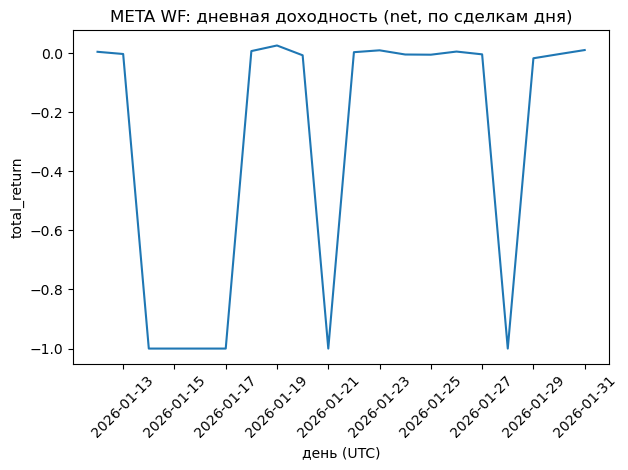

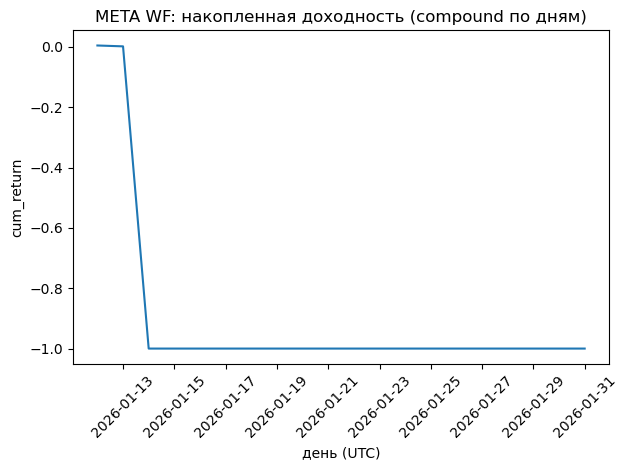


=== CHOSEN PARAMS (last 5 days) ===


,trade_day,total_return,sharpe,n_trades,p_tfSlow,p_lenFast,p_lenSlow,p_atrLen,p_minDistATR,p_trailATR_CT,p_minStopPts,p_minPotMult,p_MOM_MODE,p_MOM_Q,p_MOM_ROLL
15,2026-01-27 00:00:00+00:00,-0.004054,-10.298859,2,180m,36,90,50,11.5,5.5,200,3.5,sign,0.7,300
16,2026-01-28 00:00:00+00:00,-1.000000,0.000000,0,180m,36,90,50,11.5,5.5,300,3.5,strong,0.8,300
17,2026-01-29 00:00:00+00:00,-0.017310,-15.888240,4,180m,36,90,60,11.5,5.5,600,3.5,strong,0.7,400
18,2026-01-30 00:00:00+00:00,-0.003246,0.000000,1,180m,22,90,60,11.5,5.5,600,3.5,strong,0.8,300
19,2026-01-31 00:00:00+00:00,0.010473,0.000000,1,180m,54,90,40,11.5,5.5,600,3.5,strong,0.7,300


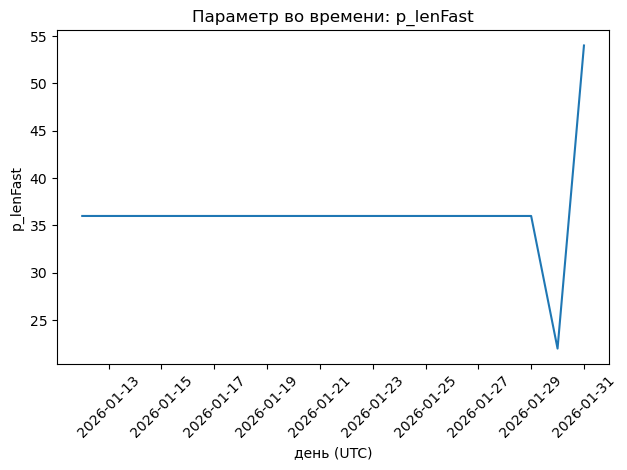

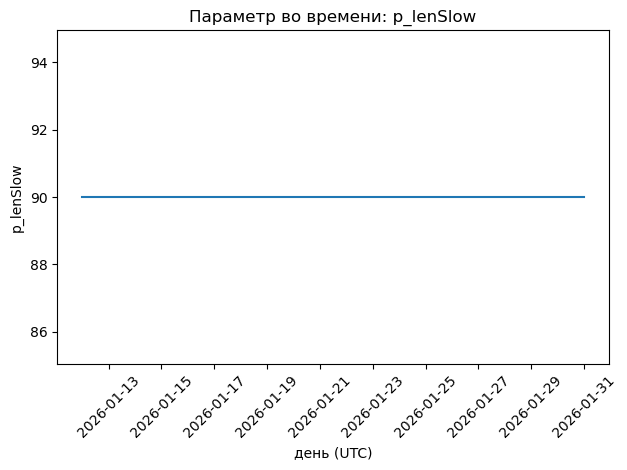

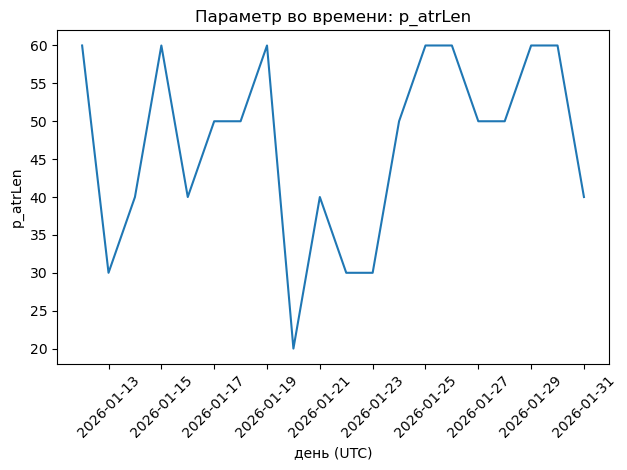

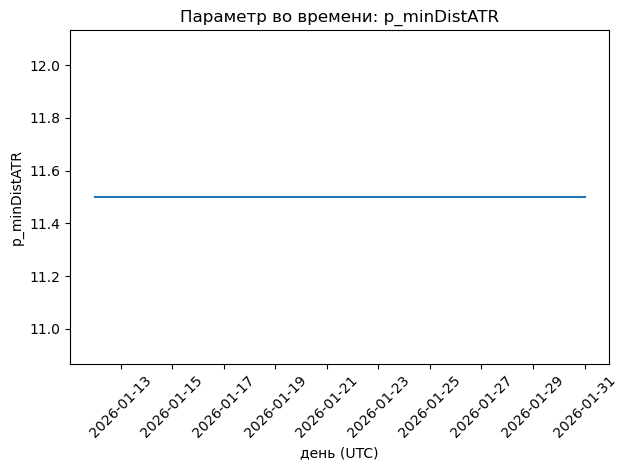

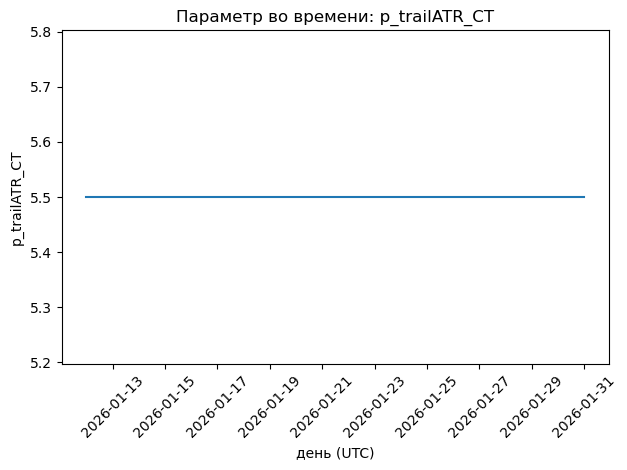

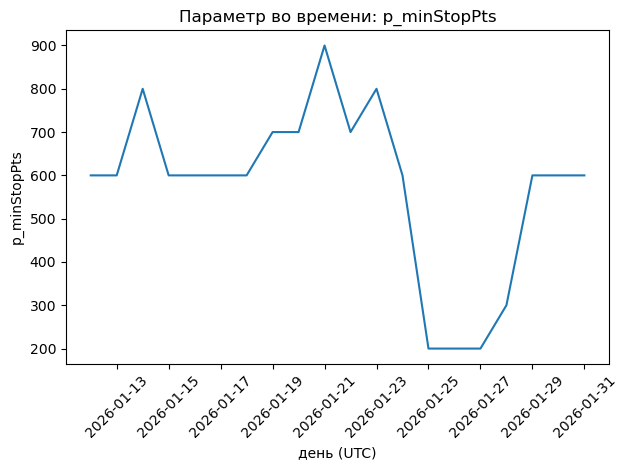

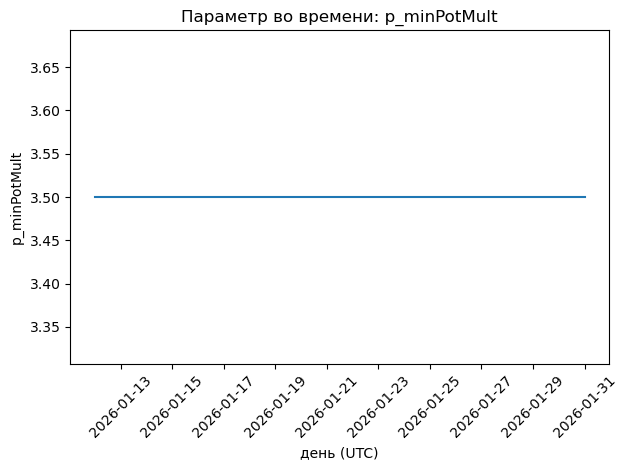

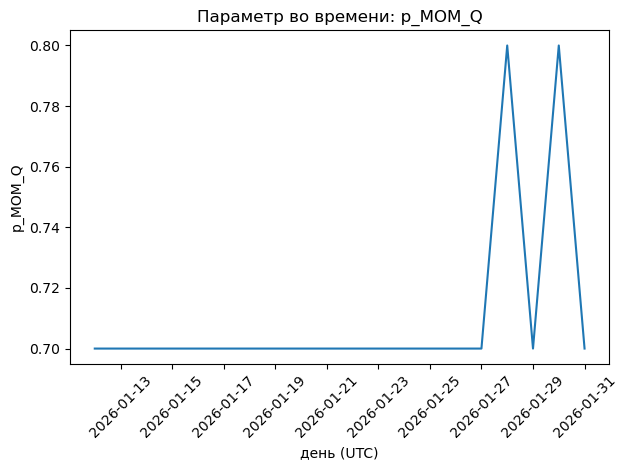

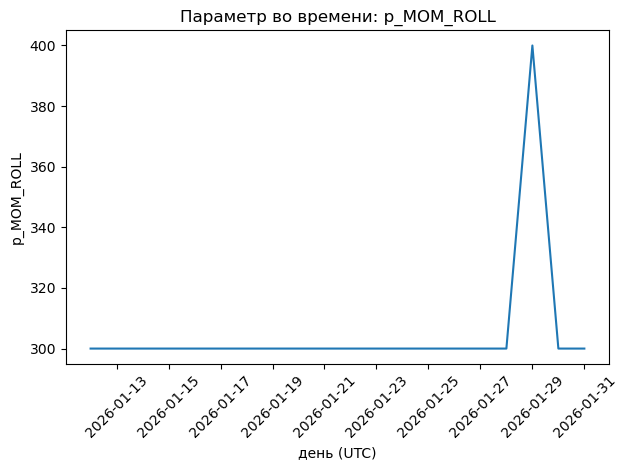


=== PARAM DISTRIBUTIONS (top-5) for 2026-01-31 ===

[lenFast]


,value,prob
0,54,0.169114
1,60,0.147165
2,14,0.101010
3,12,0.096841
4,58,0.070763



[lenSlow]


,value,prob
0,90,0.906503
1,80,0.038464
2,120,0.033252
3,20,0.007565
4,70,0.007108



[atrLen]


...

,value,prob
0,strong,0.510764
1,sign,0.489236



[MOM_Q]


,value,prob
0,0.7,0.549810
1,0.8,0.266801
2,0.9,0.124996
3,0.6,0.058394



[MOM_ROLL]


,value,prob
0,300,0.518616
1,400,0.107947
2,500,0.098670
3,450,0.083286
4,350,0.072762


In [206]:
# ===================== META-WF (CELL 3): STATS + PLOTS =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

res = META_WF["results"].copy()
if len(res) == 0:
    raise ValueError("META_WF['results'] пустой — проверь предыдущую ячейку.")

ok = res[res["ok"] == True].copy()
print("days:", len(res), "| ok:", len(ok))

# --- таблица итогов ---
if len(ok):
    # аккуратная "equity" по дням (compound)
    ok["day_equity"] = (1.0 + ok["total_return"].fillna(0.0)).cumprod()
    ok["cum_return"] = ok["day_equity"] - 1.0

    print("\n=== SUMMARY ===")
    print("total cum return:", float(ok["cum_return"].iloc[-1]))
    print("avg day return:", float(ok["total_return"].mean()))
    print("median day return:", float(ok["total_return"].median()))
    print("avg sharpe (trade-based):", float(ok["sharpe"].mean()))
    print("avg n_trades:", float(ok["n_trades"].mean()))
    print("win_rate avg:", float(ok["win_rate"].mean()))

# --- plot 1: daily returns ---
plt.figure()
plt.plot(ok["trade_day"].dt.date, ok["total_return"].values)
plt.xticks(rotation=45)
plt.title("META WF: дневная доходность (net, по сделкам дня)")
plt.xlabel("день (UTC)")
plt.ylabel("total_return")
plt.tight_layout()
plt.show()

# --- plot 2: cumulative equity ---
plt.figure()
plt.plot(ok["trade_day"].dt.date, ok["cum_return"].values)
plt.xticks(rotation=45)
plt.title("META WF: накопленная доходность (compound по дням)")
plt.xlabel("день (UTC)")
plt.ylabel("cum_return")
plt.tight_layout()
plt.show()

# --- параметры во времени (несколько ключевых) ---
param_cols = [c for c in ok.columns if c.startswith("p_")]
show_params = ["p_tfSlow","p_lenFast","p_lenSlow","p_atrLen","p_minDistATR","p_trailATR_CT","p_minStopPts","p_minPotMult","p_MOM_MODE","p_MOM_Q","p_MOM_ROLL"]
show_params = [c for c in show_params if c in ok.columns]

print("\n=== CHOSEN PARAMS (last 5 days) ===")
display(ok[["trade_day","total_return","sharpe","n_trades"] + show_params].tail(5))

# numeric param plots (skip categorical)
for c in show_params:
    if ok[c].dtype == object:
        continue
    plt.figure()
    plt.plot(ok["trade_day"].dt.date, ok[c].astype(float).values)
    plt.xticks(rotation=45)
    plt.title(f"Параметр во времени: {c}")
    plt.xlabel("день (UTC)")
    plt.ylabel(c)
    plt.tight_layout()
    plt.show()

# --- пример: распределения по одному дню (если хочешь посмотреть, что модель думает) ---
# выбери дату из ok["trade_day"]
if len(ok):
    day_str = str(ok["trade_day"].iloc[-1].date())
    dists = META_WF["param_dists"].get(day_str, None)
    if dists is not None:
        print(f"\n=== PARAM DISTRIBUTIONS (top-5) for {day_str} ===")
        for k in ["lenFast","lenSlow","atrLen","minDistATR","trailATR_CT","MOM_MODE","MOM_Q","MOM_ROLL"]:
            if k in dists:
                print(f"\n[{k}]")
                display(dists[k].head(5))